In [121]:
from helpers import *

import os
import re
import numpy as np
import matplotlib. pyplot as plt
from scipy.spatial.distance import directed_hausdorff

In [122]:
nubmer_points_list= [100, 200,300,400,500,600,700,800,900,1000,1100,1200, 1300,1400,1500]
n_runs= [10]

In [123]:
def calculate_distance(point1, point2):
    # Calculate the Euclidean distance between two points of any dimension
    return sum((x - y) ** 2 for x, y in zip(point1, point2)) ** 0.5
#     return sum(abs(x - y) for x, y in zip(point1, point2))

def calculate_tolerance(points):
    num_points = len(points)
    
    x_min, x_max= np.min(points[:,0]), np.max(points[:,0])
    y_min, y_max= np.min(points[:,1]), np.max(points[:,1])
    segment_length = np.sqrt((x_max - x_min)**2 + (y_max - y_min)**2)
    # Calculate the range of coordinates
#     max_range = np.ptp(points, axis=0).max()
    # Define tolerance as a small fraction of the range
    tolerance = 1 / (num_points-1)#segment_length / (num_points-1) #max_range / (num_points-1)
#     tolerance = segment_length/(num_points-1)#max_range / (num_points-1)
    return tolerance
    
def count_repeated_points(points):
    points = points[np.lexsort((points[:, 1], points[:, 0]))]
#     print(points)
    n= len(points)
    ep=  calculate_tolerance(points) # 1/(n-1) #1e-5
    # Initialize a list to store distinct points
    distinct_points = []

    # Iterate through each point in the set
    for point in points:
        # Check if the point is distinct from all previously considered distinct points
        is_distinct = True
        for distinct_point in distinct_points:
            if calculate_distance(point, distinct_point) < ep:
                is_distinct = False
                break
        # If the point is distinct, add it to the list of distinct points
        if is_distinct:
            distinct_points.append(point)
            
    return len(distinct_points), distinct_points


# def count_repeated_points(points):
#     n = len(points)
#     ep = 1 / (n - 1)  # Threshold for determining if points are distinct
#     clusters = []

#     for i in range(n):
#         found_cluster = False
#         for cluster in clusters:
#             for point in cluster:
#                 if calculate_distance(points[i], point) < ep:
#                     cluster.append(points[i].tolist())
#                     found_cluster = True
#                     break
#             if found_cluster:
#                 break
#         if not found_cluster:
#             clusters.append([points[i].tolist()])

    
#     res= [i[0] for i in clusters]
#     return len(clusters),np.array(res)

In [124]:
def KS_Test(data, algo):
    
    # Perform K-S test
    ks_statistic, p_value = stats.kstest(data, "uniform")#stats.kstest(ecdf.y, stats.uniform.cdf) #stats.kstest(ecdf.y, cdf_uniform)
    
    print("********START********")
    # Display the results
    print("******KS-Test for {}".format(algo),"*********")
    print(f"K-S Statistic: {ks_statistic}")
    print(f"P-Value: {p_value}")

    # Decision based on the p-value
    alpha = 0.05
    if p_value > alpha:
        print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
    else:
        print("Reject the null hypothesis: The sample does not follow the uniform distribution.")
    
    print("********END********")

# GSM

In [125]:
main_path = "../GSM/solns_runs_no_sols/Ex3/"
subfolders = list_subfolders(main_path)

    
txt_files = list_subfolders(subfolders[0])
# list_txt_files(subfolders[0])

titles = [str(100*i) for i in range(1, 16)]

colors = [
    'blue', 'orange', 'r', 'yellow', 'purple',
    'brown', 'pink', 'gray', 'olive', 'cyan', 'red',
    'lightcoral', 'darkgoldenrod', 'mediumseagreen', 'green', 'mangeta'
]


## Number of starting points vs. PDP and HD

In [126]:
folders= ["../GSM/solns_runs_no_sols/Ex3/N_{}/".format(str(pt)) for pt in nubmer_points_list]
folders

['../GSM/solns_runs_no_sols/Ex3/N_100/',
 '../GSM/solns_runs_no_sols/Ex3/N_200/',
 '../GSM/solns_runs_no_sols/Ex3/N_300/',
 '../GSM/solns_runs_no_sols/Ex3/N_400/',
 '../GSM/solns_runs_no_sols/Ex3/N_500/',
 '../GSM/solns_runs_no_sols/Ex3/N_600/',
 '../GSM/solns_runs_no_sols/Ex3/N_700/',
 '../GSM/solns_runs_no_sols/Ex3/N_800/',
 '../GSM/solns_runs_no_sols/Ex3/N_900/',
 '../GSM/solns_runs_no_sols/Ex3/N_1000/',
 '../GSM/solns_runs_no_sols/Ex3/N_1100/',
 '../GSM/solns_runs_no_sols/Ex3/N_1200/',
 '../GSM/solns_runs_no_sols/Ex3/N_1300/',
 '../GSM/solns_runs_no_sols/Ex3/N_1400/',
 '../GSM/solns_runs_no_sols/Ex3/N_1500/']

In [127]:
# folders['n_runs_5']

In [128]:
import os

def list_txt_files_in_directory(directory_path):
#     try:
#         # List all files and directories in the specified path
    files_and_directories = os.listdir(directory_path)
#     print(directory_path)
    # Filter and print only .txt files
    txt_files = [file for file in files_and_directories if file.endswith('.txt')]
    txt_files = [file for file in txt_files if '.txt' in file]
    txt_files.sort()
    txt_files= [directory_path+"/"+file for file in txt_files]
        
    return txt_files

In [129]:
n_times= 10
def get_values(folders):
    dist_= []
    avg_hd= []
    all_data= []
    for pt in range(len(nubmer_points_list)):
        directory_path = folders[pt]
        #print(directory_path)

        files= list_txt_files_in_directory(directory_path)
        
        if len(files)>n_times:
            files= files[:n_times]
        res= []
        hd= []
        
        num_points= nubmer_points_list[pt]
        
        res_solns= []

        for file in files:
            
            if "._" in file:
                    file= file.replace("._","")
            
            solns= np.genfromtxt(file, delimiter=',') #[:,:-1]
            
            res_solns.extend(solns.tolist())
        
        
        res_solns= np.array(res_solns)
        num, distinct_points = count_repeated_points(res_solns)
        distinct_points= np.array(distinct_points)
        
        # Get PDP
        
        dist_.append((len(distinct_points)/(len(res_solns)))*100)
        
        # Stack data
        all_data.append(distinct_points)
        
        print(len(distinct_points), len(res_solns))

    # Create subplots with different scales
    plt.plot(nubmer_points_list, dist_,color='blue')
    plt.ylabel('Perentage of distint points')
    plt.xlabel("Number of starting points")
    plt.xticks(nubmer_points_list)
    plt.grid(True)
    plt.show()

        
    return dist_,all_data

In [130]:
#pdpgsm,all_data_gsm= get_values(folders)

In [131]:
# pdpgsm

In [132]:
# max(pdpgsm), min(hdgsm)

In [133]:
# tolerancesgsm

In [134]:
# plt.plot(tolerancesgsm, c= 'black')
# plt.grid(True)
# plt.show()

In [135]:
# for i in range(len(all_data_gsm)):
#     print("Plot for {} points".format(nubmer_points_list[i]))
#     fig = plt.figure(figsize=(15,6))
#     ax = fig.add_subplot(111, projection='3d')
#     ax.scatter(all_data_gsm[i][:,0], all_data_gsm[i][:,1], all_data_gsm[i][:,2], c= 'black', label= "Solution set")
#     ax.set_xlabel(r'$x_1$')
#     ax.set_ylabel(r'$x_2$')
#     ax.set_zlabel(r'$x_3$')
#     plt.show()

## Histograms

In [136]:
# n_runs= 50 and 
n_points= 1500 #nubmer_points_list[np.argmax(pdpgsm)]
# Best
directory_path = "../GSM/solns_runs_no_sols/Ex3/N_{}".format(n_points)
all_solnsgsm= []

files= list_txt_files_in_directory(directory_path)
for file in files:
    solns= np.genfromtxt(file, delimiter=',')
    
#     num, distinct_points,_ = count_repeated_points(solns)
#     distinct_points= np.array(distinct_points)
    all_solnsgsm.extend(solns.tolist())
    break

all_solnsgsm= np.array(all_solnsgsm)
num, all_solnsgsm= count_repeated_points(all_solnsgsm)
all_solnsgsm= np.array(all_solnsgsm)

In [137]:
len(all_solnsgsm)

461

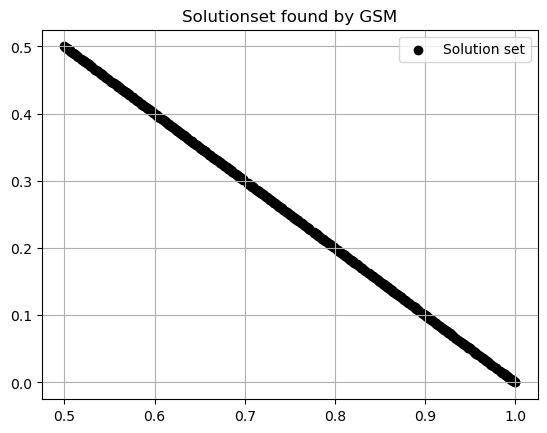

In [138]:
plt.scatter(all_solnsgsm[:,0], all_solnsgsm[:,1], c= 'black',label= "Solution set")
# plt.xlim([0,1])
# plt.ylim([0,1])
plt.grid(True)
plt.legend()
plt.title("Solutionset found by GSM")
plt.savefig('./Ex_with_no_sols/Figures/Ex3/GSM_ex3.png', dpi=180, bbox_inches='tight')
plt.show()

In [300]:
def partition_interval(a, b, n):
#     n= n-1
    interval_length = b - a
    partition_width = interval_length / n
    partition_points = [a + i * partition_width for i in range(n + 1)]
    return partition_points

def count_values_in_bins(values, bins):
    # Initialize a dictionary to store the counts for each bin
    bin_counts = {bin_index: 0 for bin_index in range(len(bins) - 1)}

    # Iterate over each value
    for value in values:
        # Find the bin that the value falls into
        bin_index = 0
        while bin_index < len(bins) - 1 and not (bins[bin_index] <= value < bins[bin_index + 1]):
            bin_index += 1

        # Increment the count for the corresponding bin.
        if bin_index < len(bins) - 1:
            bin_counts[bin_index] += 1

    return bin_counts

In [139]:


## x:
bins_list= [5, 10, 15, 20]
solns= all_solnsgsm.copy()
x= solns[:,0]
x_min = np.min(x)
x_max = np.max(x)

## y:
y= solns[:,1]
y_min = np.min(y)
y_max = np.max(y)
# y

xgsm= x.copy()
ygsm= y.copy()

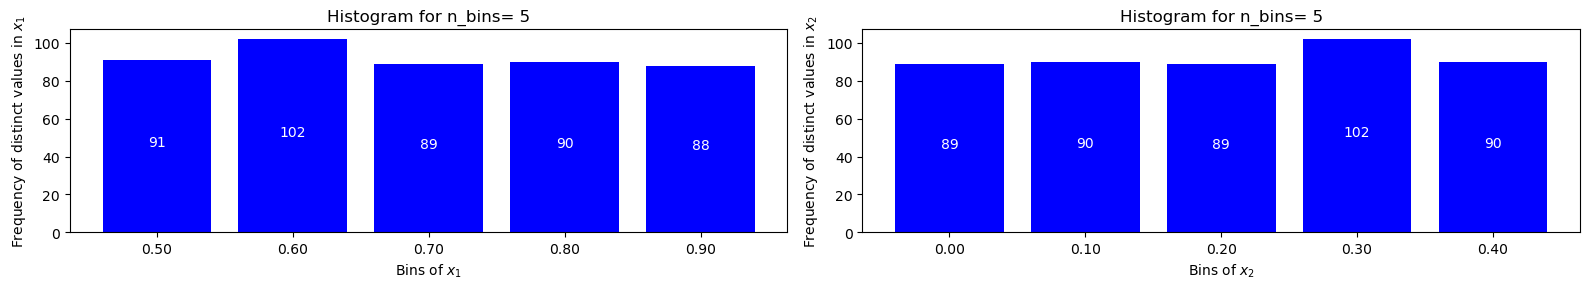

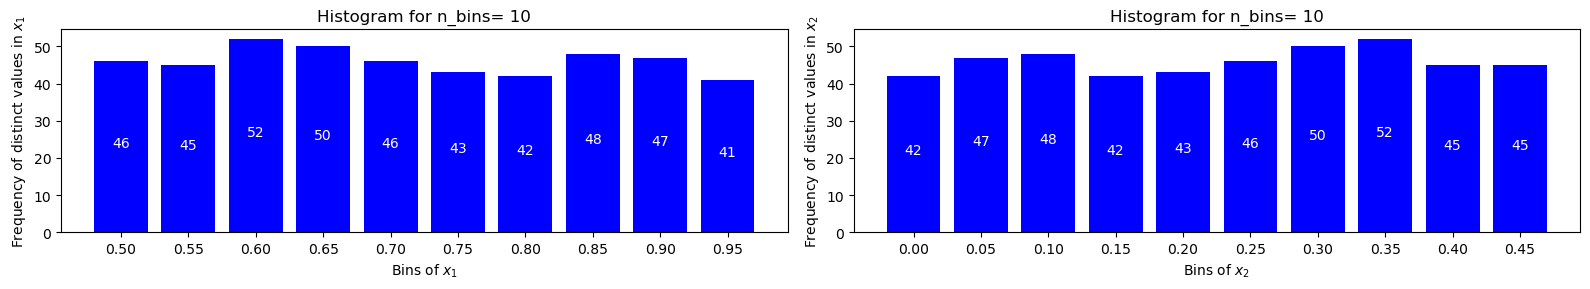

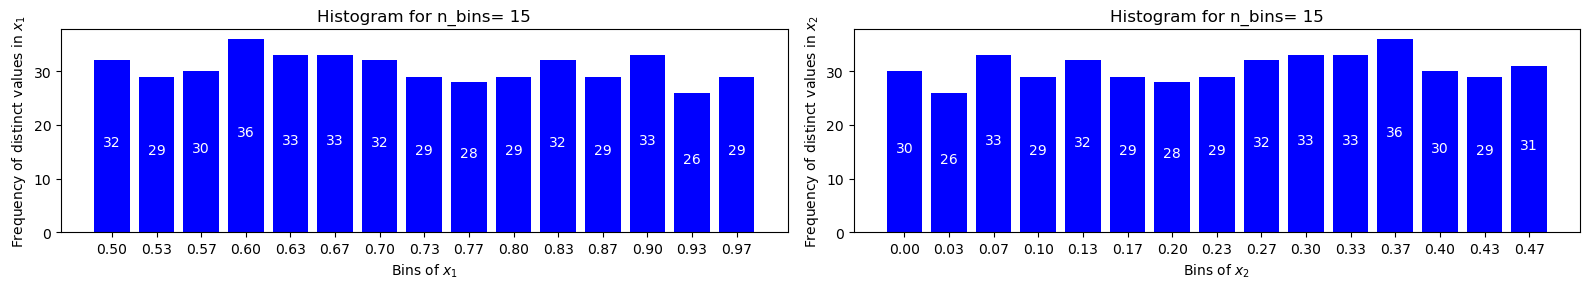

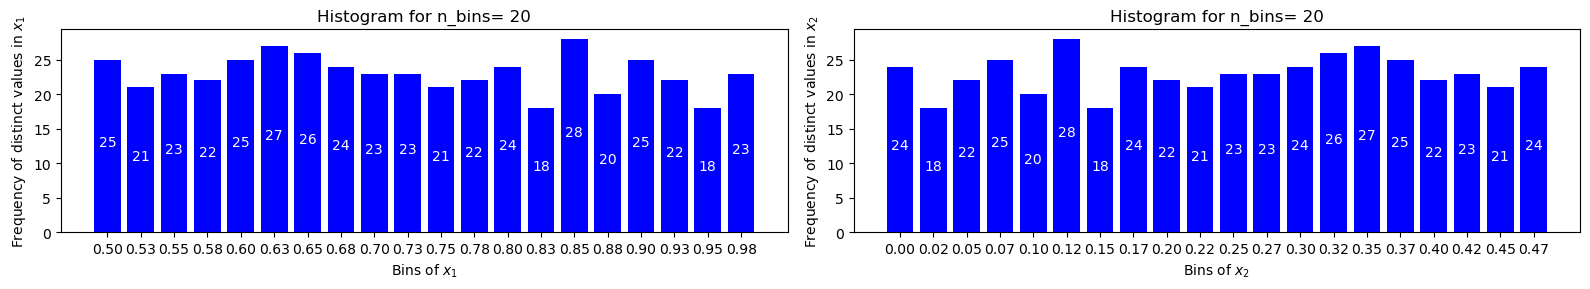

In [140]:
x_hist_gsm= []
y_hist_gsm= []
y_part_gsm= []
x_part_gsm= []
for n_bins in bins_list:
    partition_points = partition_interval(x_min, x_max, n_bins)
    x_part_gsm.append(partition_points)
#     print("Partition points:", partition_points)
    bin_counts = count_values_in_bins(x, partition_points)
    x_hist_gsm.append(bin_counts)
#     bin_counts= get_per(bin_counts)
#     print("Counts in each bin:", bin_counts)

    y_partition_points = partition_interval(y_min, y_max, n_bins)
    y_part_gsm.append(y_partition_points)
    y_bin_counts = count_values_in_bins(y, y_partition_points)
    y_hist_gsm.append(y_bin_counts)
    
#     y_bin_counts= get_per(y_bin_counts)
#     print("Counts in each bin:", y_bin_counts)


    plt.figure(figsize=(16, 3))

    plt.subplot(1, 2, 1)
    bars = plt.bar(range(len(bin_counts)), bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(bin_counts)), ["{:.2f}".format(b) for b in partition_points[:-1]])
    plt.xlabel('Bins of $x_1$')
    plt.ylabel('Frequency of distinct values in $x_1$')
    plt.title('Histogram for n_bins= {}'.format(len(bin_counts)))
#     plt.grid(True)

    plt.subplot(1, 2, 2)
    bars = plt.bar(range(len(y_bin_counts)), y_bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(y_bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(y_bin_counts)), ["{:.2f}".format(b) for b in y_partition_points[:-1]])
    plt.xlabel('Bins of $x_2$')
    plt.ylabel('Frequency of distinct values in $x_2$')
    plt.title('Histogram for n_bins= {}'.format(len(y_bin_counts)))
#     plt.grid(True)
    plt.tight_layout()
    #plt.savefig('../GSM/solns_runs/Ex1/'+'ex1_gsm_hist'+str(n_bins)+'.png')
    plt.show()

## Uniform CDF vs. empirical CDF

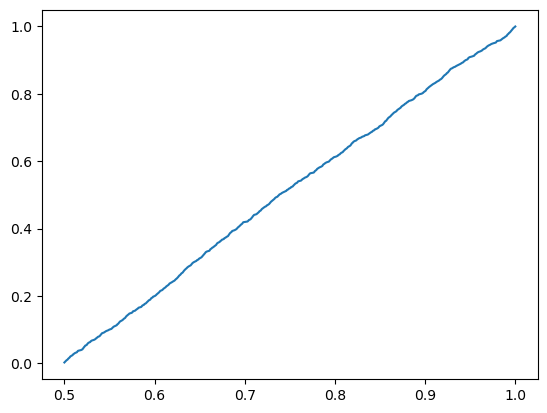

In [141]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from matplotlib import pyplot
from numpy.random import normal
from numpy import hstack
from statsmodels.distributions.empirical_distribution import ECDF
# fit a cdf
ecdf = ECDF(xgsm)
plt.plot(ecdf.x, ecdf.y)
plt.show()


def get_cdf_of_uniform(x, a, b):
    if x<a:
        return 0
    elif a<=x<b:
        return (x-a)/(b-a)
    elif x>b:
        return 1

## KS-Test

In [142]:
import numpy as np
from scipy import stats

# Example data (replace with your actual data)
np.random.seed(0)
data = np.random.uniform(0,1, size=100)

# Perform KS test against a normal distribution (null hypothesis)
ks_statistic, p_value = stats.kstest(data, 'norm')

# Print the results
print(f"KS Statistic: {ks_statistic}")
print(f"P-value: {p_value}")

# Interpret the results
alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis that the data is normally distributed.")
else:
    print("Cannot reject the null hypothesis that the data is normally distributed.")


KS Statistic: 0.5018732170965315
P-value: 7.902176095057781e-24
Reject the null hypothesis that the data is normally distributed.


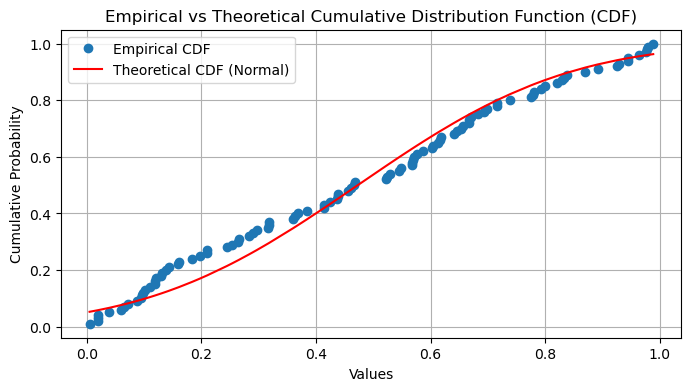

In [143]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Example data (replace with your actual data)
np.random.seed(0)
# data = np.random.normal(loc=0, scale=1, size=100)

# Sort the data
sorted_data = np.sort(data)

# Calculate the empirical CDF
n = sorted_data.size
y_empirical = np.arange(1, n+1) / n

# Calculate the theoretical CDF (normal distribution)
mean, std = np.mean(data), np.std(data)
y_theoretical = stats.norm.cdf(sorted_data, loc=mean, scale=std)

# Plotting the empirical and theoretical CDFs
plt.figure(figsize=(8, 4))
plt.plot(sorted_data, y_empirical, label='Empirical CDF', marker='o', linestyle='none')
plt.plot(sorted_data, y_theoretical, label='Theoretical CDF (Normal)', color='red')
plt.xlabel('Values')
plt.ylabel('Cumulative Probability')
plt.title('Empirical vs Theoretical Cumulative Distribution Function (CDF)')
plt.legend()
plt.grid(True)
plt.show()


In [245]:
# xgsm

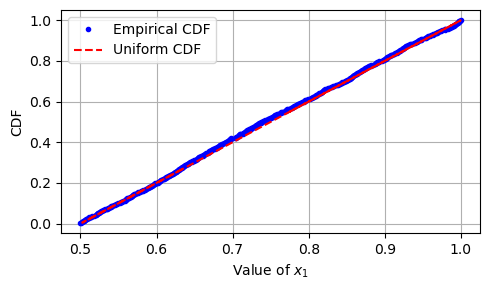

K-S Statistic: 0.5000589662365743
P-Value: 4.0090995373311046e-107
Reject the null hypothesis: The sample does not follow the uniform distribution.


In [144]:
# KS Test on x: 
a,b= np.min(xgsm),np.max(xgsm)
uniform_samples = np.random.uniform(low=a, high=b, size=len(x))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

# Number of samples
n_samples = len(x)

# Generate uniform values in [0,1]
#uniform_samples = np.random.uniform(low=0.0, high=1.0, size=n_samples)

# Plotting the histogram of uniform samples
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(xgsm)
ecdf_gsm_x = ECDF(xgsm) #np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_gsm_x.x, ecdf_gsm_x.y, marker='.', linestyle='none', label='Empirical CDF',c= 'blue')
# plt.plot([0.5, 1], [0.0, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples,cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples vs. Empiric')
plt.xlabel('Value of $x_1$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
#plt.savefig('../GSM/solns_runs/Ex1/ks_ex1_x1.png')
plt.show()

# Perform K-S test
ks_statistic, p_value = stats.kstest(xgsm, "uniform")#stats.kstest(ecdf.y, stats.uniform.cdf) #stats.kstest(ecdf.y, cdf_uniform)

# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.")

In [145]:
ecdf_gsm_x.y

array([0.        , 0.0021692 , 0.00433839, 0.00650759, 0.00867679,
       0.01084599, 0.01301518, 0.01518438, 0.01735358, 0.01952278,
       0.02169197, 0.02386117, 0.02603037, 0.02819957, 0.03036876,
       0.03253796, 0.03470716, 0.03687636, 0.03904555, 0.04121475,
       0.04338395, 0.04555315, 0.04772234, 0.04989154, 0.05206074,
       0.05422993, 0.05639913, 0.05856833, 0.06073753, 0.06290672,
       0.06507592, 0.06724512, 0.06941432, 0.07158351, 0.07375271,
       0.07592191, 0.07809111, 0.0802603 , 0.0824295 , 0.0845987 ,
       0.0867679 , 0.08893709, 0.09110629, 0.09327549, 0.09544469,
       0.09761388, 0.09978308, 0.10195228, 0.10412148, 0.10629067,
       0.10845987, 0.11062907, 0.11279826, 0.11496746, 0.11713666,
       0.11930586, 0.12147505, 0.12364425, 0.12581345, 0.12798265,
       0.13015184, 0.13232104, 0.13449024, 0.13665944, 0.13882863,
       0.14099783, 0.14316703, 0.14533623, 0.14750542, 0.14967462,
       0.15184382, 0.15401302, 0.15618221, 0.15835141, 0.16052

In [146]:
ecdf_gsm_x.x

array([      -inf, 0.50005897, 0.50083123, 0.50173828, 0.50240099,
       0.50362547, 0.50416115, 0.50498902, 0.50598269, 0.5064552 ,
       0.50764635, 0.50911978, 0.50966556, 0.5107517 , 0.51191742,
       0.5139474 , 0.51450688, 0.51525349, 0.51850059, 0.52012619,
       0.52060007, 0.52129218, 0.521812  , 0.52258979, 0.52308947,
       0.52480859, 0.52531863, 0.52597599, 0.52683922, 0.5286839 ,
       0.52924855, 0.53045684, 0.53296366, 0.53439231, 0.53518503,
       0.53630222, 0.53713629, 0.53903134, 0.53973183, 0.54038114,
       0.54128168, 0.54175696, 0.54388994, 0.54519153, 0.54636037,
       0.54846041, 0.54985856, 0.55218841, 0.5529532 , 0.55380616,
       0.55469421, 0.55643806, 0.55809014, 0.5585711 , 0.55968582,
       0.56038246, 0.56101372, 0.56163685, 0.5630674 , 0.56445817,
       0.56535242, 0.56615037, 0.5674079 , 0.56795272, 0.56850292,
       0.56936444, 0.57027719, 0.57131898, 0.57210656, 0.57475748,
       0.57559686, 0.57610325, 0.57852249, 0.57937896, 0.58049

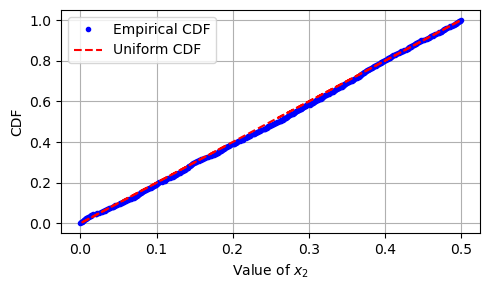

K-S Statistic: 0.5000589662365748
P-Value: 4.009099537329232e-107
Reject the null hypothesis: The sample does not follow the uniform distribution.


In [147]:
# KS Test on y: 
# Number of samples
a,b=np.min(ygsm),np.max(ygsm)
uniform_samples = np.random.uniform(low=a, high=b, size=len(x))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

n_samples = len(x)
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(ygsm)
ecdf_gsm_y = ECDF(ygsm) # np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_gsm_y.x, ecdf_gsm_y.y, marker='.', linestyle='none', label='Empirical CDF', c= 'blue')
# plt.plot([1-1, 1-0.5], [1-1, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples, cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples')
plt.xlabel('Value of $x_2$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
#plt.savefig('../GSM/solns_runs/Ex1/ks_ex1_x2.png')
plt.show()

# Perform K-S test
ks_statistic, p_value = stats.kstest(ygsm, "uniform")

# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.")


In [148]:
# y

# PVI

In [248]:
from math import *
def constraint_function(x):
#     return np.array([x[0] + x[1] - 1])
    return np.array([-1+x[0] + x[1]])

def gradient_x1(x):
    return -1.0

def gradient_x2(x):
    return -1.0

def gradient(x):
    return np.array([gradient_x1(x),gradient_x2(x)])


n= 2
alpha= np.random.uniform(0, sqrt(2)-1)

def F(x,lamd= 0.0):
  return np.array([x[0]-x[1]+lamd*gradient_x1(x),2*x[1]+x[0]+lamd*gradient_x2(x)])

## kkt check
eps= 1e-4
def stationarity(x,lambda_):
    
    infinity_norm = np.linalg.norm(F(x, lambda_), ord=np.inf)
    return infinity_norm<=eps
#     return infinity_norm==0.0

def complementarity_slackness(x,lambda_):
    absolute = abs(lambda_*constraint_function(x))
#     return absolute==0.0
    return absolute<=eps

def dual_feasib(lambda_):
    return lambda_>=0

def primal_feasib(x):
    return max(constraint_function(x),0)<=eps
#     return max(constraint_function(x),0)==0.0

def condition_2(x,lambda_):
    return np.linalg.norm(constraint_function(x)*lambda_)<=eps
#     return np.linalg.norm(constraint_function(x)*lambda_)==0
def check_kkt(x, lambda_, g):
    c1= stationarity(x,lambda_)
    c2= complementarity_slackness(x,lambda_)
    
    if c1== True and c2== True:
        return True
    
# discretize_space(2, N)
## check points
eps= 1e-4
def norm_g(xx, lam):
    lamb= np.array(lam)
    xx= np.array(xx)
#     if constraint_function(xx)= 1e-4 or lamb!=0:
#         return True
#     else:
#         return False

#     return np.linalg.norm(constraint_function(xx)*lamb)==0.0
    return np.linalg.norm(constraint_function(xx)*lamb)<=eps
#     return np.linalg.norm(constraint_function(xx))>=1e-4

def discard(x_set, lamb):
    good_points= []
    for i in x_set:
        if norm_g(i, lamb)==True:
            good_points.append(list(i))
    return good_points 


def check_with_lambda(x_set, lamb):
  S= []
  for (l,xx) in zip(lamb,x_set):
    if norm_g(xx, l)==True:
      S.append(list(xx))
  return S

def discretize_time_interval(T,num_points):
    """
    Discretize the time interval [0, T] with a given time step (delta_t).

    Parameters:
    - T: Total time duration
    - delta_t: Time step size

    Returns:
    - time_points: List of discretized time points
    """
    start = T-1

    # Calculate the width of each sub-interval
    interval_width = (T - start) / (num_points - 1)

    # Generate the points
    points = [start + i * interval_width for i in range(num_points)]

    return points

def get_solns_for_T(T):
    titles = [str(100*i) for i in range(1, 16)]
    main_path = "../PVI/solns_runs_no_sols/Ex3/T"+str(T)
    index= titles.index(str(n_points))
    subfolders = list_subfolders(main_path)[index]


    colors = [
        'blue', 'orange', 'r', 'yellow', 'purple',
        'brown', 'pink', 'gray', 'olive', 'cyan', 'red',
        'lightcoral', 'darkgoldenrod', 'mediumseagreen', 'green', 'mangeta'
    ]

    s_ns= []
    n_distn_tot= []
#     
    files = list_txt_files(subfolders)
    n_pts= n_points
    lam = discretize_time_interval(T, n_pts)
    res=[]
    for file in files:
        solns= np.genfromtxt(subfolders+"/"+file, delimiter=',')

        num, distinct_points = count_repeated_points(np.array(solns))
        res.extend(distinct_points)
    
    x= []
    for r in res:
        x.append(r.tolist()) 
        
    return x

In [249]:
T= 2
# Define a custom sorting function based on the specified order
order = {'run5': 0, 'run10': 1, 'run15': 2, 'run20': 3}
def custom_sort(path):
    run_number = int(path.split('run')[-1])
    return order.get('run' + str(run_number), float('inf'))

# Sort the paths using the custom sorting function


# Define a custom sorting function based on the numerical suffixes
def custom_sort_w(path):
    return int(path.split('N')[-1])


# print(sorted_paths)

def list_subfolders(folder_path):
    subfolders = [f.path for f in os.scandir(folder_path) if f.is_dir()]
    # Sort the paths using the custom sorting function
    sorted_paths = sorted(subfolders, key=custom_sort_w)
    return sorted_paths

def list_subfolders_r(folder_path):
    subfolders = [f.path for f in os.scandir(folder_path) if f.is_dir()]
    # Sort the paths using the custom sorting function
    return subfolders


def list_txt_files(folder_path):
    txt_files = [f for f in os.listdir(folder_path) if f.endswith('.txt')]
    return txt_files

In [254]:
main_path= "../PVI/solns_runs_no_sols/Ex3/T"+str(T)
subfolders= list_subfolders(main_path)
subfolders

['../PVI/solns_runs_no_sols/Ex3/T2\\N1500']

### Best T

In [255]:
# plt.figure(figsize=(10, 4))
def plot_for_T(T):
    main_path = "../PVI/solns_runs_no_sols/Ex3/T"+str(T)
    subfolders = list_subfolders(main_path)

    titles = [str(100*i) for i in range(1, 16)]

    colors = [
        'blue', 'orange', 'r', 'yellow', 'purple',
        'brown', 'pink', 'gray', 'olive', 'cyan', 'red',
        'lightcoral', 'darkgoldenrod', 'mediumseagreen', 'green', 'mangeta'
    ]

    n_pts, n_rs, files= None,None, None
    n_distn_tot= []
    for i, (sb_folder, color, title) in enumerate(zip(subfolders, colors, titles)):
        files = list_txt_files(sb_folder)
        n_pts= nubmer_points_list[i]
        lam = discretize_time_interval(T, n_pts)
        res=[]
        for file in files:
            solns= np.genfromtxt(sb_folder+"/"+file, delimiter=',')
#             solns=  check_with_lambda(solns, lam) # Do not check as g(x)= 0
#             print(solns)

            # Check solutions
            if len(solns) !=0:
                
                ## Get distinct points
                num, distinct_points = count_repeated_points(np.array(solns))
        #         print(len(distinct_points),len(solns))
                res.append((len(distinct_points)/(len(solns)))*100)
        n_distn_tot.append(np.mean(res))
        
    return n_distn_tot

In [256]:
T_list= [i for i in range(1,4)]
T_list

[1, 2, 3]

In [257]:
nubmer_points_list= [1500]
files={}
default_value = 0
files = {key: [] for key in nubmer_points_list}
files

{1500: []}

In [258]:
def get_files(nubmer_points_list,files):
    for n_points in nubmer_points_list: 
        files[n_points]= ['../PVI/solns_runs_no_sols/Ex3/T{}'.format(T)+"/"+'N'+str(n_points) for T in T_list]
    return files

In [259]:
files= get_files(nubmer_points_list,files)

In [260]:
files

{1500: ['../PVI/solns_runs_no_sols/Ex3/T1/N1500',
  '../PVI/solns_runs_no_sols/Ex3/T2/N1500',
  '../PVI/solns_runs_no_sols/Ex3/T3/N1500']}

In [261]:
data= []

for pt in nubmer_points_list:
    dt= []
    file= files[pt]

    for id_fff in range(len(file)):
        lam = discretize_time_interval(T_list[id_fff], pt) # T= 50
        txt_files = [file[id_fff]+"/"+f for f in os.listdir(file[id_fff]) if f.endswith('.txt')]
        #print(fff)#
        res= []
        for ff in txt_files:
            
            if "._" in ff:
                ff= ff.replace("._","")
            
            solns= np.genfromtxt(ff, delimiter=',')
            solns=  check_with_lambda(solns, lam)
#             if len(solns) != 0:
            res.extend(solns)
        dt.extend(res)
    data.append(dt)

In [262]:
# len(data)

In [263]:
data

[[[0.9999877648611766, 1.2235138823646352e-05],
  [1.0, 2.220446049250313e-16],
  [0.9999951749797691, 4.825020230470045e-06],
  [0.9999999999999999, 0.0],
  [1.0, 4.440892098500626e-16],
  [0.999999999999999, 1.9103642279194588e-16],
  [1.0, 4.440892098500626e-16],
  [1.0, 0.0],
  [0.9998004944690355, 0.0001995055309651464],
  [0.9997612845821154, 0.00023871541788364763],
  [0.9999997877434949, 2.1225650565339163e-07],
  [0.9999748694344074, 2.5130565593930792e-05],
  [1.0, 4.440892098500626e-16],
  [0.9999914122196117, 8.587780388639565e-06],
  [0.9999828446109084, 1.7155389092398364e-05],
  [1.0, 0.0],
  [1.0, 2.220446049250313e-16],
  [1.0, 0.0],
  [1.0, 0.0],
  [1.0, 4.440892098500626e-16],
  [1.0, 2.9696297504377966e-16],
  [1.0, 8.881784197001252e-16],
  [0.9999883348141101, 1.1665185891654504e-05],
  [1.0, 2.220446049250313e-16],
  [1.0, 4.440892098500626e-16],
  [0.9999497882477054, 5.021175229512093e-05],
  [0.9997972042293142, 0.0002027957706853224],
  [0.9999965997683314, 3

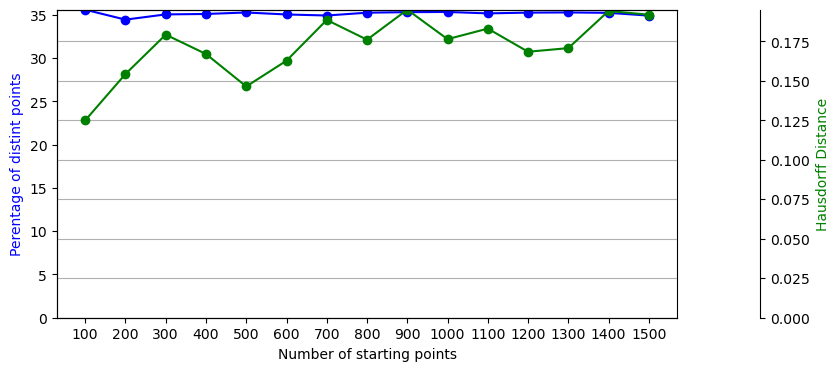

In [114]:
dist_= []
avg_hd= []
tolerancespvi= []


for i in range(len(data)):


    num, distinct_points,tol = count_repeated_points(np.array(data[i]))
    distinct_points= np.array(distinct_points)
            
    dist_.append((len(distinct_points)/(len(data[i])))*100)
    
    t_values = np.random.uniform(0.5, 1, len(np.array(distinct_points)))

    points = np.column_stack((t_values, 1 - t_values))
            
    hausdorff_distance = directed_hausdorff(distinct_points, points)[0]
#     hd.append(hausdorff_distance)
            

    avg_hd.append(hausdorff_distance)
    tolerancespvi.append(tol)
    
    
fig, ax1 = plt.subplots(figsize=(8, 4))

# Create second axis with different scale
ax1.set_xlabel('Number of starting points')
#     ax2 = ax1.twinx()
ax1.set_ylim([0.0, np.max(dist_)])
ax1.plot(nubmer_points_list, dist_, 'bo-')
    
#     ax1.set_yticks(dist_)
    
ax1.set_ylabel('Perentage of distint points',color='blue')
#     ax1.set_ylabel('Perentage of distint points', color='b')


# Create third axis with different scale
ax2 = ax1.twinx()
ax2.spines['right'].set_position(('outward', 60))  # Move the spine to the right
ax2.plot(nubmer_points_list, avg_hd, 'go-')
ax2.set_ylabel('Hausdorff Distance', color='g')
ax2.set_ylim([0.0, np.max(avg_hd)])

xticks = nubmer_points_list  # Precisely specify xticks from 0 to 10 with a step of 1
ax1.set_xticks(xticks)
ax1.set_xticklabels([f'{tick:.0f}' for tick in xticks])  # Format labels as strings with one decimal place


plt.savefig('../PVI/solns_runs_no_sols/Ex3/plot_ex3.png')
plt.grid(True)
plt.show()

In [265]:
type(data)


list

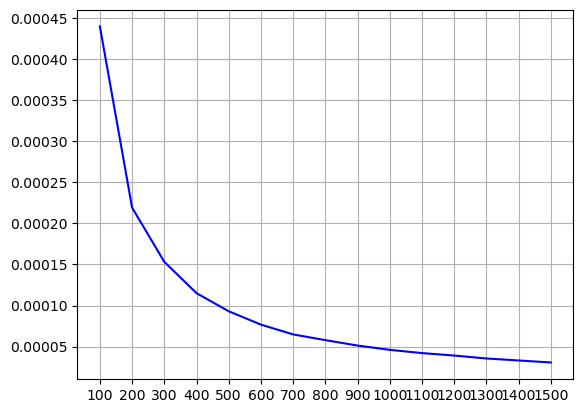

In [43]:
plt.plot(nubmer_points_list,tolerancespvi,c='b')
plt.xticks(nubmer_points_list)
plt.grid(True)
plt.show()

In [44]:
max(dist_), min(avg_hd)

(35.58875219683655, 0.12244054741538418)

In [275]:
data

[[[0.9999877648611766, 1.2235138823646352e-05],
  [1.0, 2.220446049250313e-16],
  [0.9999951749797691, 4.825020230470045e-06],
  [0.9999999999999999, 0.0],
  [1.0, 4.440892098500626e-16],
  [0.999999999999999, 1.9103642279194588e-16],
  [1.0, 4.440892098500626e-16],
  [1.0, 0.0],
  [0.9998004944690355, 0.0001995055309651464],
  [0.9997612845821154, 0.00023871541788364763],
  [0.9999997877434949, 2.1225650565339163e-07],
  [0.9999748694344074, 2.5130565593930792e-05],
  [1.0, 4.440892098500626e-16],
  [0.9999914122196117, 8.587780388639565e-06],
  [0.9999828446109084, 1.7155389092398364e-05],
  [1.0, 0.0],
  [1.0, 2.220446049250313e-16],
  [1.0, 0.0],
  [1.0, 0.0],
  [1.0, 4.440892098500626e-16],
  [1.0, 2.9696297504377966e-16],
  [1.0, 8.881784197001252e-16],
  [0.9999883348141101, 1.1665185891654504e-05],
  [1.0, 2.220446049250313e-16],
  [1.0, 4.440892098500626e-16],
  [0.9999497882477054, 5.021175229512093e-05],
  [0.9997972042293142, 0.0002027957706853224],
  [0.9999965997683314, 3

In [272]:
sol= np.array(data) #np.argmax(pdppvi)
sol= sol.squeeze()
num, distinct_points= count_repeated_points(sol)
sol= np.array(distinct_points)
print(len(sol))

2


In [276]:
sol

array([[9.99480721e-01, 5.19278903e-04],
       [9.99952284e-01, 4.77161091e-05]])

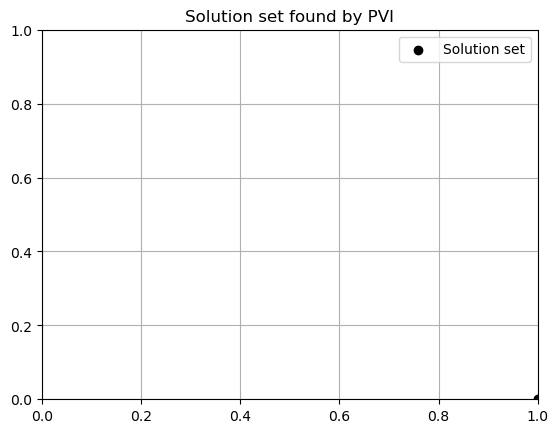

In [309]:
plt.scatter(sol[:,0], sol[:,1], c= 'black', label= "Solution set")
plt.xlim([0,1])
plt.ylim([0,1])
plt.title("Solution set found by PVI")
plt.grid(True)
plt.legend()
plt.savefig('./Ex_with_no_sols/Figures/Ex3/PVI_ex3.png', dpi=180, bbox_inches='tight')
plt.show()

Plot for 100 points


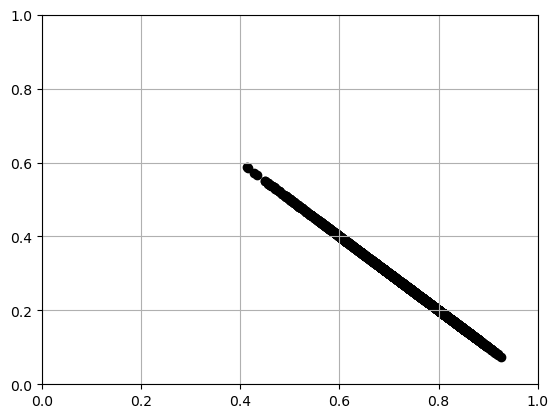

Plot for 200 points


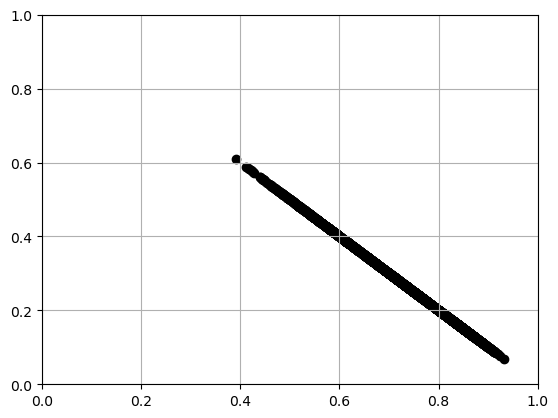

Plot for 300 points


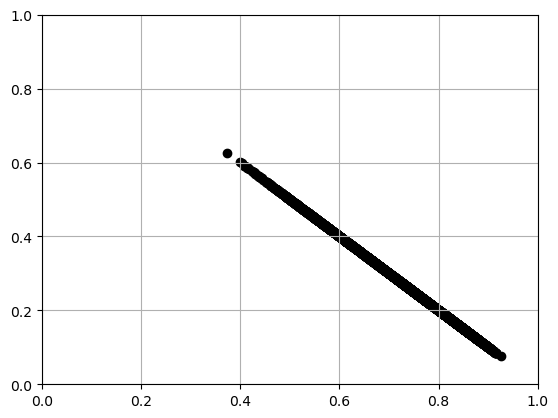

Plot for 400 points


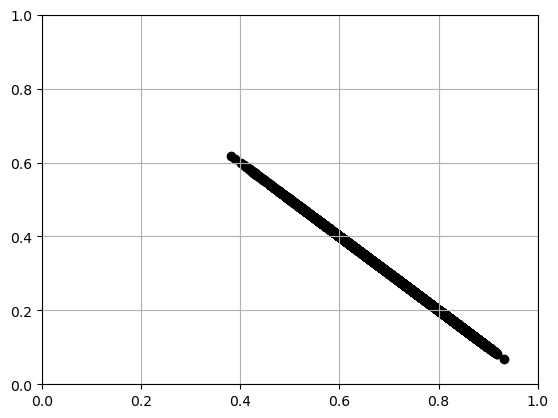

Plot for 500 points


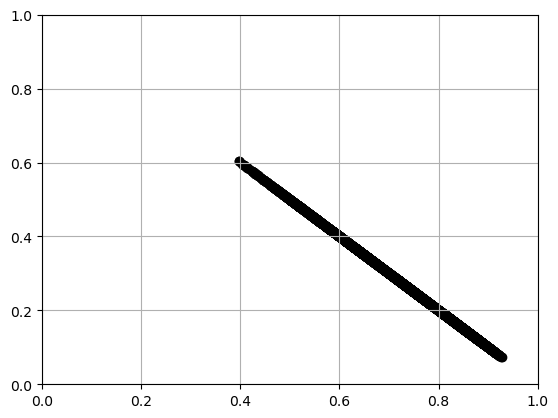

Plot for 600 points


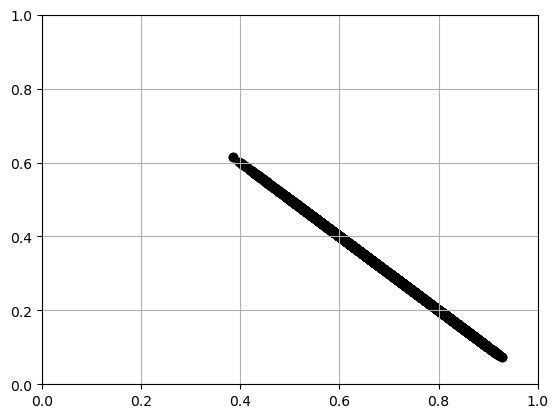

Plot for 700 points


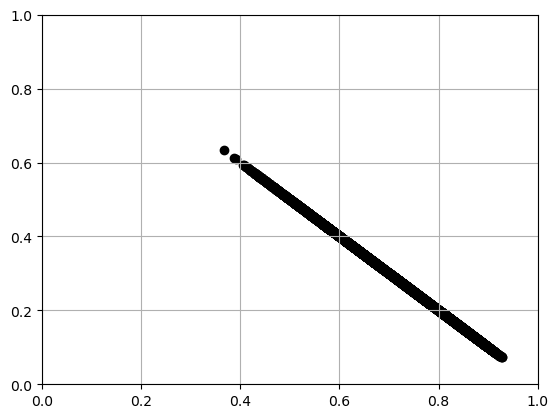

Plot for 800 points


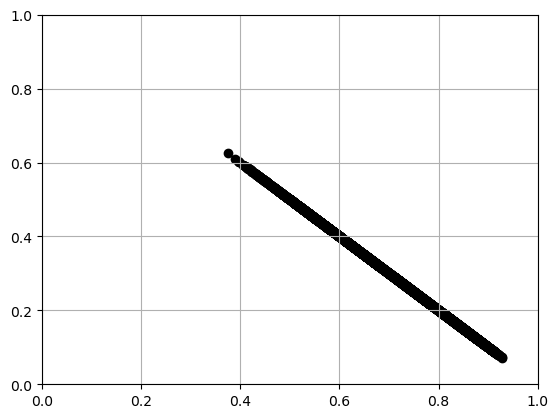

Plot for 900 points


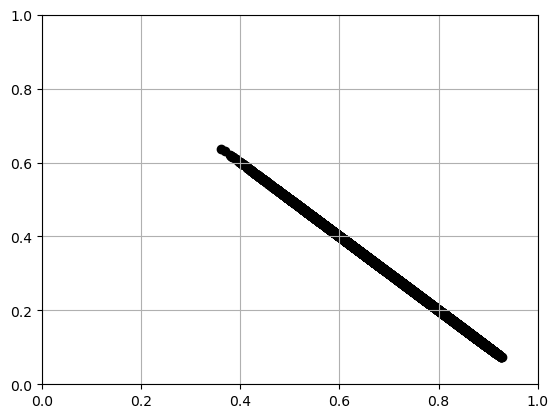

Plot for 1000 points


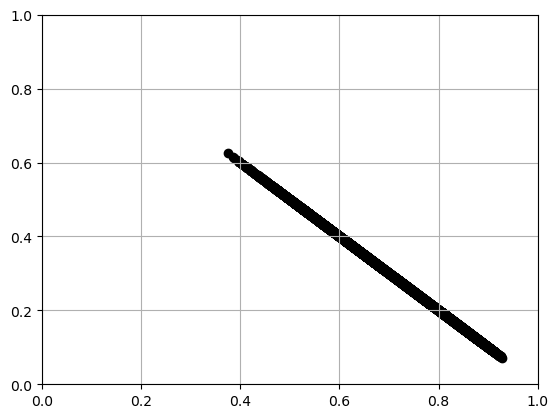

Plot for 1100 points


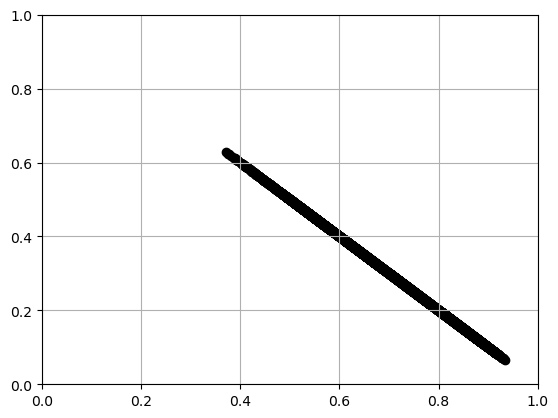

Plot for 1200 points


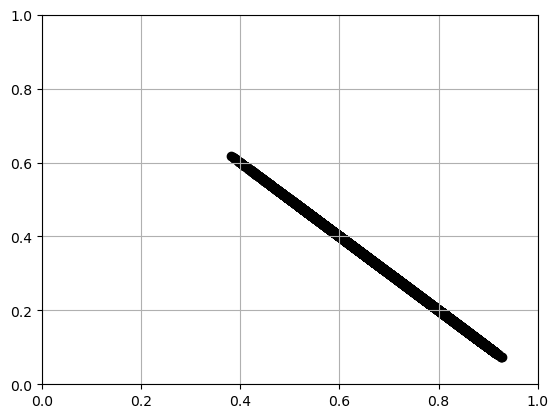

Plot for 1300 points


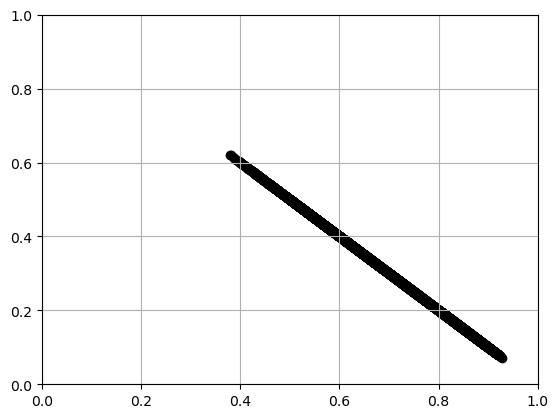

Plot for 1400 points


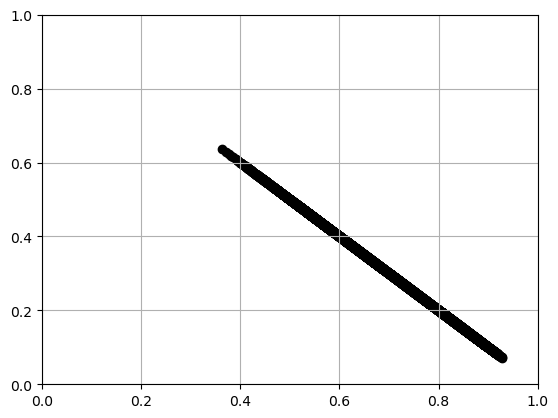

Plot for 1500 points


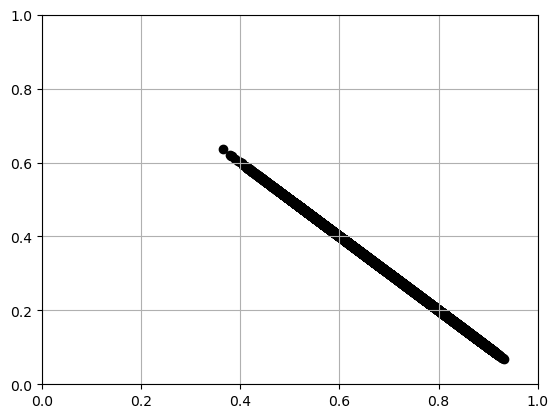

In [48]:
for i in range(len(data)):
    print("Plot for {} points".format(nubmer_points_list[i]))
    plt.scatter(np.array(data[i])[:,0], np.array(data[i])[:,1], c= 'black')
    plt.xlim([0,1])
    plt.ylim([0,1])
    plt.grid(True)
    plt.show()

In [49]:
hdgpvi

[0.12244054741538418,
 0.15421355539994588,
 0.17933391398826637,
 0.16687365634359724,
 0.14640089700110004,
 0.16292013175763506,
 0.1886261449600363,
 0.1760489547523342,
 0.19498733899466988,
 0.1763716421576177,
 0.18300380425926077,
 0.1682735979654272,
 0.17068796397881625,
 0.19429981104793448,
 0.19188750229048462]

## Histogram

In [301]:
## x:


bins_list= [5, 10, 15, 20]
solns= sol.copy()
x= solns[:,0]
x_min = np.min(x)
x_max = np.max(x)

## y:
y= solns[:,1]
y_min = np.min(y)
y_max = np.max(y)
# y

xpvi= x.copy()
ypvi= y.copy()

In [302]:
xpvi, ypvi

(array([0.99948072, 0.99995228]), array([5.19278903e-04, 4.77161091e-05]))

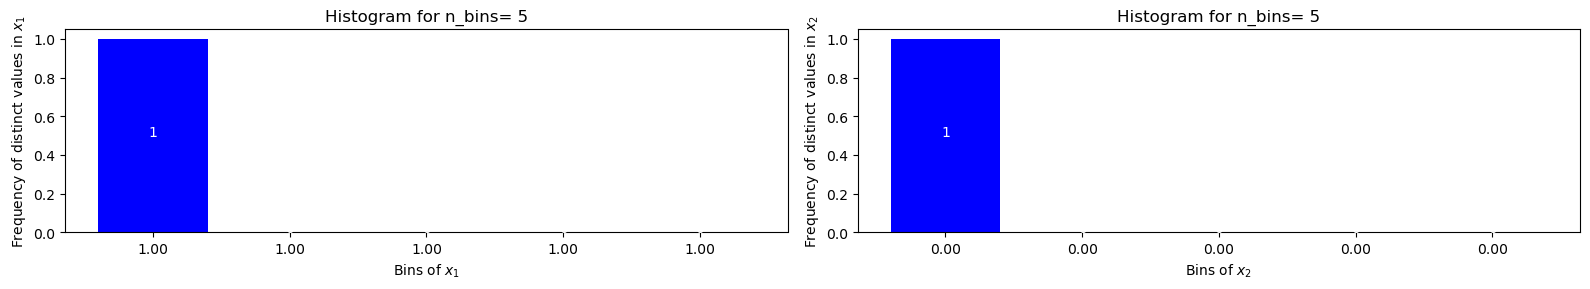

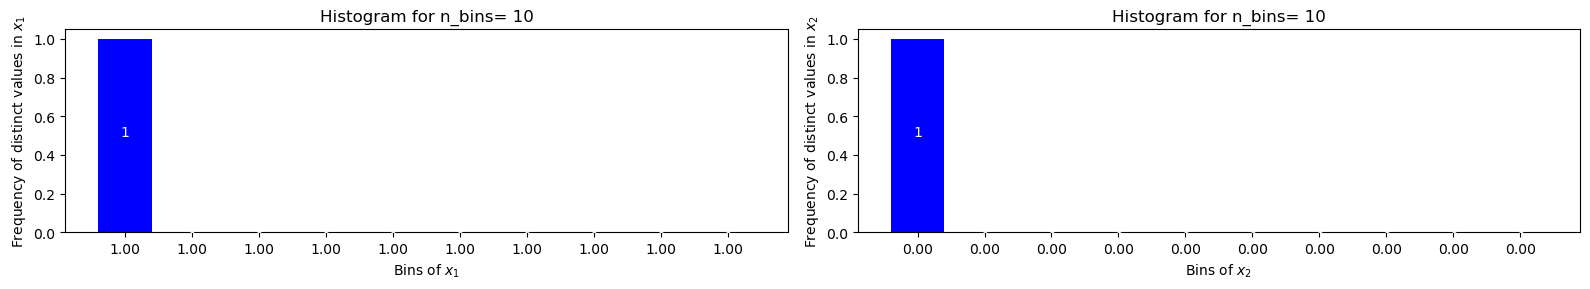

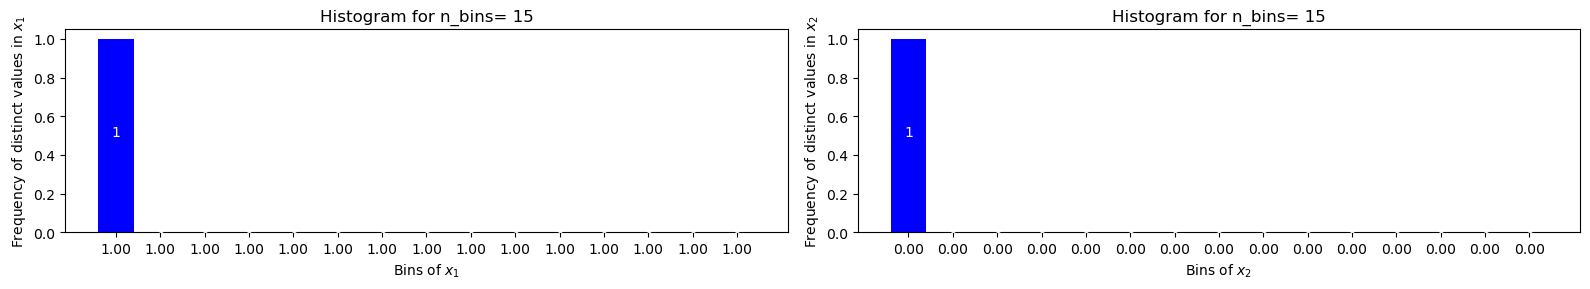

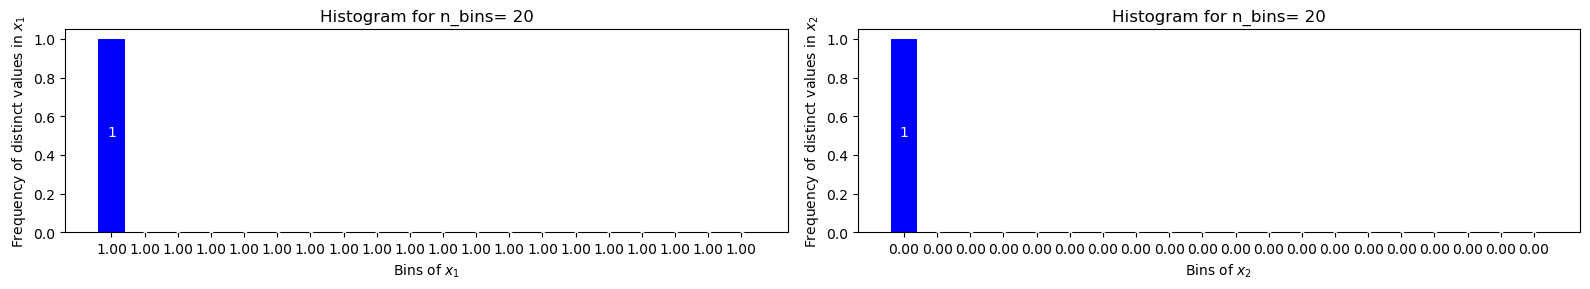

In [303]:
x_hist_pvi= []
y_hist_pvi= []
y_part_pvi= []
x_part_pvi= []
for n_bins in bins_list:
    partition_points = partition_interval(x_min, x_max, n_bins)
    x_part_pvi.append(partition_points)
#     print("Partition points:", partition_points)
    bin_counts = count_values_in_bins(x, partition_points)
    x_hist_pvi.append(bin_counts)
#     bin_counts= get_per(bin_counts)
#     print("Counts in each bin:", bin_counts)

    y_partition_points = partition_interval(y_min, y_max, n_bins)
    y_part_pvi.append(y_partition_points)
    y_bin_counts = count_values_in_bins(y, y_partition_points)
    y_hist_pvi.append(y_bin_counts)


    plt.figure(figsize=(16, 3))

    plt.subplot(1, 2, 1)
    bars = plt.bar(range(len(bin_counts)), bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(bin_counts)), ["{:.2f}".format(b) for b in partition_points[:-1]])
    plt.xlabel('Bins of $x_1$')
    plt.ylabel('Frequency of distinct values in $x_1$')
    plt.title('Histogram for n_bins= {}'.format(len(bin_counts)))
#     plt.grid(True)

    plt.subplot(1, 2, 2)
    bars = plt.bar(range(len(y_bin_counts)), y_bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(y_bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(y_bin_counts)), ["{:.2f}".format(b) for b in y_partition_points[:-1]])
    plt.xlabel('Bins of $x_2$')
    plt.ylabel('Frequency of distinct values in $x_2$')
    plt.title('Histogram for n_bins= {}'.format(len(y_bin_counts)))
#     plt.grid(True)
    plt.tight_layout()
#     plt.savefig('../PVI/solns_runs/Ex1/'+'ex1_pvi_hist'+str(n_bins)+'.png')
    plt.show()

In [304]:
# for (p,h) in zip(dist_,avg_hd):
#     print(p, " * ", h)

## Uniform CDF vs. empirical CDF and KS-Test

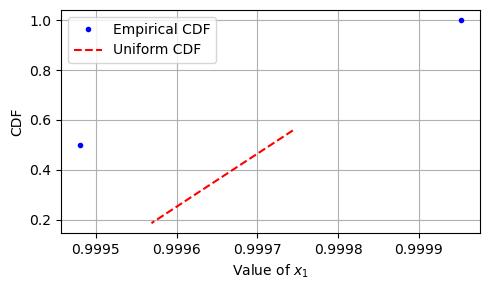

K-S Statistic: 0.999480721097423
P-Value: 5.393011573230836e-07
Reject the null hypothesis: The sample does not follow the uniform distribution.


In [305]:
# KS Test on x: 
a,b= np.min(xpvi), np.max(xpvi)
uniform_samples = np.random.uniform(low=a, high=b, size=len(xpvi))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

# Number of samples
n_samples = len(xpvi)

# Generate uniform values in [0,1]
#uniform_samples = np.random.uniform(low=0.0, high=1.0, size=n_samples)

# Plotting the histogram of uniform samples
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(xpvi)
ecdf_pvi_x = ECDF(xpvi) #np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_pvi_x.x, ecdf_pvi_x.y, marker='.', linestyle='none', label='Empirical CDF',c= 'blue')
# plt.plot([0.5, 1], [0.0, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples,cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples vs. Empiric')
plt.xlabel('Value of $x_1$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.savefig('../PVI/solns_runs/Ex1/ks_ex1_x1.png')
plt.show()

# Perform K-S test
ks_statistic, p_value = stats.kstest(xpvi, "uniform")#stats.kstest(ecdf.y, stats.uniform.cdf) #stats.kstest(ecdf.y, cdf_uniform)

# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.")

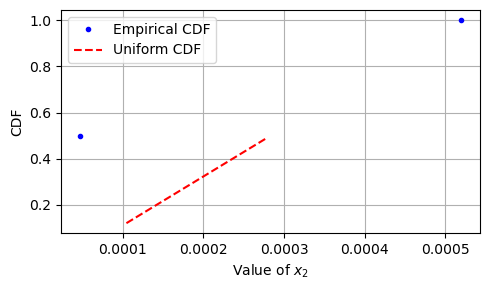

K-S Statistic: 0.9994807210974228
P-Value: 5.393011573235448e-07
Reject the null hypothesis: The sample does not follow the uniform distribution.


In [306]:
# KS Test on y: 
# Number of samples
a,b= np.min(ypvi), np.max(ypvi)
uniform_samples = np.random.uniform(low=a, high=b, size=len(ypvi))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

n_samples = len(ypvi)
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(ypvi)
ecdf_gsm_y = ECDF(ypvi) # np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_gsm_y.x, ecdf_gsm_y.y, marker='.', linestyle='none', label='Empirical CDF', c= 'blue')
# plt.plot([1-1, 1-0.5], [1-1, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples, cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples')
plt.xlabel('Value of $x_2$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.savefig('../PVI/solns_runs/Ex1/ks_ex1_x2.png')
plt.show()

# Perform K-S test
ks_statistic, p_value = stats.kstest(ypvi, "uniform")

# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.")


In [55]:
# T= 50

In [56]:
# T_list= [i for i in range(1,51)]
# result= []
# for T in T_list:
#     res= plot_for_T(T= T)
#     result.append(res)

In [57]:
# results= np.array(result)
# results

In [58]:
# # color=colors[row]
# plt.figure(figsize=(12, 4))
# for row in range(len(results)):
#     plt.title("Number of runs vs. % of distinct points for different number (starting) points")
#     plt.plot(titles, results[row], label= T_list[row])
# #     plt.plot(T_list, results[row,:], color=colors[row] , label= titles[row]) #label=title
#     plt.xlabel("Number of (starting) points.")
#     plt.xticks(titles)
#     plt.ylabel("Perentage of distint points")
#     plt.grid(True)
#     plt.legend(loc= 'upper left', bbox_to_anchor=(1, 1),title='Values of T')
#     plt.savefig('../PVI/solns_runs/Ex1/T1/plot_pviex1.png')

In [59]:
# import matplotlib.pyplot as plt

# # Assuming colors, results, titles, and T_list are defined
# # colors = [...]
# # results = [...]
# # titles = [...]
# # T_list = [...]

# def split_list(lst, n):
#     """Split a list into sublists each with n elements."""
#     for i in range(0, len(lst), n):
#         yield lst[i:i + n]

# # Number of elements per subplot
# n_elements_per_plot = 15

# # Splitting T_list, colors, and results into sublists of 10 elements each
# T_sublists = list(split_list(T_list, n_elements_per_plot))
# # color_sublists = list(split_list(colors, n_elements_per_plot))
# result_sublists = list(split_list(results, n_elements_per_plot))

# for i, (T_sublist, result_sublist) in enumerate(zip(T_sublists, result_sublists)):
#     plt.figure(figsize=(12, 4))
#     plt.title(f"Number of runs vs. % of distinct points for different number (starting) points (Part {i + 1})")
    
#     for row in range(len(T_sublist)):
#         plt.plot(titles, result_sublist[row], label=T_sublist[row])
# #         plt.plot(titles, result_sublist[row], color=color_sublist[row], label=T_sublist[row])
    
#     plt.xlabel("Number of (starting) points.")
#     plt.xticks(titles)
#     plt.ylabel("Percentage of distinct points")
#     plt.grid(True)
#     plt.legend(loc='upper left', bbox_to_anchor=(1, 1), title='Values of T')
# #     plt.savefig(f'../PVI/solns_runs/Ex1/T1/plot_pviex1_part_{i + 1}.png')
#     plt.show()

In [60]:
# Best
# T,num_points= 1,100

In [61]:
# # plt.figure(figsize=(10, 4))
# def plot_for_T(T):
#     main_path = "../PVI/solns_runs/Ex1/T"+str(T)
#     n_pts= nubmer_points_list[nubmer_points_list.index(num_points)]
#     subfolders = list_subfolders(main_path)[nubmer_points_list.index(num_points)]

#     titles = [str(100*i) for i in range(1, 16)]

#     colors = [
#         'blue', 'orange', 'r', 'yellow', 'purple',
#         'brown', 'pink', 'gray', 'olive', 'cyan', 'red',
#         'lightcoral', 'darkgoldenrod', 'mediumseagreen', 'green', 'mangeta'
#     ]

#     n_pts, n_rs, files= None,None, None
#     n_distn_tot= []
#     sol= []
#     files = list_txt_files(subfolders)
#     lam = discretize_time_interval(T, num_points)
#     res=[]
#     hd= []
#     for file in files:
        
#         solns= np.genfromtxt(subfolders+"/"+file, delimiter=',')

#         # Check solutions
#         solns=  check_with_lambda(solns, lam) # Do not check as g(x)= 0
#         sol.extend(solns)
        
#     #         print("*******")
#             ## Get distinct points
#         num, distinct_points = count_repeated_points(np.array(solns))
#     #         print(len(distinct_points),len(solns))
#         res.append((len(distinct_points)/(len(solns)))*100)
        
#         setX = np.random.uniform(low=0.0, high=1.0, size = len(distinct_points))
#         setY = np.random.uniform(low=0.0, high=1.0, size = len(distinct_points))

#         t_values = np.random.uniform(0.5, 1, len(distinct_points))

#         points = np.column_stack((t_values, 1 - t_values))
        
        
#         hausdorff_distance = directed_hausdorff(distinct_points, points)[0]
#         hd.append(hausdorff_distance)
        
#     return np.mean(res),sol,np.mean(hd)

In [62]:
# res,sol, hd= plot_for_T(T)

In [63]:
# sol= np.array(sol)
# sol

### Number of starting points vs. PDP and HD

In [64]:
# folders= ["../PVI/solns_runs/Ex1/T{}/N{}/".format(T,str(pt)) for pt in nubmer_points_list]
# folders

In [65]:
# def get_values(folders):
#     dist_= []
#     avg_hd= []
#     for pt in range(len(nubmer_points_list)):
#         directory_path = folders[pt]

#         files= list_txt_files_in_directory(directory_path)
#         res= []
#         hd= []
        
#         num_points= nubmer_points_list[pt]
#         setX = np.random.uniform(low=0.0, high=1.0, size = num_points)
#         setY = np.random.uniform(low=0.0, high=1.0, size = num_points)

#         t_values = np.random.uniform(0.5, 1, num_points)

#         points = np.column_stack((t_values, 1 - t_values))
        
#         lam = discretize_time_interval(T, num_points)
#         for file in files:
#             solns= np.genfromtxt(file, delimiter=',')
#             solns=  check_with_lambda(solns, lam)
#             num, distinct_points = count_repeated_points(solns)
#             distinct_points= np.array(distinct_points)
            
#             res.append((len(distinct_points)/(nubmer_points_list[pt]))*100)
            
#             hausdorff_distance = directed_hausdorff(solns, points)[0]
#             hd.append(hausdorff_distance)
            
#         dist_.append(np.mean(res))
#         avg_hd.append(np.mean(hd))
    
#     # Create subplots with different scales
#     fig, ax1 = plt.subplots(figsize=(8, 4))

#     # Create second axis with different scale
#     ax1.set_xlabel('Number of starting points')
# #     ax2 = ax1.twinx()
#     ax1.set_ylim([0.0, np.max(dist_)])
#     ax1.plot(nubmer_points_list, dist_, 'bo-')
    
# #     ax1.set_yticks(dist_)
    
#     ax1.set_ylabel('Perentage of distint points',color='blue')
# #     ax1.set_ylabel('Perentage of distint points', color='b')


#     # Create third axis with different scale
#     ax2 = ax1.twinx()
#     ax2.spines['right'].set_position(('outward', 60))  # Move the spine to the right
#     ax2.plot(nubmer_points_list, avg_hd, 'go-')
#     ax2.set_ylabel('Hausdorff Distance', color='g')
#     ax2.set_ylim([0.0, np.max(avg_hd)])

#     xticks = nubmer_points_list  # Precisely specify xticks from 0 to 10 with a step of 1
#     ax1.set_xticks(xticks)
#     ax1.set_xticklabels([f'{tick:.0f}' for tick in xticks])  # Format labels as strings with one decimal place


# #     plt.savefig('./plots/Metrics/Ex1/ex1_gsm.jpeg')
#     plt.savefig('../PVI/solns_runs/Ex1/plot_ex1.png')
# # plt.xticks(list(range(len(possible_num_points))),possible_num_points)
#     plt.grid(True)
#     plt.show()

        
#     return dist_,avg_hd

In [66]:
# pdp, hd= get_values(folders)

# BFGS

In [200]:
def list_subfolders(folder_path):
    subfolders = [f.path for f in os.scandir(folder_path) if f.is_dir()]
    sorted_subfolders = sorted(subfolders, key=lambda x: int(x.split("_")[-1]))
    return sorted_subfolders


def list_txt_files(folder_path):
    txt_files = [f for f in os.listdir(folder_path) if f.endswith('.txt')]
#     txt_files = sorted(txt_files, key=lambda x: int(x.split("_")[2]))
    return txt_files

### Number of starting points vs. PDP and HD

In [201]:
main_path = "../Merit/solns_runs_no_sols/Ex3/"
subfolders = list_subfolders(main_path)

    
txt_files = list_subfolders(subfolders[0])
# list_txt_files(subfolders[0])

titles = [str(100*i) for i in range(1, 16)]

colors = [
    'blue', 'orange', 'r', 'yellow', 'purple',
    'brown', 'pink', 'gray', 'olive', 'cyan', 'red',
    'lightcoral', 'darkgoldenrod', 'mediumseagreen', 'green', 'mangeta'
]

folders= ["../Merit/solns_runs_no_sols/Ex3/N_{}/".format(str(pt)) for pt in nubmer_points_list]
folders

['../Merit/solns_runs_no_sols/Ex3/N_100/',
 '../Merit/solns_runs_no_sols/Ex3/N_200/',
 '../Merit/solns_runs_no_sols/Ex3/N_300/',
 '../Merit/solns_runs_no_sols/Ex3/N_400/',
 '../Merit/solns_runs_no_sols/Ex3/N_500/',
 '../Merit/solns_runs_no_sols/Ex3/N_600/',
 '../Merit/solns_runs_no_sols/Ex3/N_700/',
 '../Merit/solns_runs_no_sols/Ex3/N_800/',
 '../Merit/solns_runs_no_sols/Ex3/N_900/',
 '../Merit/solns_runs_no_sols/Ex3/N_1000/',
 '../Merit/solns_runs_no_sols/Ex3/N_1100/',
 '../Merit/solns_runs_no_sols/Ex3/N_1200/',
 '../Merit/solns_runs_no_sols/Ex3/N_1300/',
 '../Merit/solns_runs_no_sols/Ex3/N_1400/',
 '../Merit/solns_runs_no_sols/Ex3/N_1500/']

In [202]:
# xgsm
# ygsm
# ecdfgsm= ECDF(xgsm) #np.arange(1, n_samples+1) / n_samples
# ecdfeia= ECDF(xeia) #np.arange(1, n_samples+1) / n_samples
# ecdfpvi= ECDF(xpvi) #np.arange(1, n_samples+1) / n_samples
# ecdfsgd= ECDF(xsgd) #np.arange(1, n_samples+1) / n_samples

In [203]:
# def get_values(folders):
#     dist_= []
#     avg_hd= []
#     for pt in range(len(nubmer_points_list)):
#         directory_path = folders[pt]

#         files= list_txt_files_in_directory(directory_path)
#         res= []
#         hd= []
        
#         num_points= nubmer_points_list[pt]
#         setX = np.random.uniform(low=0.0, high=1.0, size = num_points)
#         setY = np.random.uniform(low=0.0, high=1.0, size = num_points)

#         t_values = np.random.uniform(0.5, 1, num_points)

#         points = np.column_stack((t_values, 1 - t_values))
        
#         for file in files:
#             if "._" in file:
#                 file= file.replace("._","")
#             solns= np.genfromtxt(file, delimiter=',')
#             num, distinct_points,_ = count_repeated_points(solns)
#             distinct_points= np.array(distinct_points)
            
#             res.append((len(distinct_points)/(nubmer_points_list[pt]))*100)
            
#             hausdorff_distance = directed_hausdorff(solns, points)[0]
#             hd.append(hausdorff_distance)
            
#         dist_.append(np.mean(res))
#         avg_hd.append(np.mean(hd))
    
#     # Create subplots with different scales
#     fig, ax1 = plt.subplots(figsize=(8, 4))

#     # Create second axis with different scale
#     ax1.set_xlabel('Number of starting points')
# #     ax2 = ax1.twinx()
#     ax1.set_ylim([0.0, np.max(dist_)])
#     ax1.plot(nubmer_points_list, dist_, 'bo-')
    
# #     ax1.set_yticks(dist_)
    
#     ax1.set_ylabel('Perentage of distint points',color='blue')
# #     ax1.set_ylabel('Perentage of distint points', color='b')


#     # Create third axis with different scale
#     ax2 = ax1.twinx()
#     ax2.spines['right'].set_position(('outward', 60))  # Move the spine to the right
#     ax2.plot(nubmer_points_list, avg_hd, 'go-')
#     ax2.set_ylabel('Hausdorff Distance', color='g')
#     ax2.set_ylim([0.0, np.max(avg_hd)])

#     xticks = nubmer_points_list  # Precisely specify xticks from 0 to 10 with a step of 1
#     ax1.set_xticks(xticks)
#     ax1.set_xticklabels([f'{tick:.0f}' for tick in xticks])  # Format labels as strings with one decimal place


# #     plt.savefig('./plots/Metrics/Ex1/ex1_gsm.jpeg')
#     plt.savefig('../Merit/solns_runs/Ex1/plot_ex1.png')
# # plt.xticks(list(range(len(possible_num_points))),possible_num_points)
#     plt.grid(True)
#     plt.show()

        
#     return dist_,avg_hd

# def get_values(folders):
#     dist_= []
#     avg_hd= []
#     global_pts= []
#     tolerance= []
# #     global_pdp= []
#     for pt in range(len(nubmer_points_list)):
#         directory_path = folders[pt]

#         files= list_txt_files_in_directory(directory_path)
#         res= []
#         hd= []
        
#         num_points= nubmer_points_list[pt]
#         setX = np.random.uniform(low=0.0, high=1.0, size = num_points)
#         setY = np.random.uniform(low=0.0, high=1.0, size = num_points)

#         t_values = np.random.uniform(0.5, 1, num_points)

#         points = np.column_stack((t_values, 1 - t_values))
#         pts= []
#         tols= []
#         for file in files:
#             solns= np.genfromtxt(file, delimiter=',')
#             num, distinct_points,tol = count_repeated_points(solns)
#             distinct_points= np.array(distinct_points)
#             pts.extend(distinct_points.tolist())
            
#             res.append((len(distinct_points)/(nubmer_points_list[pt]))*100)
            
#             hausdorff_distance = directed_hausdorff(solns, points)[0]
#             hd.append(hausdorff_distance)
#             tols.append(tol)
            
#         dist_.append(np.mean(res))
#         avg_hd.append(np.mean(hd))
#         global_pts.append(pts)
#         tolerance.append(np.mean(tols))
    
#     # Create subplots with different scales
#     fig, ax1 = plt.subplots(figsize=(8, 4))

#     # Create second axis with different scale
#     ax1.set_xlabel('Number of starting points')
# #     ax2 = ax1.twinx()
#     ax1.set_ylim([0.0, np.max(dist_)])
#     ax1.plot(nubmer_points_list, dist_, 'bo-')
    
# #     ax1.set_yticks(dist_)
    
#     ax1.set_ylabel('Perentage of distint points',color='blue')
# #     ax1.set_ylabel('Perentage of distint points', color='b')


#     # Create third axis with different scale
#     ax2 = ax1.twinx()
#     ax2.spines['right'].set_position(('outward', 60))  # Move the spine to the right
#     ax2.plot(nubmer_points_list, avg_hd, 'go-')
#     ax2.set_ylabel('Hausdorff Distance', color='g')
#     ax2.set_ylim([0.0, np.max(avg_hd)])

#     xticks = nubmer_points_list  # Precisely specify xticks from 0 to 10 with a step of 1
#     ax1.set_xticks(xticks)
#     ax1.set_xticklabels([f'{tick:.0f}' for tick in xticks])  # Format labels as strings with one decimal place


# #     plt.savefig('./plots/Metrics/Ex1/ex1_gsm.jpeg')
#     plt.savefig('../GSM/solns_runs/Ex1/plot_ex1.png')
# # plt.xticks(list(range(len(possible_num_points))),possible_num_points)
#     plt.grid(True)
#     plt.show()

        
#     return dist_, avg_hd,tolerance
# # , global_pts

def get_values(folders):
    dist_= []
    avg_hd= []
    for pt in range(len(nubmer_points_list)):
        directory_path = folders[pt]

        files= list_txt_files_in_directory(directory_path)
        if len(files)>n_times:
            files= files[:n_times]
        res= []
        hd= []
        
        num_points= nubmer_points_list[pt]

        
        res_solns= []
        for file in files:
            
            if "._" in file:
                    file= file.replace("._","")
            
            solns= np.genfromtxt(file, delimiter=',')
            res_solns.extend(solns.tolist())

        res_solns= np.array(res_solns)
        num, distinct_points,_ = count_repeated_points(res_solns)
        distinct_points= np.array(distinct_points)
        
        # Get PDP
        
        dist_.append((len(distinct_points)/(len(res_solns)))*100)
        
        # Get HD:
        t_values = np.random.uniform(0.5, 1, len(distinct_points))

        points = np.column_stack((t_values, 1 - t_values))
        

        print(len(res_solns), len(distinct_points))
        hausdorff_distance = directed_hausdorff(distinct_points, points)[0]
        avg_hd.append(hausdorff_distance)
        
    # Create subplots with different scales
    fig, ax1 = plt.subplots(figsize=(8, 4))

    # Create second axis with different scale
    ax1.set_xlabel('Number of starting points')
#     ax2 = ax1.twinx()
    ax1.set_ylim([0.0, np.max(dist_)])
    ax1.plot(nubmer_points_list, dist_, 'bo-')
    
#     ax1.set_yticks(dist_)
    
    ax1.set_ylabel('Perentage of distint points',color='blue')
#     ax1.set_ylabel('Perentage of distint points', color='b')


    # Create third axis with different scale
    ax2 = ax1.twinx()
    ax2.spines['right'].set_position(('outward', 60))  # Move the spine to the right
    ax2.plot(nubmer_points_list, avg_hd, 'go-')
    ax2.set_ylabel('Hausdorff Distance', color='g')
    ax2.set_ylim([0.0, np.max(avg_hd)])

    xticks = nubmer_points_list  # Precisely specify xticks from 0 to 10 with a step of 1
    ax1.set_xticks(xticks)
    ax1.set_xticklabels([f'{tick:.0f}' for tick in xticks])  # Format labels as strings with one decimal place


#     plt.savefig('./plots/Metrics/Ex1/ex1_gsm.jpeg')
    plt.savefig('../Merit/solns_runs/Ex1/plot_ex1.png')
# plt.xticks(list(range(len(possible_num_points))),possible_num_points)
    plt.grid(True)
    plt.show()

        
    return dist_,avg_hd

In [204]:
#pdpbfgs, hdbfgs= get_values(folders)

In [205]:
#for (p,h) in zip(pdpbfgs,hdbfgs):
 #   print(p, " * ", h)

In [206]:
#max(pdpbfgs), min(hdbfgs)

In [207]:
# plot_solns(folders)

### Histograms

In [208]:
# n_runs= 50 and 
n_points= 1500
# Best
directory_path = "../Merit/solns_runs_no_sols/Ex3/N_{}".format(n_points)
all_solnsbfgs= []

files= list_txt_files_in_directory(directory_path)
if len(files)>n_times:
    files= files[:n_times]
for file in files:
    if "._" in file:
        file= file.replace("._","")
    solns= np.genfromtxt(file, delimiter=',')

#     num, distinct_points,_ = count_repeated_points(solns)
#     distinct_points= np.array(distinct_points)
    all_solnsbfgs.extend(solns.tolist())
    break

all_solnsbfgs= np.array(all_solnsbfgs)
num, all_solnsbfgs= count_repeated_points(all_solnsbfgs)
all_solnsbfgs= np.array(all_solnsbfgs)

In [209]:
len(all_solnsbfgs)

1157

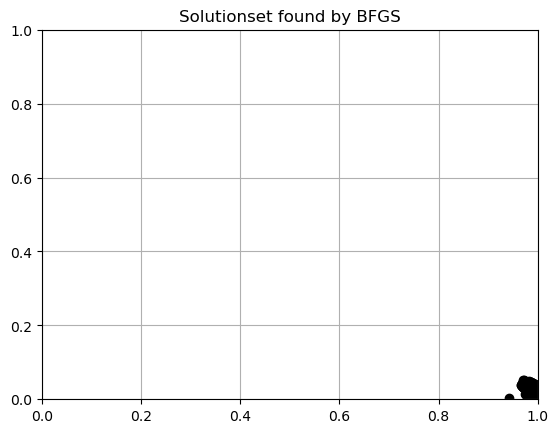

In [210]:
plt.scatter(all_solnsbfgs[:,0], all_solnsbfgs[:,1], c= 'black')
plt.xlim([0,1])
plt.ylim([0,1])
plt.grid(True)
plt.title("Solutionset found by BFGS")
plt.savefig('./Ex_with_no_sols/Figures/Ex3/BFGS_ex3.png', dpi=180, bbox_inches='tight')
plt.show()

In [211]:
## x:
bins_list= [5, 10, 15, 20]
solns= all_solnsbfgs.copy()
x= solns[:,0]
x_min = np.min(x)
x_max = np.max(x)

## y:
y= solns[:,1]
y_min = np.min(y)
y_max = np.max(y)
# y

xbfgs= x.copy()
ybfgs= y.copy()

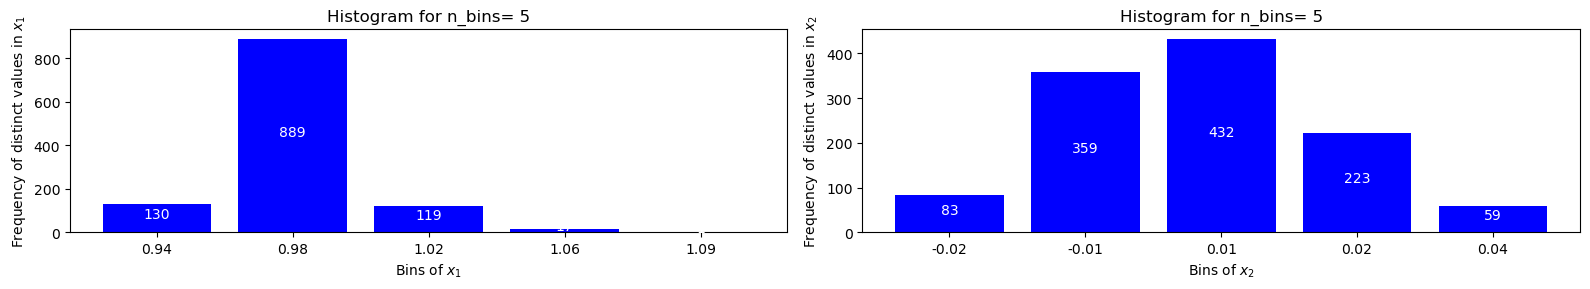

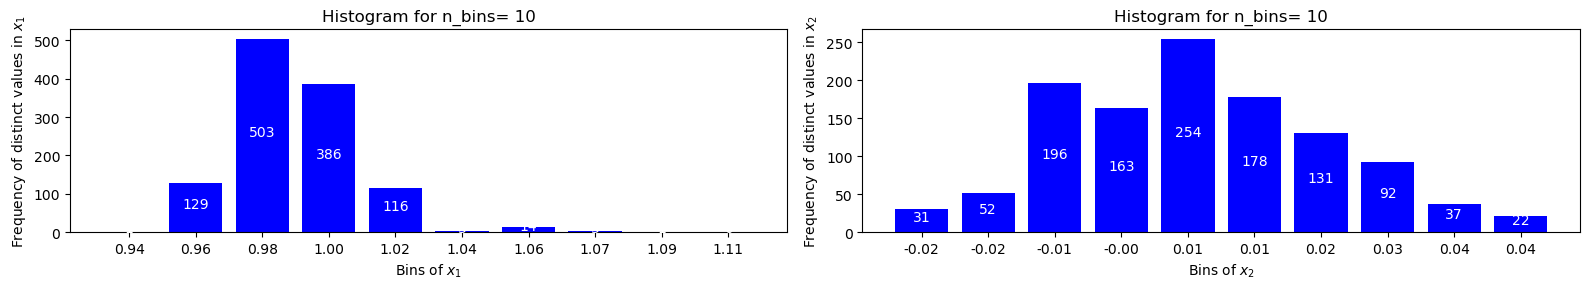

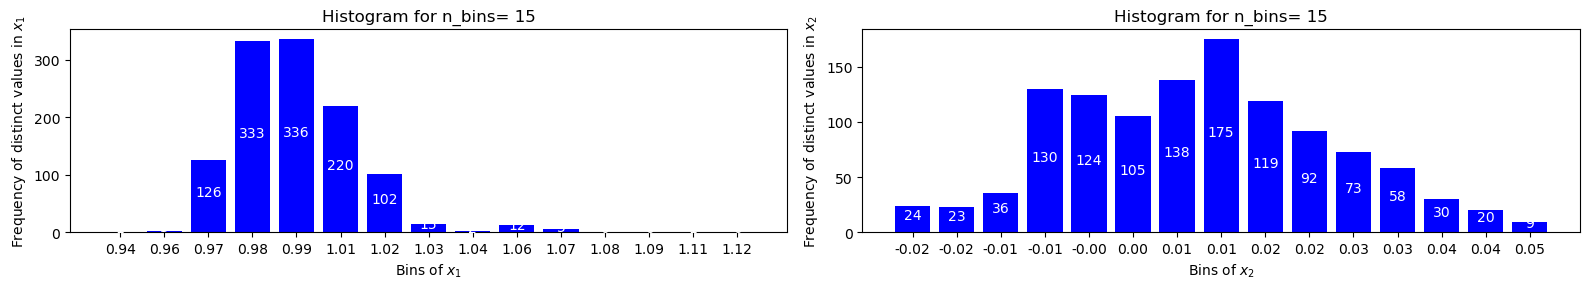

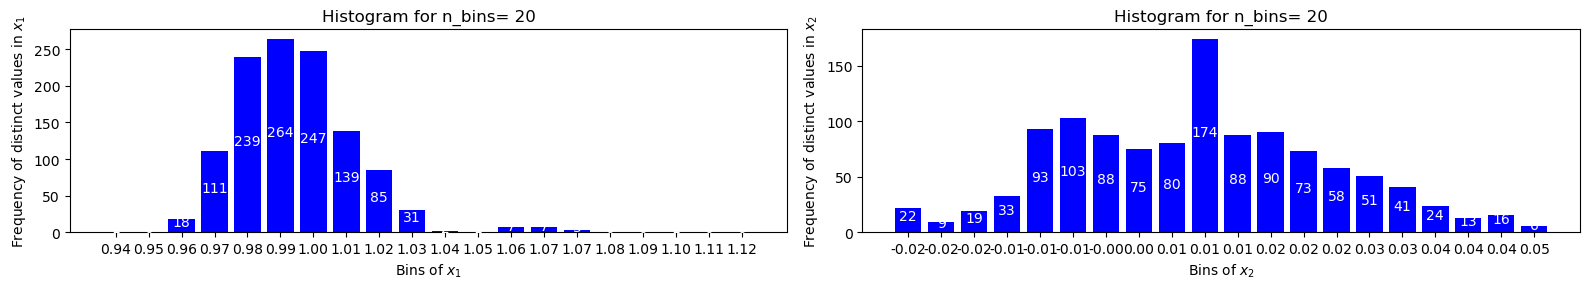

In [212]:
x_hist_bfgs= []
y_hist_bfgs= []
y_part_bfgs= []
x_part_bfgs= []
for n_bins in bins_list:
    partition_points = partition_interval(x_min, x_max, n_bins)
    x_part_bfgs.append(partition_points)
#     print("Partition points:", partition_points)
    bin_counts = count_values_in_bins(x, partition_points)
    x_hist_bfgs.append(bin_counts)
#     bin_counts= get_per(bin_counts)
#     print("Counts in each bin:", bin_counts)

    y_partition_points = partition_interval(y_min, y_max, n_bins)
    y_part_bfgs.append(y_partition_points)
    y_bin_counts = count_values_in_bins(y, y_partition_points)
    y_hist_bfgs.append(y_bin_counts)


    plt.figure(figsize=(16, 3))

    plt.subplot(1, 2, 1)
    bars = plt.bar(range(len(bin_counts)), bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(bin_counts)), ["{:.2f}".format(b) for b in partition_points[:-1]])
    plt.xlabel('Bins of $x_1$')
    plt.ylabel('Frequency of distinct values in $x_1$')
    plt.title('Histogram for n_bins= {}'.format(len(bin_counts)))
#     plt.grid(True)

    plt.subplot(1, 2, 2)
    bars = plt.bar(range(len(y_bin_counts)), y_bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(y_bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(y_bin_counts)), ["{:.2f}".format(b) for b in y_partition_points[:-1]])
    plt.xlabel('Bins of $x_2$')
    plt.ylabel('Frequency of distinct values in $x_2$')
    plt.title('Histogram for n_bins= {}'.format(len(y_bin_counts)))
#     plt.grid(True)
    plt.tight_layout()
    #plt.savefig('../Merit/solns_runs/Ex1/'+'ex1_bfgs_hist'+str(n_bins)+'.png')
    plt.show()

### Uniform CDF vs. empirical CDF and KS-Test

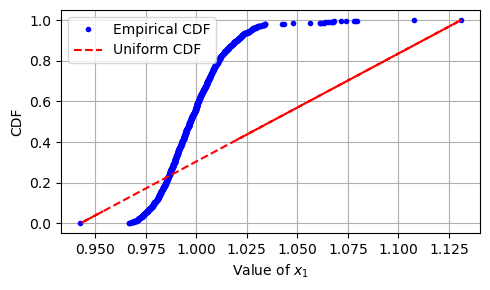

K-S Statistic: 0.9656252561715926
P-Value: 0.0
Reject the null hypothesis: The sample does not follow the uniform distribution.


In [213]:
 # KS Test on x: 
a,b= np.min(xbfgs),np.max(xbfgs)
uniform_samples = np.random.uniform(low=a, high=b, size=len(x))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

# Number of samples
n_samples = len(xbfgs)

# Generate uniform values in [0,1]
#uniform_samples = np.random.uniform(low=0.0, high=1.0, size=n_samples)

# Plotting the histogram of uniform samples
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(xbfgs)
ecdf_bfgs_x = ECDF(xbfgs) #np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_bfgs_x.x, ecdf_bfgs_x.y, marker='.', linestyle='none', label='Empirical CDF',c= 'blue')
# plt.plot([0.5, 1], [0.0, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples,cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples vs. Empiric')
plt.xlabel('Value of $x_1$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
#plt.savefig('../Merit/solns_runs/Ex1/ks_ex1_x1.png')
plt.show()

# Perform K-S test
ks_statistic, p_value = stats.kstest(xbfgs, "uniform")#stats.kstest(ecdf.y, stats.uniform.cdf) #stats.kstest(ecdf.y, cdf_uniform)

# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.")

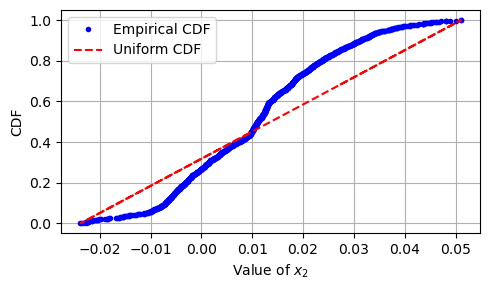

K-S Statistic: 0.9489252531810776
P-Value: 0.0
Reject the null hypothesis: The sample does not follow the uniform distribution.


In [214]:
# KS Test on y: 
# Number of samples
a,b= np.min(ybfgs),np.max(ybfgs)
uniform_samples = np.random.uniform(low=a, high=b, size=len(x))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

n_samples = len(ybfgs)
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(ybfgs)
ecdf_bfgs_y = ECDF(ybfgs) # np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_bfgs_y.x, ecdf_bfgs_y.y, marker='.', linestyle='none', label='Empirical CDF', c= 'blue')
# plt.plot([1-1, 1-0.5], [1-1, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples, cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples')
plt.xlabel('Value of $x_2$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
#plt.savefig('../Merit/solns_runs/Ex1/ks_ex1_x2.png')
plt.show()

# Perform K-S test
ks_statistic, p_value = stats.kstest(ybfgs, "uniform")

# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.")

# EIA

## Number of starting points vs. PDP and HD

In [227]:
main_path = "../EIA/solns_runs_no_sols/Ex3/"
subfolders = list_subfolders(main_path)

    
txt_files = list_subfolders(subfolders[0])
# list_txt_files(subfolders[0])

titles = [str(100*i) for i in range(1, 16)]

colors = [
    'blue', 'orange', 'r', 'yellow', 'purple',
    'brown', 'pink', 'gray', 'olive', 'cyan', 'red',
    'lightcoral', 'darkgoldenrod', 'mediumseagreen', 'green', 'mangeta'
]

folders= ["../EIA/solns_runs_no_sols/Ex3/N_{}/".format(str(pt)) for pt in nubmer_points_list]
folders

['../EIA/solns_runs_no_sols/Ex3/N_100/',
 '../EIA/solns_runs_no_sols/Ex3/N_200/',
 '../EIA/solns_runs_no_sols/Ex3/N_300/',
 '../EIA/solns_runs_no_sols/Ex3/N_400/',
 '../EIA/solns_runs_no_sols/Ex3/N_500/',
 '../EIA/solns_runs_no_sols/Ex3/N_600/',
 '../EIA/solns_runs_no_sols/Ex3/N_700/',
 '../EIA/solns_runs_no_sols/Ex3/N_800/',
 '../EIA/solns_runs_no_sols/Ex3/N_900/',
 '../EIA/solns_runs_no_sols/Ex3/N_1000/',
 '../EIA/solns_runs_no_sols/Ex3/N_1100/',
 '../EIA/solns_runs_no_sols/Ex3/N_1200/',
 '../EIA/solns_runs_no_sols/Ex3/N_1300/',
 '../EIA/solns_runs_no_sols/Ex3/N_1400/',
 '../EIA/solns_runs_no_sols/Ex3/N_1500/']

In [228]:
#plot_solns(folders)

### Histograms

In [239]:
n_points= 1500
# Best
directory_path = "../EIA/solns_runs_no_sols/Ex3/N_{}".format(n_points)
all_solnseia= []

files= list_txt_files_in_directory(directory_path)
if len(files)>n_times:
        files= files[:n_times]
for file in files:
    if "._" in file:
        file= file.replace("._","")
    solns= np.genfromtxt(file, delimiter=',')
    all_solnseia.extend(solns.tolist())
#     break

all_solnseia= np.array(all_solnseia)
print(len(all_solnseia))
num, all_solnseia = count_repeated_points(all_solnseia)
all_solnseia= np.array(all_solnseia)

15000


In [240]:
print(len(all_solnseia))

514


In [241]:
all_solnseia

array([[0.99019127, 0.01555964],
       [0.99023224, 0.01410506],
       [0.99024212, 0.01560822],
       ...,
       [0.9998027 , 0.00791693],
       [0.99981432, 0.01157519],
       [0.99985318, 0.00890252]])

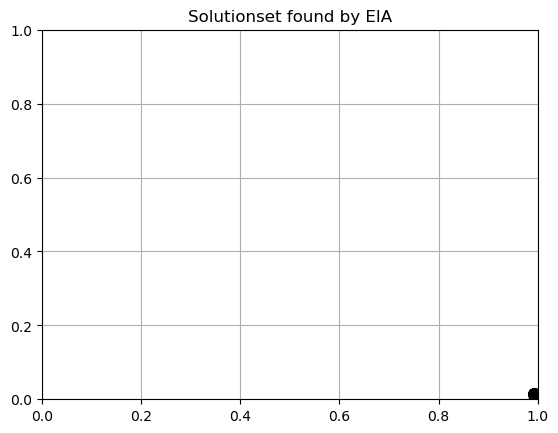

In [242]:
plt.scatter(all_solnseia[:,0], all_solnseia[:,1], c= 'black')
plt.xlim([0,1])
plt.ylim([0,1])
plt.grid(True)
plt.title("Solutionset found by EIA")
plt.savefig('./Ex_with_no_sols/Figures/Ex3/EAI_ex3.png', dpi=180, bbox_inches='tight')
plt.show()

In [176]:
## x:
bins_list= [5, 10, 15, 20]
solns= all_solnseia.copy()
x= solns[:,0]
x_min = np.min(x)
x_max = np.max(x)

## y:
y= solns[:,1]
y_min = np.min(y)
y_max = np.max(y)
# y

xeia= x.copy()
yeia= y.copy()

In [177]:
len(all_solnseia)

5

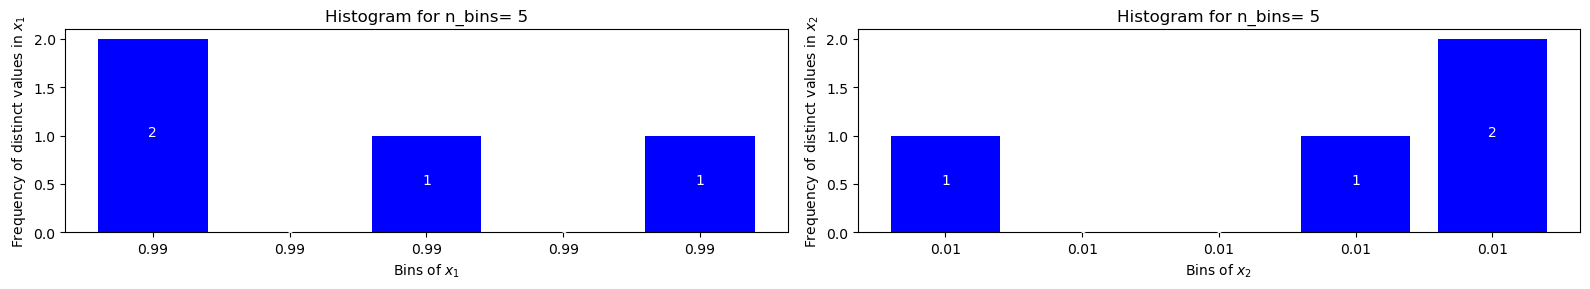

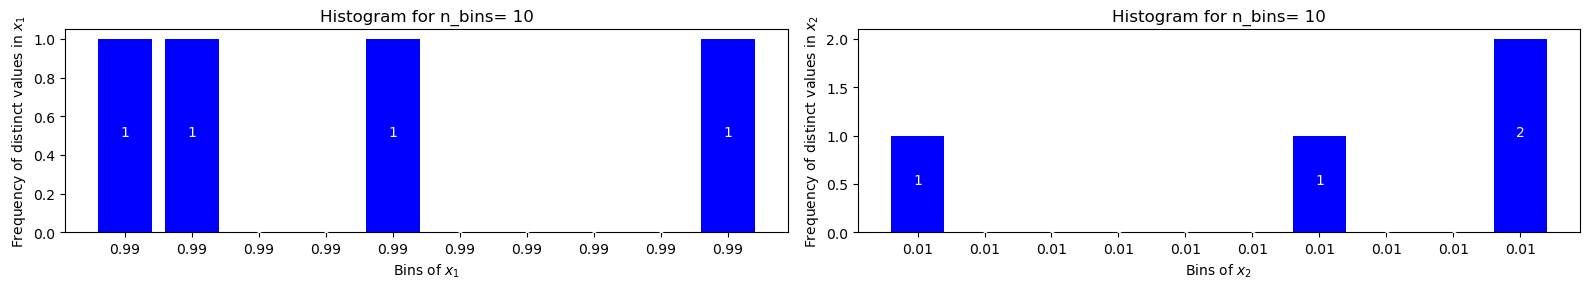

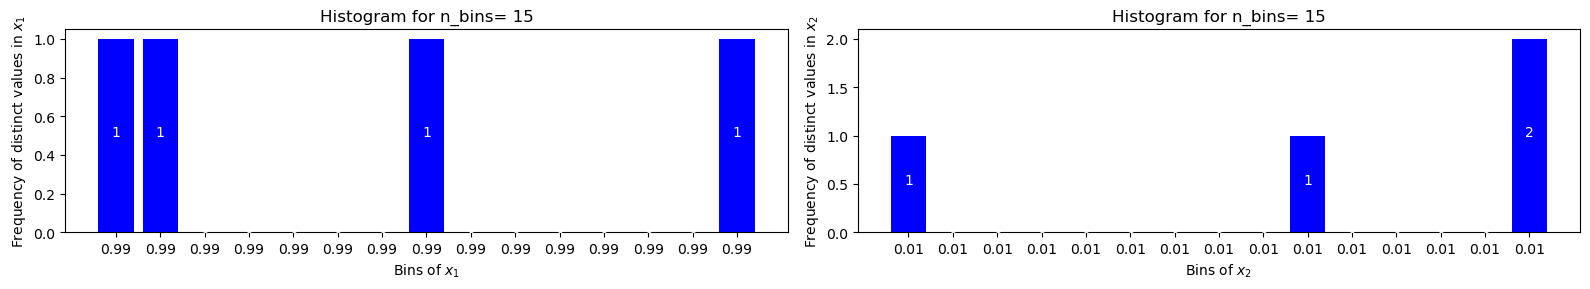

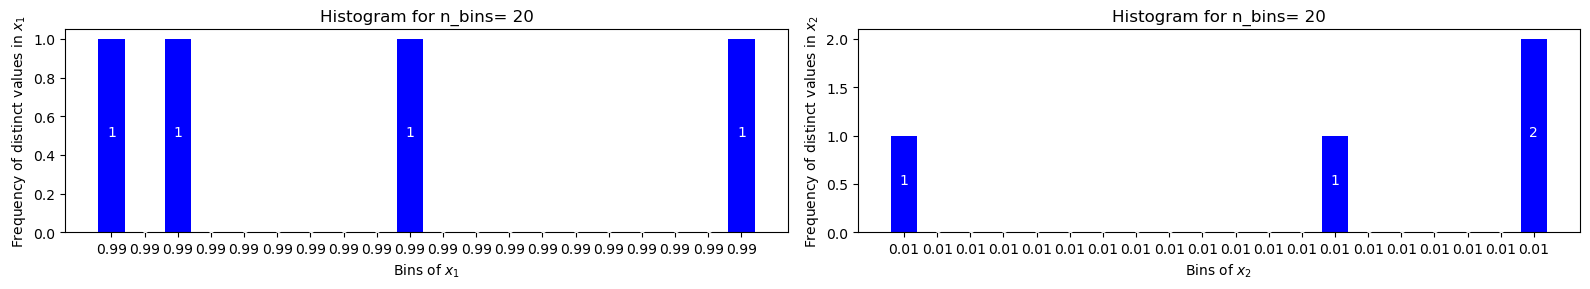

In [178]:
x_hist_eia= []
y_hist_eia= []
y_part_eia= []
x_part_eia= []
for n_bins in bins_list:
    partition_points = partition_interval(x_min, x_max, n_bins)
    x_part_eia.append(partition_points)
#     print("Partition points:", partition_points)
    bin_counts = count_values_in_bins(x, partition_points)
    x_hist_eia.append(bin_counts)
#     bin_counts= get_per(bin_counts)
#     print("Counts in each bin:", bin_counts)

    y_partition_points = partition_interval(y_min, y_max, n_bins)
    y_part_eia.append(y_partition_points)
    y_bin_counts = count_values_in_bins(y, y_partition_points)
    y_hist_eia.append(y_bin_counts)


    plt.figure(figsize=(16, 3))

    plt.subplot(1, 2, 1)
    bars = plt.bar(range(len(bin_counts)), bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(bin_counts)), ["{:.2f}".format(b) for b in partition_points[:-1]])
    plt.xlabel('Bins of $x_1$')
    plt.ylabel('Frequency of distinct values in $x_1$')
    plt.title('Histogram for n_bins= {}'.format(len(bin_counts)))
#     plt.grid(True)

    plt.subplot(1, 2, 2)
    bars = plt.bar(range(len(y_bin_counts)), y_bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(y_bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(y_bin_counts)), ["{:.2f}".format(b) for b in y_partition_points[:-1]])
    plt.xlabel('Bins of $x_2$')
    plt.ylabel('Frequency of distinct values in $x_2$')
    plt.title('Histogram for n_bins= {}'.format(len(y_bin_counts)))
#     plt.grid(True)
    plt.tight_layout()
    #plt.savefig('../EIA/solns_runs/Ex1/'+'ex1_eia_hist'+str(n_bins)+'.png')
    plt.show()

### Uniform CDF vs. empirical CDF and  KS-Test

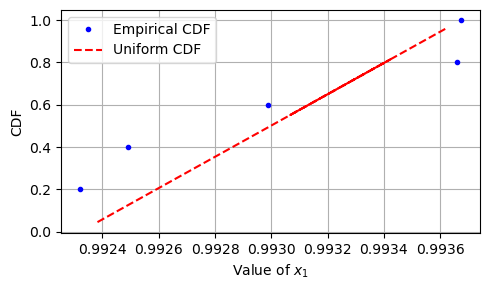

K-S Statistic: 0.992321672149619
P-Value: 5.337811762986199e-11
Reject the null hypothesis: The sample does not follow the uniform distribution.


In [179]:
# KS Test on x: 
a,b= np.min(xeia),np.max(xeia)
uniform_samples = np.random.uniform(low=a, high=b, size=len(xeia))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

# Number of samples
n_samples = len(xeia)

# Generate uniform values in [0,1]
#uniform_samples = np.random.uniform(low=0.0, high=1.0, size=n_samples)

# Plotting the histogram of uniform samples
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(xeia)
ecdf_eia_x = ECDF(xeia) #np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_eia_x.x, ecdf_eia_x.y, marker='.', linestyle='none', label='Empirical CDF',c= 'blue')
# plt.plot([0.5, 1], [0.0, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples,cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples vs. Empiric')
plt.xlabel('Value of $x_1$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
#plt.savefig('../EIA/solns_runs/Ex1/ks_ex1_x1.png')
plt.show()

# Perform K-S test
ks_statistic, p_value = stats.kstest(xeia, "uniform")#stats.kstest(ecdf.y, stats.uniform.cdf) #stats.kstest(ecdf.y, cdf_uniform)

# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.") 

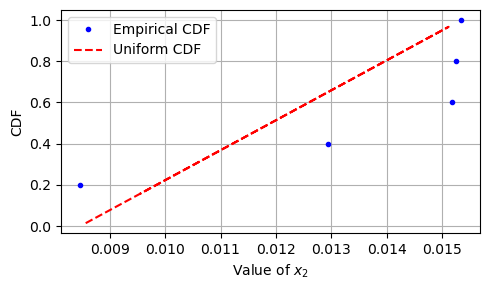

K-S Statistic: 0.9846610172464552
P-Value: 1.698293672022554e-09
Reject the null hypothesis: The sample does not follow the uniform distribution.


In [180]:
# KS Test on y: 
# Number of samples
a,b= np.min(yeia),np.max(yeia)
uniform_samples = np.random.uniform(low=a, high=b, size=len(xeia))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

n_samples = len(yeia)
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(yeia)
ecdf_eia_y = ECDF(yeia) # np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_eia_y.x, ecdf_eia_y.y, marker='.', linestyle='none', label='Empirical CDF', c= 'blue')
# plt.plot([1-1, 1-0.5], [1-1, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples, cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples')
plt.xlabel('Value of $x_2$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
#plt.savefig('../EIA/solns_runs/Ex1/ks_ex1_x2.png')
plt.show()

# Perform K-S test
ks_statistic, p_value = stats.kstest(yeia, "uniform")

# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.")

In [181]:
ks_statistic,p_value

(0.9846610172464552, 1.698293672022554e-09)

# SGD

## Number of starting points vs. PDP and HD

In [182]:
main_path = "../SGD/solns_runs_no_sols/Ex3/"
subfolders = list_subfolders(main_path)

    
txt_files = list_subfolders(subfolders[0])
# list_txt_files(subfolders[0])

titles = [str(100*i) for i in range(1, 16)]

colors = [
    'blue', 'orange', 'r', 'yellow', 'purple',
    'brown', 'pink', 'gray', 'olive', 'cyan', 'red',
    'lightcoral', 'darkgoldenrod', 'mediumseagreen', 'green', 'mangeta'
]

folders= ["../SGD/solns_runs_no_sols/Ex3/N_{}/".format(str(pt)) for pt in nubmer_points_list]
folders

['../SGD/solns_runs_no_sols/Ex3/N_100/',
 '../SGD/solns_runs_no_sols/Ex3/N_200/',
 '../SGD/solns_runs_no_sols/Ex3/N_300/',
 '../SGD/solns_runs_no_sols/Ex3/N_400/',
 '../SGD/solns_runs_no_sols/Ex3/N_500/',
 '../SGD/solns_runs_no_sols/Ex3/N_600/',
 '../SGD/solns_runs_no_sols/Ex3/N_700/',
 '../SGD/solns_runs_no_sols/Ex3/N_800/',
 '../SGD/solns_runs_no_sols/Ex3/N_900/',
 '../SGD/solns_runs_no_sols/Ex3/N_1000/',
 '../SGD/solns_runs_no_sols/Ex3/N_1100/',
 '../SGD/solns_runs_no_sols/Ex3/N_1200/',
 '../SGD/solns_runs_no_sols/Ex3/N_1300/',
 '../SGD/solns_runs_no_sols/Ex3/N_1400/',
 '../SGD/solns_runs_no_sols/Ex3/N_1500/']

In [183]:
# def get_values(folders):
#     dist_= []
#     avg_hd= []
#     for pt in range(len(nubmer_points_list)):
#         directory_path = folders[pt]

#         files= list_txt_files_in_directory(directory_path)
#         res= []
#         hd= []
        
#         num_points= nubmer_points_list[pt]

#         t_values = np.random.uniform(0.5, 1, num_points)

#         points = np.column_stack((t_values, 1 - t_values))
        
#         for file in files:
#             if "._" in file:
#                 file= file.replace("._","")
#             solns= np.genfromtxt(file, delimiter=',')#[:,:-1]
#             mask= solns[:,-1]<0.01
#             solns= solns[:,:-1][mask]
#             num, distinct_points,_ = count_repeated_points(solns)
#             distinct_points= np.array(distinct_points)
            
#             res.append((len(distinct_points)/(len(solns)))*100)
        
#             hausdorff_distance = directed_hausdorff(solns, points)[0]
#             hd.append(hausdorff_distance)
            
#         dist_.append(np.mean(res))
#         avg_hd.append(np.mean(hd))
    
#     # Create subplots with different scales
#     fig, ax1 = plt.subplots(figsize=(8, 4))

#     # Create second axis with different scale
#     ax1.set_xlabel('Number of starting points')
# #     ax2 = ax1.twinx()
#     ax1.set_ylim([0.0, np.max(dist_)])
#     ax1.plot(nubmer_points_list, dist_, 'bo-')
    
# #     ax1.set_yticks(dist_)
    
#     ax1.set_ylabel('Perentage of distint points',color='blue')
# #     ax1.set_ylabel('Perentage of distint points', color='b')


#     # Create third axis with different scale
#     ax2 = ax1.twinx()
#     ax2.spines['right'].set_position(('outward', 60))  # Move the spine to the right
#     ax2.plot(nubmer_points_list , avg_hd, 'go-')
#     ax2.set_ylabel('Hausdorff Distance', color='g')
#     ax2.set_ylim([0.0, np.max(avg_hd)])

#     xticks = nubmer_points_list  # Precisely specify xticks from 0 to 10 with a step of 1
#     ax1.set_xticks(xticks)
#     ax1.set_xticklabels([f'{tick:.0f}' for tick in xticks])  # Format labels as strings with one decimal place


# #     plt.savefig('./plots/Metrics/Ex1/ex1_gsm.jpeg')
#     plt.savefig('../SGD/solns_runs/Ex1/plot_ex1.png')
# # plt.xticks(list(range(len(possible_num_points))),possible_num_points)
#     plt.grid(True)
#     plt.show()

        
#     return dist_,avg_hd

# def get_values(folders):
#     dist_= []
#     avg_hd= []
#     global_pts= []
#     tolerance= []
# #     global_pdp= []
#     for pt in range(len(nubmer_points_list)):
#         directory_path = folders[pt]

#         files= list_txt_files_in_directory(directory_path)
#         res= []
#         hd= []
        
#         num_points= nubmer_points_list[pt]
#         setX = np.random.uniform(low=0.0, high=1.0, size = num_points)
#         setY = np.random.uniform(low=0.0, high=1.0, size = num_points)

#         t_values = np.random.uniform(0.5, 1, num_points)

#         points = np.column_stack((t_values, 1 - t_values))
#         pts= []
#         tols= []
#         for file in files:
#             solns= np.genfromtxt(file, delimiter=',')
#             num, distinct_points,tol = count_repeated_points(solns)
#             distinct_points= np.array(distinct_points)
#             pts.extend(distinct_points.tolist())
            
#             res.append((len(distinct_points)/(nubmer_points_list[pt]))*100)
            
#             hausdorff_distance = directed_hausdorff(solns, points)[0]
#             hd.append(hausdorff_distance)
#             tols.append(tol)
            
#         dist_.append(np.mean(res))
#         avg_hd.append(np.mean(hd))
#         global_pts.append(pts)
#         tolerance.append(np.mean(tols))
    
#     # Create subplots with different scales
#     fig, ax1 = plt.subplots(figsize=(8, 4))

#     # Create second axis with different scale
#     ax1.set_xlabel('Number of starting points')
# #     ax2 = ax1.twinx()
#     ax1.set_ylim([0.0, np.max(dist_)])
#     ax1.plot(nubmer_points_list, dist_, 'bo-')
    
# #     ax1.set_yticks(dist_)
    
#     ax1.set_ylabel('Perentage of distint points',color='blue')
# #     ax1.set_ylabel('Perentage of distint points', color='b')


#     # Create third axis with different scale
#     ax2 = ax1.twinx()
#     ax2.spines['right'].set_position(('outward', 60))  # Move the spine to the right
#     ax2.plot(nubmer_points_list, avg_hd, 'go-')
#     ax2.set_ylabel('Hausdorff Distance', color='g')
#     ax2.set_ylim([0.0, np.max(avg_hd)])

#     xticks = nubmer_points_list  # Precisely specify xticks from 0 to 10 with a step of 1
#     ax1.set_xticks(xticks)
#     ax1.set_xticklabels([f'{tick:.0f}' for tick in xticks])  # Format labels as strings with one decimal place


# #     plt.savefig('./plots/Metrics/Ex1/ex1_gsm.jpeg')
#     plt.savefig('../GSM/solns_runs/Ex1/plot_ex1.png')
# # plt.xticks(list(range(len(possible_num_points))),possible_num_points)
#     plt.grid(True)
#     plt.show()

        
#     return dist_, avg_hd,tolerance
# # , global_pts

def get_values(folders):
    dist_= []
    avg_hd= []
    for pt in range(len(nubmer_points_list)):
        directory_path = folders[pt]

        files= list_txt_files_in_directory(directory_path)
        if len(files)>n_times:
            files= files[:n_times]
        res= []
        hd= []
        
        num_points= nubmer_points_list[pt]

        #print(pt)
        #print(files)
        res_solns= []
        for file in files:
            
            if "._" in file:
                    file= file.replace("._","")
            
            solns= np.genfromtxt(file, delimiter=',')#[:,:-1]
            #mask= solns[:,-1]<0.01
            #solns= solns[:,:-1][mask]
            solns= solns[:,:-1]
            res_solns.extend(solns.tolist())

        res_solns= np.array(res_solns)
        num, distinct_points,_ = count_repeated_points(res_solns)
        distinct_points= np.array(distinct_points)
        
        # Get PDP
        
        dist_.append((len(distinct_points)/(len(res_solns)))*100)
        
        # Get HD:
        t_values = np.random.uniform(0.5, 1, len(distinct_points))

        points = np.column_stack((t_values, 1 - t_values))
        

        print(len(distinct_points), len(res_solns))
        hausdorff_distance = directed_hausdorff(distinct_points, points)[0]
        avg_hd.append(hausdorff_distance)
        
    # Create subplots with different scales
    fig, ax1 = plt.subplots(figsize=(8, 4))

    # Create second axis with different scale
    ax1.set_xlabel('Number of starting points')
#     ax2 = ax1.twinx()
    ax1.set_ylim([0.0, np.max(dist_)])
    ax1.plot(nubmer_points_list, dist_, 'bo-')
    
#     ax1.set_yticks(dist_)
    
    ax1.set_ylabel('Perentage of distint points',color='blue')
#     ax1.set_ylabel('Perentage of distint points', color='b')


    # Create third axis with different scale
    ax2 = ax1.twinx()
    ax2.spines['right'].set_position(('outward', 60))  # Move the spine to the right
    ax2.plot(nubmer_points_list, avg_hd, 'go-')
    ax2.set_ylabel('Hausdorff Distance', color='g')
    ax2.set_ylim([0.0, np.max(avg_hd)])

    xticks = nubmer_points_list  # Precisely specify xticks from 0 to 10 with a step of 1
    ax1.set_xticks(xticks)
    ax1.set_xticklabels([f'{tick:.0f}' for tick in xticks])  # Format labels as strings with one decimal place


#     plt.savefig('./plots/Metrics/Ex1/ex1_gsm.jpeg')
    plt.savefig('../SGD/solns_runs/Ex1/plot_ex1.png')
# plt.xticks(list(range(len(possible_num_points))),possible_num_points)
    plt.grid(True)
    plt.show()

        
    return dist_,avg_hd

In [184]:
# pdpsgd, hdsgd= get_values(folders)

In [185]:
list_txt_files_in_directory(folders[10])

FileNotFoundError: [WinError 3] The system cannot find the path specified: '../SGD/solns_runs_no_sols/Ex3/N_1100/'

In [186]:
for (p,h) in zip(pdpsgd,hdsgd):
    print(p, " * ", h)

NameError: name 'pdpsgd' is not defined

In [329]:
max(pdpsgd), min(hdsgd)

(91.20666666666666, 0.6921634568825522)

In [330]:
def plot_solns(folders):
    all_solns= []
    for pt in range(len(nubmer_points_list)):
        directory_path = folders[pt]

        files= list_txt_files_in_directory(directory_path)
        res= []
        for file in files:
            solns= np.genfromtxt(file, delimiter=',')
            mask= solns[:,-1] <0.01
            solns= solns[:,:-1][mask]
            num, distinct_points = count_repeated_points(solns)
            distinct_points= np.array(distinct_points)
            res.extend(distinct_points.tolist())
#             break
            
        all_solns.append(res)
        
    
#     print(np.array(all_solns[0])[:,0])
    
    for i in range(len(all_solns)):
        print("Plot for {} points".format(nubmer_points_list[i]))
#         solns= np.genfromtxt(ex1_path+solutions[i], delimiter=',')
        plt.scatter(np.array(all_solns[i])[:,0], np.array(all_solns[i])[:,1], c= 'black')
        plt.xlim([0,1])
        plt.ylim([0,1])
        plt.grid(True)
        plt.show()

In [331]:
# plot_solns(folders)

## Histograms

In [187]:
# n_runs= 50 and 
n_points= 1500
# Best
directory_path = "../SGD/solns_runs_no_sols/Ex3/N_{}".format(n_points)
all_solnssgd= []

files= list_txt_files_in_directory(directory_path)
if len(files)>n_times:
    files= files[:n_times]
for file in files:
    solns= np.genfromtxt(file, delimiter=',')
    solns= solns[:,:-1]
    #mask= solns[:,-1]<0.01
    #solns= solns[:,:-1][mask]
#     distinct_points= np.array(distinct_points)
    all_solnssgd.extend(solns.tolist())

all_solnssdg= np.array(all_solnssgd)
all_solnssdg = all_solnssdg[(all_solnssdg[:, 0] >= 0) & (all_solnssdg[:, 1] >= 0)]

num, all_solnssdg = count_repeated_points(all_solnssdg)
all_solnssdg= np.array(all_solnssdg)

In [188]:
len(all_solnssdg)

957

In [189]:
files

['../SGD/solns_runs_no_sols/Ex3/N_1500/0_solns_run_10_1500pts.txt']

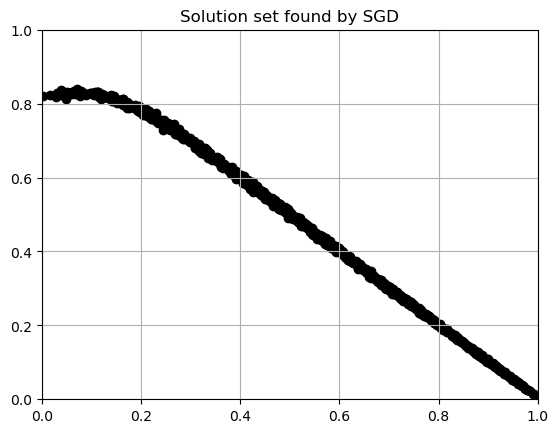

In [308]:
plt.scatter(all_solnssdg[:,0], all_solnssdg[:,1], c= 'black')
plt.xlim([0,1])
plt.ylim([0,1])
plt.grid(True)
plt.title("Solution set found by SGD")
plt.savefig('./Ex_with_no_sols/Figures/Ex3/SGD_ex3.png', dpi=180, bbox_inches='tight')
plt.show()

In [191]:
## x:
bins_list= [5, 10, 15, 20]
solns= all_solnssdg.copy()
# mask= solns[:,-1]<0.1
# solns= solns[:,:-1][mask]
x= solns[:,0]
x_min = np.min(x)
x_max = np.max(x)

## y:
y= solns[:,1]
y_min = np.min(y)
y_max = np.max(y)
# y

xsgd= x.copy()
ysgd= y.copy()

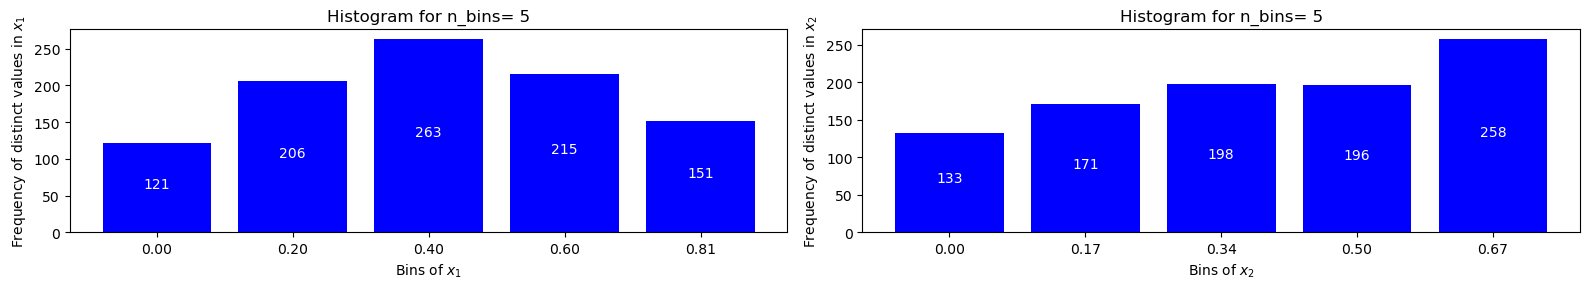

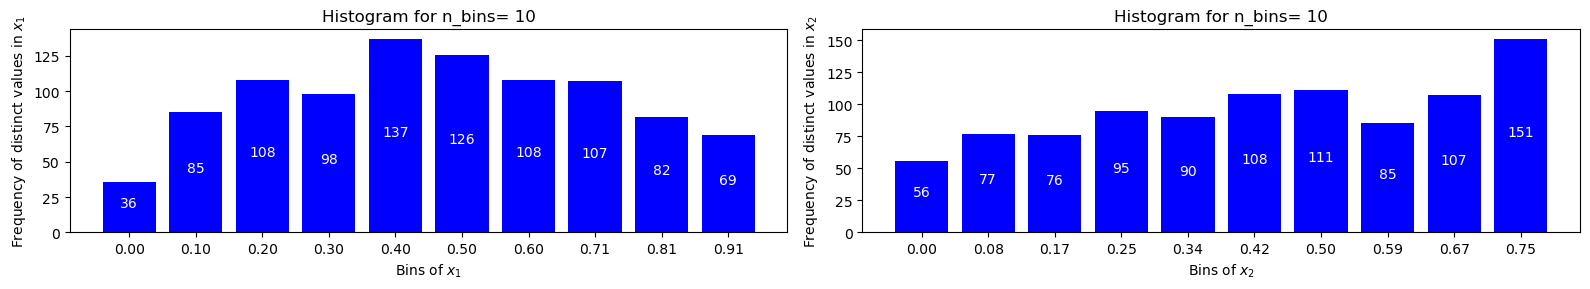

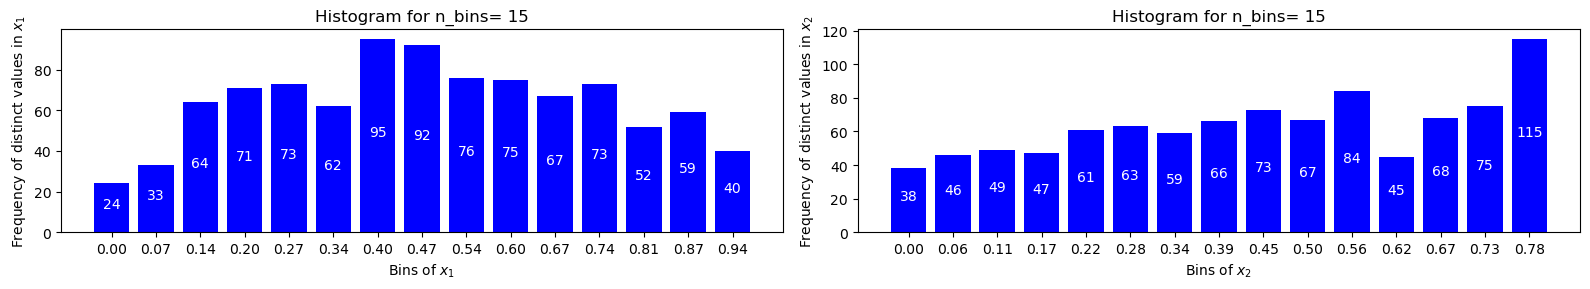

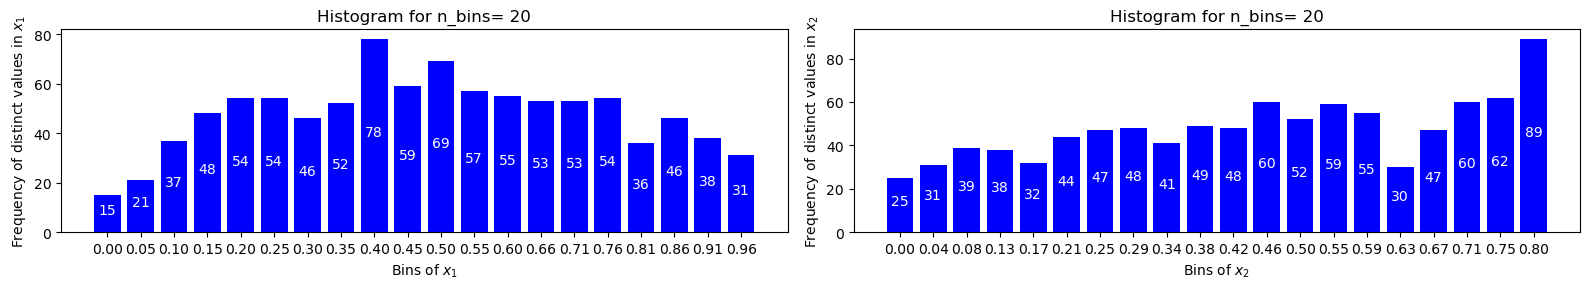

In [192]:
x_hist_sgd= []
y_hist_sgd= []
y_part_sgd= []
x_part_sgd= []
for n_bins in bins_list:
    partition_points = partition_interval(x_min, x_max, n_bins)
    x_part_sgd.append(partition_points)
#     print("Partition points:", partition_points)
    bin_counts = count_values_in_bins(x, partition_points)
    x_hist_sgd.append(bin_counts)
#     bin_counts= get_per(bin_counts)
#     print("Counts in each bin:", bin_counts)

    y_partition_points = partition_interval(y_min, y_max, n_bins)
    y_part_sgd.append(y_partition_points)
    y_bin_counts = count_values_in_bins(y, y_partition_points)
    y_hist_sgd.append(y_bin_counts)


    plt.figure(figsize=(16, 3))

    plt.subplot(1, 2, 1)
    bars = plt.bar(range(len(bin_counts)), bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(bin_counts)), ["{:.2f}".format(b) for b in partition_points[:-1]])
    plt.xlabel('Bins of $x_1$')
    plt.ylabel('Frequency of distinct values in $x_1$')
    plt.title('Histogram for n_bins= {}'.format(len(bin_counts)))
#     plt.grid(True)

    plt.subplot(1, 2, 2)
    bars = plt.bar(range(len(y_bin_counts)), y_bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(y_bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(y_bin_counts)), ["{:.2f}".format(b) for b in y_partition_points[:-1]])
    plt.xlabel('Bins of $x_2$')
    plt.ylabel('Frequency of distinct values in $x_2$')
    plt.title('Histogram for n_bins= {}'.format(len(y_bin_counts)))
#     plt.grid(True)
    plt.tight_layout()
#     plt.savefig('../SGD/solns_runs/Ex1/'+'ex1_sgd_hist'+str(n_bins)+'.png')
    plt.show()

## Uniform CDF vs. empirical CDF and KS-Test

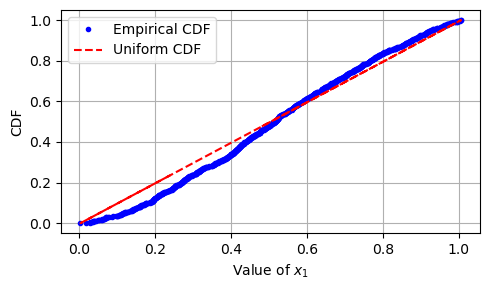

K-S Statistic: 0.08654010624364185
P-Value: 1.1006655605544414e-06
Reject the null hypothesis: The sample does not follow the uniform distribution.


In [193]:
# KS Test on x: 
a,b= np.min(xsgd), np.max(xsgd)
uniform_samples = np.random.uniform(low=a, high=b, size=len(xsgd))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

# Number of samples
n_samples = len(xsgd)

# Generate uniform values in [0,1]
#uniform_samples = np.random.uniform(low=0.0, high=1.0, size=n_samples)

# Plotting the histogram of uniform samples
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(xsgd)
ecdf_sgd_x = ECDF(xsgd) #np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_sgd_x.x, ecdf_sgd_x.y, marker='.', linestyle='none', label='Empirical CDF',c= 'blue')
# plt.plot([0.5, 1], [0.0, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples,cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples vs. Empiric')
plt.xlabel('Value of $x_1$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.savefig('../SGD/solns_runs/Ex1/ks_ex1_x1.png')
plt.show()

# Perform K-S test
ks_statistic, p_value = stats.kstest(xsgd, "uniform")#stats.kstest(ecdf.y, stats.uniform.cdf) #stats.kstest(ecdf.y, cdf_uniform)

# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.") 

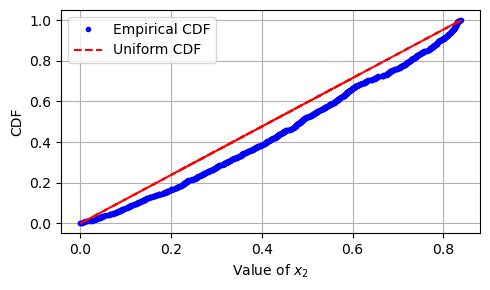

K-S Statistic: 0.16332216575173453
P-Value: 8.967048437877043e-23
Reject the null hypothesis: The sample does not follow the uniform distribution.


In [194]:
# KS Test on y: 
# Number of samples
a,b= np.min(ysgd), np.max(ysgd)
uniform_samples = np.random.uniform(low=a, high=b, size=len(ysgd))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

n_samples = len(ysgd)
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(ysgd)
ecdf_sgd_y = ECDF(ysgd) # np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_sgd_y.x, ecdf_sgd_y.y, marker='.', linestyle='none', label='Empirical CDF', c= 'blue')
# plt.plot([1-1, 1-0.5], [1-1, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples, cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples')
plt.xlabel('Value of $x_2$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.savefig('../SGD/solns_runs/Ex1/ks_ex1_x2.png')
plt.show()

# Perform K-S test
ks_statistic, p_value = stats.kstest(ysgd, "uniform")

# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.")

# KS-Overall

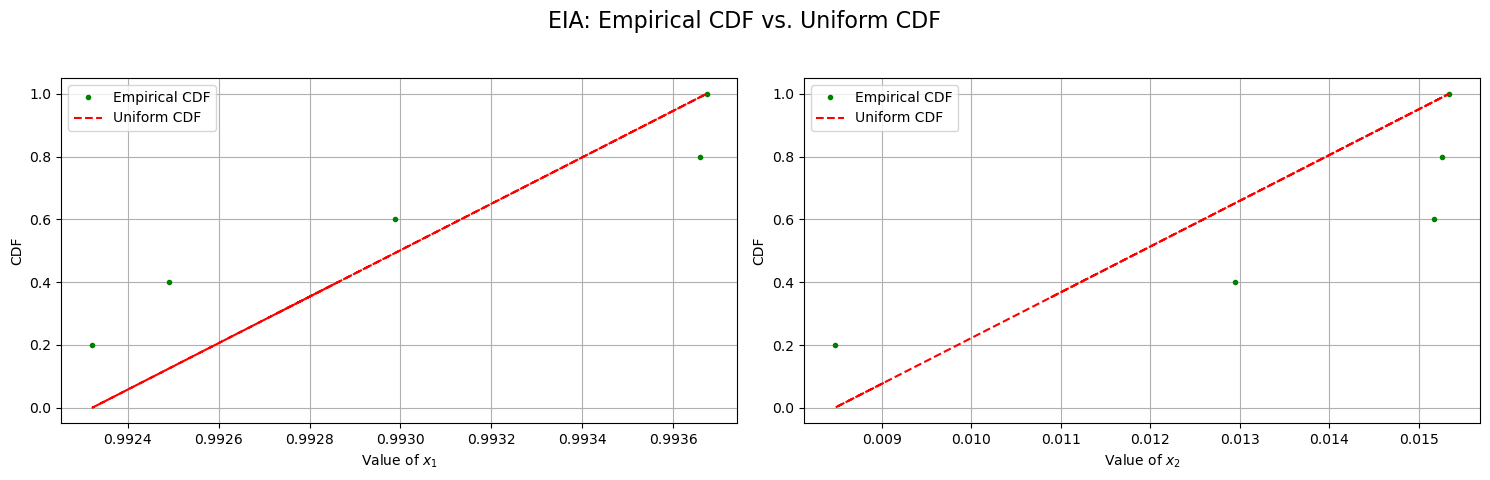

In [195]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.distributions.empirical_distribution import ECDF

# def get_cdf_of_uniform(x, a, b):
#     return (x - a) / (b - a)

plt.figure(figsize=(15, 5))  # Adjust the figure size for better readability

width = 0.15  # Width of the bars

# First subplot for x_hist_gsm and x_hist_eia
plt.subplot(1, 2, 1)

a, b= np.min(xeia), np.max(xeia)
uniform_samples = np.random.uniform(low=a, high=b, size=1000)
cdf_uniform = [get_cdf_of_uniform(i, a=a, b=b) for i in uniform_samples]

ecdf_sgd_x = ECDF(xeia)
plt.plot(ecdf_sgd_x.x, ecdf_sgd_x.y, marker='.', linestyle='none', label='Empirical CDF', c='green')
plt.plot(uniform_samples, cdf_uniform, 'r--', label='Uniform CDF')
plt.xlabel('Value of $x_1$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)

# Second subplot for y_hist_gsm and y_hist_eia
plt.subplot(1, 2, 2)

a, b = np.min(yeia), np.max(yeia)
uniform_samples = np.random.uniform(low=a, high=b, size=1000)
cdf_uniform = [get_cdf_of_uniform(i, a=a, b=b) for i in uniform_samples]

ecdf_sgd_y = ECDF(yeia)
plt.plot(ecdf_sgd_y.x, ecdf_sgd_y.y, marker='.', linestyle='none', label='Empirical CDF', c='green')
plt.plot(uniform_samples, cdf_uniform, 'r--', label='Uniform CDF')
plt.xlabel('Value of $x_2$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)

# Caption for the entire group of subplots
plt.suptitle('EIA: Empirical CDF vs. Uniform CDF', fontsize=16)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to make room for the suptitle
plt.savefig('../EIA/solns_runs_no_sols/Ex3/ks_ex3.png')
plt.show()

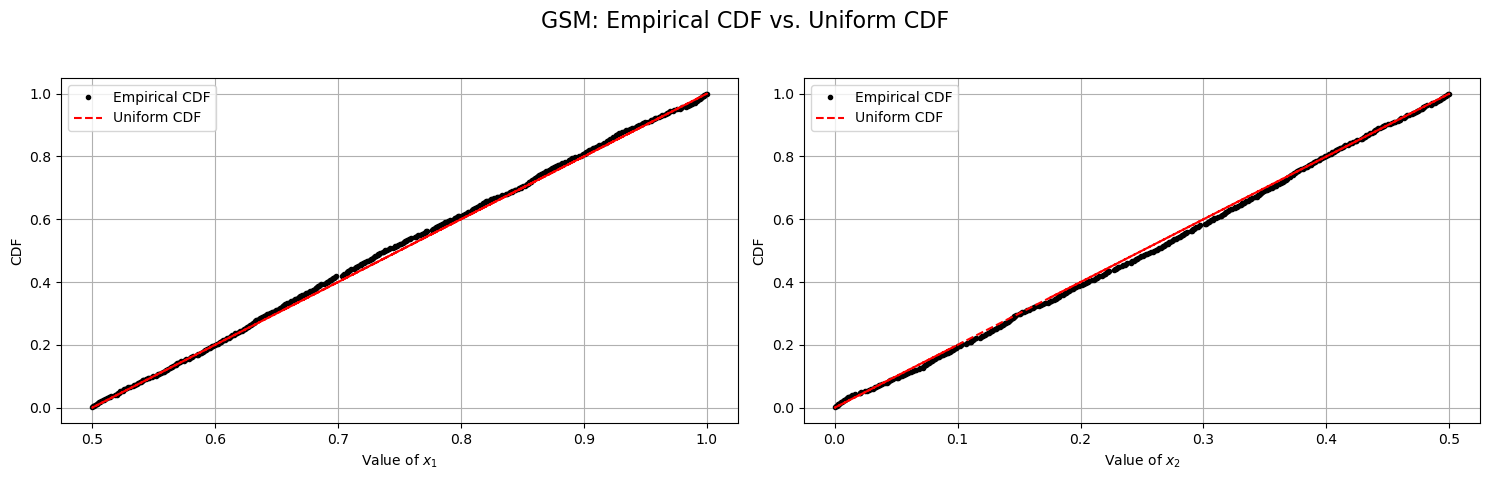

In [196]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.distributions.empirical_distribution import ECDF

# def get_cdf_of_uniform(x, a, b):
#     return (x - a) / (b - a)

plt.figure(figsize=(15, 5))  # Adjust the figure size for better readability

width = 0.15  # Width of the bars

# First subplot for x_hist_gsm and x_hist_eia
plt.subplot(1, 2, 1)

a, b= np.min(xgsm), np.max(xgsm)
uniform_samples = np.random.uniform(low=a, high=b, size=1000)
cdf_uniform = [get_cdf_of_uniform(i, a=a, b=b) for i in uniform_samples]

ecdf_sgd_x = ECDF(xgsm)
plt.plot(ecdf_sgd_x.x, ecdf_sgd_x.y, marker='.', linestyle='none', label='Empirical CDF', c='black')
plt.plot(uniform_samples, cdf_uniform, 'r--', label='Uniform CDF')
plt.xlabel('Value of $x_1$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)

# Second subplot for y_hist_gsm and y_hist_eia
plt.subplot(1, 2, 2)

a, b = np.min(ygsm), np.max(ygsm)
uniform_samples = np.random.uniform(low=a, high=b, size=1000)
cdf_uniform = [get_cdf_of_uniform(i, a=a, b=b) for i in uniform_samples]

ecdf_sgd_y = ECDF(ygsm)
plt.plot(ecdf_sgd_y.x, ecdf_sgd_y.y, marker='.', linestyle='none', label='Empirical CDF', c='black')
plt.plot(uniform_samples, cdf_uniform, 'r--', label='Uniform CDF')
plt.xlabel('Value of $x_2$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)

# Caption for the entire group of subplots
plt.suptitle('GSM: Empirical CDF vs. Uniform CDF', fontsize=16)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to make room for the suptitle
plt.savefig('../GSM/solns_runs_no_sols/Ex3/ks_ex3.png')
plt.show()

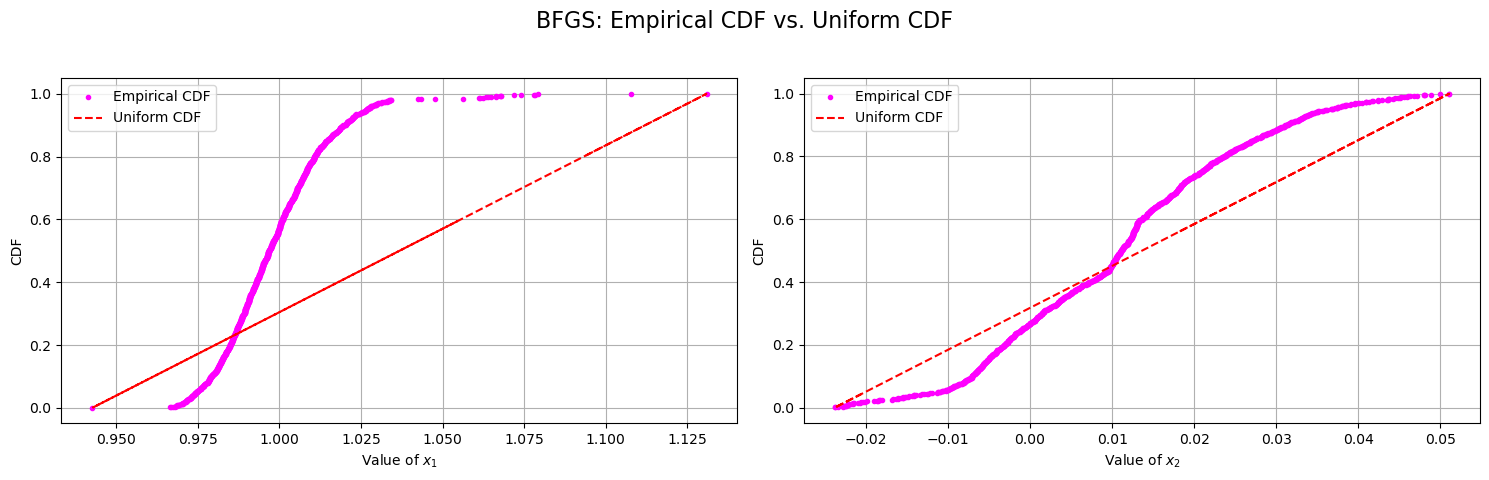

In [197]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.distributions.empirical_distribution import ECDF

# def get_cdf_of_uniform(x, a, b):
#     return (x - a) / (b - a)

plt.figure(figsize=(15, 5))  # Adjust the figure size for better readability

width = 0.15  # Width of the bars

# First subplot for x_hist_gsm and x_hist_eia
plt.subplot(1, 2, 1)

a, b= np.min(xbfgs), np.max(xbfgs)
uniform_samples = np.random.uniform(low=a, high=b, size=1000)
cdf_uniform = [get_cdf_of_uniform(i, a=a, b=b) for i in uniform_samples]

ecdf_sgd_x = ECDF(xbfgs)
plt.plot(ecdf_sgd_x.x, ecdf_sgd_x.y, marker='.', linestyle='none', label='Empirical CDF', c='magenta')
plt.plot(uniform_samples, cdf_uniform, 'r--', label='Uniform CDF')
plt.xlabel('Value of $x_1$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)

# Second subplot for y_hist_gsm and y_hist_eia
plt.subplot(1, 2, 2)

a, b = np.min(ybfgs), np.max(ybfgs)
uniform_samples = np.random.uniform(low=a, high=b, size=1000)
cdf_uniform = [get_cdf_of_uniform(i, a=a, b=b) for i in uniform_samples]

ecdf_sgd_y = ECDF(ybfgs)
plt.plot(ecdf_sgd_y.x, ecdf_sgd_y.y, marker='.', linestyle='none', label='Empirical CDF', c='magenta')
plt.plot(uniform_samples, cdf_uniform, 'r--', label='Uniform CDF')
plt.xlabel('Value of $x_2$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)

# Caption for the entire group of subplots
plt.suptitle('BFGS: Empirical CDF vs. Uniform CDF', fontsize=16)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to make room for the suptitle
plt.savefig('../Merit/solns_runs_no_sols/Ex3/ks_ex3.png')
plt.show()

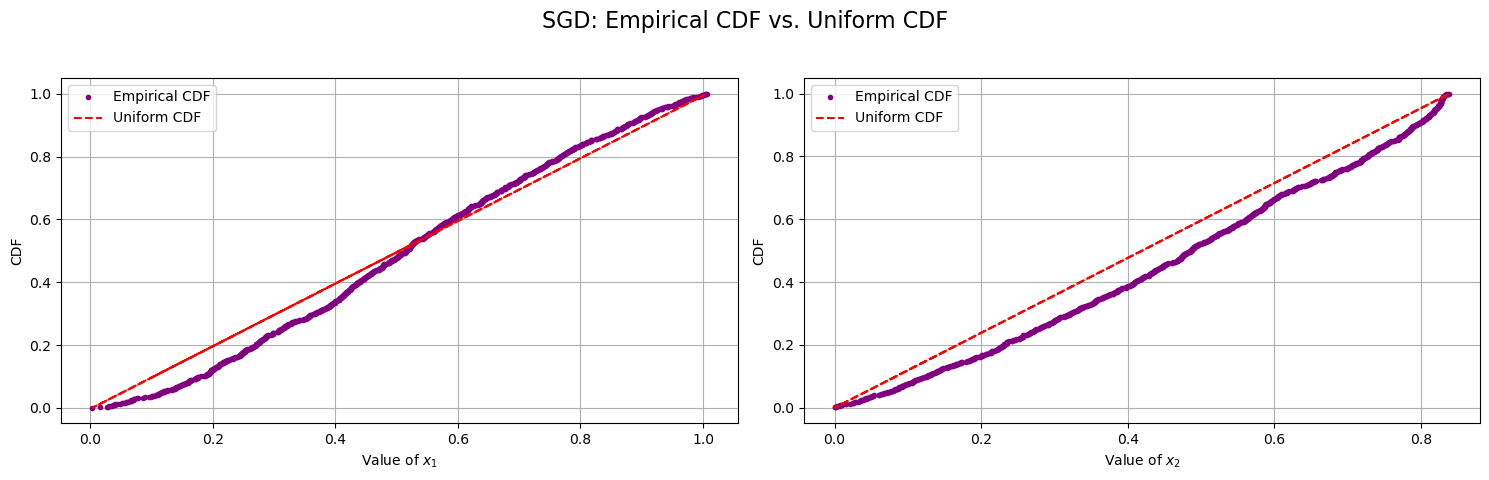

In [199]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.distributions.empirical_distribution import ECDF

# def get_cdf_of_uniform(x, a, b):
#     return (x - a) / (b - a)

plt.figure(figsize=(15, 5))  # Adjust the figure size for better readability

width = 0.15  # Width of the bars

# First subplot for x_hist_gsm and x_hist_eia
plt.subplot(1, 2, 1)

a, b= np.min(xsgd), np.max(xsgd)
uniform_samples = np.random.uniform(low=a, high=b, size=1000)
cdf_uniform = [get_cdf_of_uniform(i, a=a, b=b) for i in uniform_samples]

ecdf_sgd_x = ECDF(xsgd)
plt.plot(ecdf_sgd_x.x, ecdf_sgd_x.y, marker='.', linestyle='none', label='Empirical CDF', c='purple')
plt.plot(uniform_samples, cdf_uniform, 'r--', label='Uniform CDF')
plt.xlabel('Value of $x_1$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)

# Second subplot for y_hist_gsm and y_hist_eia
plt.subplot(1, 2, 2)

a, b = np.min(ysgd), np.max(ysgd)
uniform_samples = np.random.uniform(low=a, high=b, size=1000)
cdf_uniform = [get_cdf_of_uniform(i, a=a, b=b) for i in uniform_samples]

ecdf_sgd_y = ECDF(ysgd)
plt.plot(ecdf_sgd_y.x, ecdf_sgd_y.y, marker='.', linestyle='none', label='Empirical CDF', c='purple')
plt.plot(uniform_samples, cdf_uniform, 'r--', label='Uniform CDF')
plt.xlabel('Value of $x_2$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)

# Caption for the entire group of subplots
plt.suptitle('SGD: Empirical CDF vs. Uniform CDF', fontsize=16)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to make room for the suptitle
plt.savefig('../SGD/solns_runs_no_sols/Ex3/ks_ex3.png')
plt.show()

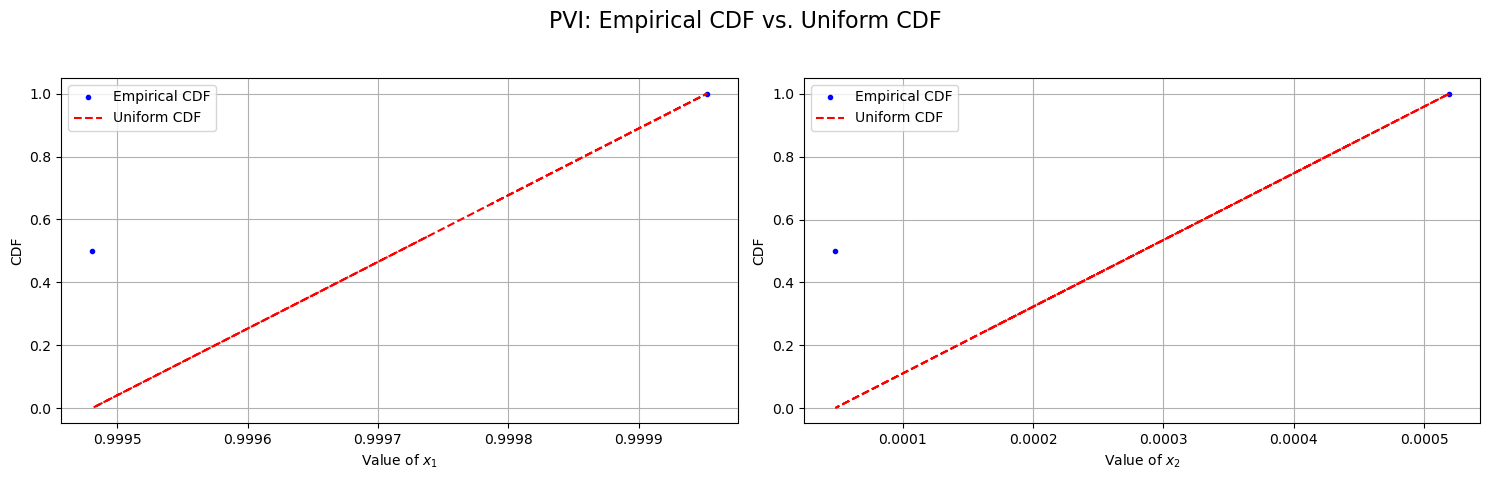

In [307]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.distributions.empirical_distribution import ECDF

# def get_cdf_of_uniform(x, a, b):
#     return (x - a) / (b - a)

plt.figure(figsize=(15, 5))  # Adjust the figure size for better readability

width = 0.15  # Width of the bars

# First subplot for x_hist_gsm and x_hist_eia
plt.subplot(1, 2, 1)

a, b= np.min(xpvi), np.max(xpvi)
uniform_samples = np.random.uniform(low=a, high=b, size=1000)
cdf_uniform = [get_cdf_of_uniform(i, a=a, b=b) for i in uniform_samples]

ecdf_sgd_x = ECDF(xpvi)
plt.plot(ecdf_sgd_x.x, ecdf_sgd_x.y, marker='.', linestyle='none', label='Empirical CDF', c='blue')
plt.plot(uniform_samples, cdf_uniform, 'r--', label='Uniform CDF')
plt.xlabel('Value of $x_1$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)

# Second subplot for y_hist_gsm and y_hist_eia
plt.subplot(1, 2, 2)

a, b = np.min(ypvi), np.max(ypvi)
uniform_samples = np.random.uniform(low=a, high=b, size=1000)
cdf_uniform = [get_cdf_of_uniform(i, a=a, b=b) for i in uniform_samples]

ecdf_sgd_y = ECDF(ypvi)
plt.plot(ecdf_sgd_y.x, ecdf_sgd_y.y, marker='.', linestyle='none', label='Empirical CDF', c='blue')
plt.plot(uniform_samples, cdf_uniform, 'r--', label='Uniform CDF')
plt.xlabel('Value of $x_2$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)

# Caption for the entire group of subplots
plt.suptitle('PVI: Empirical CDF vs. Uniform CDF', fontsize=16)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to make room for the suptitle
plt.savefig('../PVI/solns_runs_no_sols/Ex3/ks_ex3.png')
plt.show()

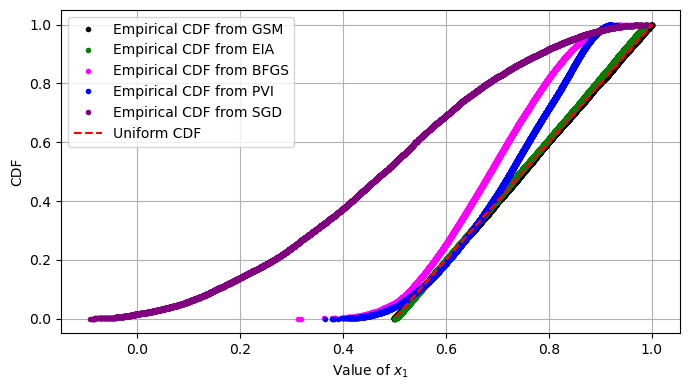

********START********
******KS-Test for GSM *********
K-S Statistic: 0.49935748695203075
P-Value: 0.0
Reject the null hypothesis: The sample does not follow the uniform distribution.
********END********
********START********
******KS-Test for EIA *********
K-S Statistic: 0.5012650177512686
P-Value: 0.0
Reject the null hypothesis: The sample does not follow the uniform distribution.
********END********
********START********
******KS-Test for BFGS *********
K-S Statistic: 0.4488612647838096
P-Value: 0.0
Reject the null hypothesis: The sample does not follow the uniform distribution.
********END********
********START********
******KS-Test for PVI *********
K-S Statistic: 0.46170731860116315
P-Value: 0.0
Reject the null hypothesis: The sample does not follow the uniform distribution.
********END********
********START********
******KS-Test for SGD *********
K-S Statistic: 0.12384038942696152
P-Value: 2.490345833856069e-183
Reject the null hypothesis: The sample does not follow the uniform d

In [388]:
# KS Test on x: 
a,b= 0.5,1.0
uniform_samples = np.random.uniform(low=a, high=b, size=len(x))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

# Number of samples
n_samples = len(x)

# Generate uniform values in [0,1]
#uniform_samples = np.random.uniform(low=0.0, high=1.0, size=n_samples)

# Plotting the histogram of uniform samples
plt.figure(figsize=(7, 4))

# CDF Plot
sorted_samples = np.sort(x)
ecdfgsm= ECDF(xgsm) #np.arange(1, n_samples+1) / n_samples
ecdfeia= ECDF(xeia) #np.arange(1, n_samples+1) / n_samples
ecdfbfgs= ECDF(xbfgs) #np.arange(1, n_samples+1) / n_samples
ecdfpvi= ECDF(xpvi) #np.arange(1, n_samples+1) / n_samples
ecdfsgd= ECDF(xsgd) #np.arange(1, n_samples+1) / n_samples

plt.plot(ecdfgsm.x, ecdfgsm.y, marker='.', linestyle='none', label='Empirical CDF from GSM',c= 'black')
plt.plot(ecdfeia.x, ecdfeia.y, marker='.', linestyle='none', label='Empirical CDF from EIA',c= 'green')
plt.plot(ecdfbfgs.x, ecdfbfgs.y, marker='.', linestyle='none', label='Empirical CDF from BFGS',c= 'magenta')

plt.plot(ecdfpvi.x, ecdfpvi.y, marker='.', linestyle='none', label='Empirical CDF from PVI',c= 'blue')
plt.plot(ecdfsgd.x, ecdfsgd.y, marker='.', linestyle='none', label='Empirical CDF from SGD',c= 'purple')
# plt.plot([0.5, 1], [0.0, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples,cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples vs. Empiricc')
plt.xlabel('Value of $x_1$')
plt.ylabel('CDF')
# plt.xlim([0, 1])
# plt.ylim([0, 1])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../KS-Plots/Ex1/all_ks_ex1_x1.png')
plt.show()

KS_Test(xgsm, algo= "GSM")
KS_Test(xeia, algo= "EIA")
KS_Test(xbfgs, algo= "BFGS")
KS_Test(xpvi, algo= "PVI")
KS_Test(xsgd, algo= "SGD")

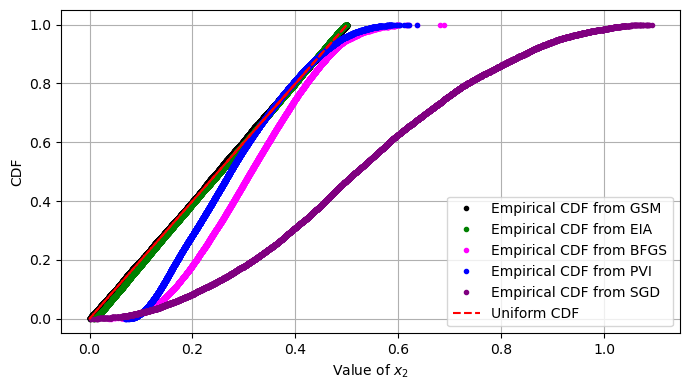

********START********
******KS-Test for GSM *********
K-S Statistic: 0.49935748695203075
P-Value: 0.0
Reject the null hypothesis: The sample does not follow the uniform distribution.
********END********
********START********
******KS-Test for EIA *********
K-S Statistic: 0.5012650177512686
P-Value: 0.0
Reject the null hypothesis: The sample does not follow the uniform distribution.
********END********
********START********
******KS-Test for BFGS *********
K-S Statistic: 0.4488612647838096
P-Value: 0.0
Reject the null hypothesis: The sample does not follow the uniform distribution.
********END********
********START********
******KS-Test for PVI *********
K-S Statistic: 0.4617073186011631
P-Value: 0.0
Reject the null hypothesis: The sample does not follow the uniform distribution.
********END********
********START********
******KS-Test for SGD *********
K-S Statistic: 0.12384038942696149
P-Value: 2.4903458338565405e-183
Reject the null hypothesis: The sample does not follow the uniform d

In [389]:
# KS Test on y: 
# Number of samples
a,b= 0.0,0.5
uniform_samples = np.random.uniform(low=a, high=b, size=len(x))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

# Number of samples
n_samples = len(x)

# Generate uniform values in [0,1]
#uniform_samples = np.random.uniform(low=0.0, high=1.0, size=n_samples)

# Plotting the histogram of uniform samples
plt.figure(figsize=(7, 4))

# CDF Plot
sorted_samples = np.sort(y)
ecdfgsm= ECDF(ygsm) #np.arange(1, n_samples+1) / n_samples
ecdfeia= ECDF(yeia) #np.arange(1, n_samples+1) / n_samples
ecdfbfgs= ECDF(ybfgs) #np.arange(1, n_samples+1) / n_samples
ecdfpvi= ECDF(ypvi) #np.arange(1, n_samples+1) / n_samples
ecdfsgd= ECDF(ysgd)

plt.plot(ecdfgsm.x, ecdfgsm.y, marker='.', linestyle='none', label='Empirical CDF from GSM',c= 'black')
plt.plot(ecdfeia.x, ecdfeia.y, marker='.', linestyle='none', label='Empirical CDF from EIA',c= 'green')
plt.plot(ecdfbfgs.x, ecdfbfgs.y, marker='.', linestyle='none', label='Empirical CDF from BFGS',c= 'magenta')

plt.plot(ecdfpvi.x, ecdfpvi.y, marker='.', linestyle='none', label='Empirical CDF from PVI',c= 'blue')
plt.plot(ecdfsgd.x, ecdfsgd.y, marker='.', linestyle='none', label='Empirical CDF from SGD',c= 'purple')
# plt.plot([0.5, 1], [0.0, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples,cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples vs. Empiricc')
plt.xlabel('Value of $x_2$')
plt.ylabel('CDF')
# plt.xlim([0, 1])
# plt.ylim([0, 1])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../KS-Plots/Ex1/all_ks_ex1_x2.png')
plt.show()


    
KS_Test(ygsm, algo= "GSM")
KS_Test(yeia, algo= "EIA")
KS_Test(ybfgs, algo= "BFGS")
KS_Test(ypvi, algo= "PVI")
KS_Test(ysgd, algo= "SGD")

In [390]:
ecdfsgd.x, ecdfsgd.y

(array([      -inf, 0.00281751, 0.00608139, ..., 1.08615852, 1.08741312,
        1.09204842]),
 array([0.00000000e+00, 7.30940721e-05, 1.46188144e-04, ...,
        9.99853812e-01, 9.99926906e-01, 1.00000000e+00]))

In [391]:
# pdppvi, hdgpvi
pdpeia

[34.599999999999994,
 35.8,
 37.4,
 38.275,
 39.46,
 40.300000000000004,
 40.042857142857144,
 40.2875,
 40.0,
 40.400000000000006,
 40.490909090909085,
 40.49166666666667,
 40.792307692307695,
 40.80714285714286,
 41.04]

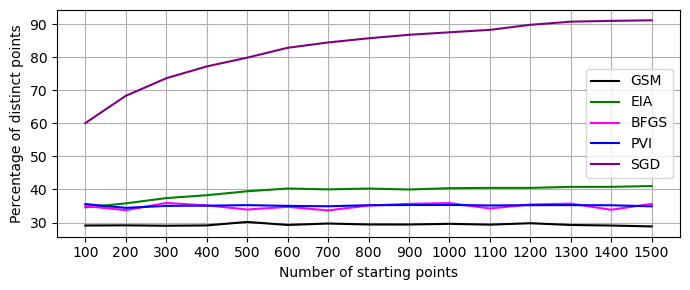

In [392]:
plt.figure(figsize=(7, 3))
plt.plot(nubmer_points_list, pdpgsm,label='GSM',c= 'black')
plt.plot(nubmer_points_list, pdpeia, label='EIA',c= 'green')
plt.plot(nubmer_points_list, pdpbfgs, label='BFGS',c= 'magenta')

plt.plot(nubmer_points_list, pdppvi, label='PVI',c= 'blue')
plt.plot(nubmer_points_list, pdpsgd, label='SGD',c= 'purple')
# plt.plot([0.5, 1], [0.0, 1], 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples vs. Empiricc')
plt.xlabel('Number of starting points')
plt.ylabel('Percentage of distinct points')
plt.xticks(nubmer_points_list)
# plt.ylim([0, 1])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../KS-Plots/Ex1/npoints_pdp.png')
plt.show()

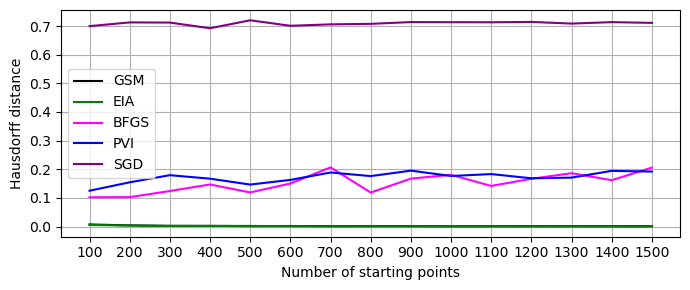

In [393]:
plt.figure(figsize=(7, 3))
plt.plot(nubmer_points_list, hdgsm,label='GSM',c= 'black')
plt.plot(nubmer_points_list, hdeia, label='EIA',c= 'green')
plt.plot(nubmer_points_list, hdbfgs, label='BFGS',c= 'magenta')

plt.plot(nubmer_points_list, hdgpvi, label='PVI',c= 'blue')
plt.plot(nubmer_points_list, hdsgd, label='SGD',c= 'purple')
# plt.plot([0.5, 1], [0.0, 1], 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples vs. Empiricc')
plt.xlabel('Number of starting points')
plt.ylabel('Hausdorff distance')
plt.xticks(nubmer_points_list)
# plt.ylim([0, 1])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../KS-Plots/Ex1/npoints_hd.png')
plt.show()

### Hists

In [394]:
# x_hist_sgd= []
# y_hist_sgd= []
# y_part_sgd= []
# x_part_sgd= []
# hdgpvi

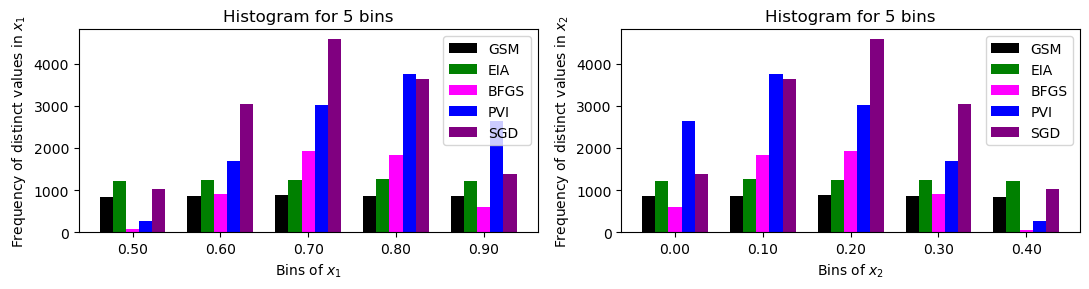

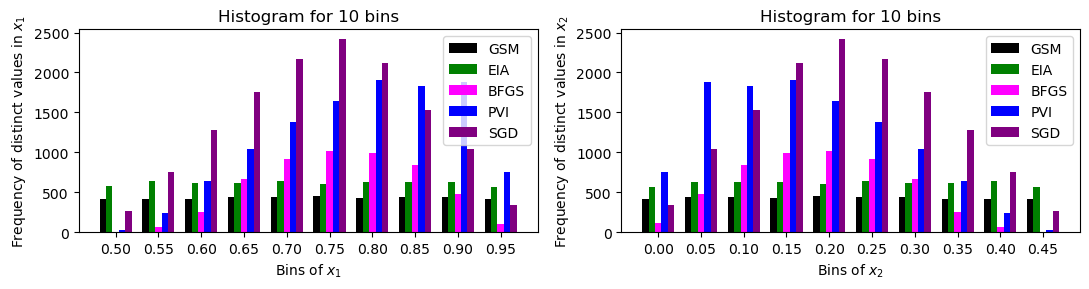

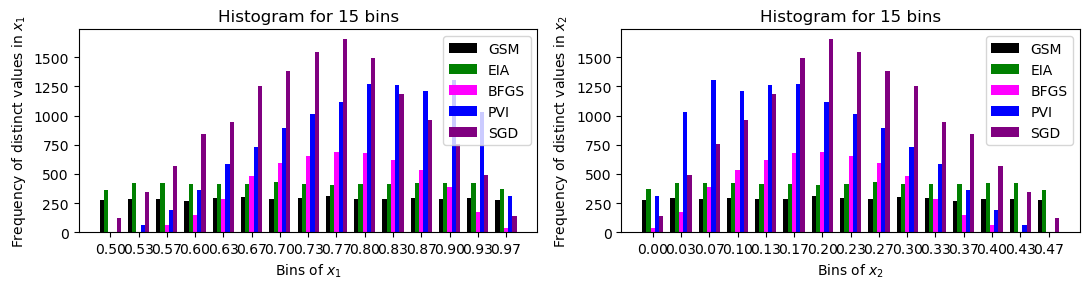

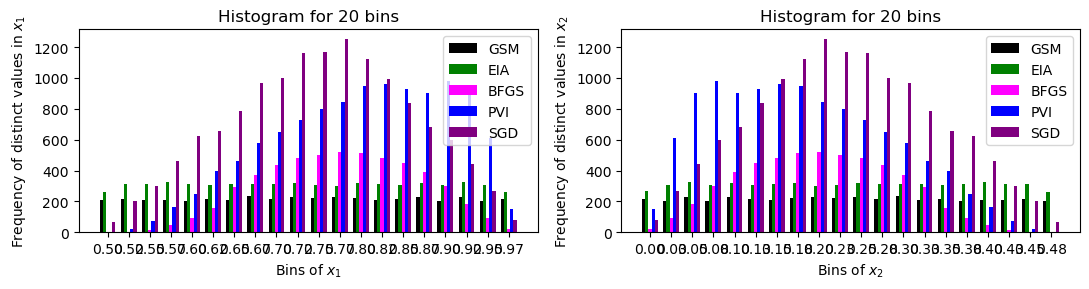

In [395]:
import matplotlib.pyplot as plt
import numpy as np

for n_bins in range(len(bins_list)):
    plt.figure(figsize=(11, 3))  # Increase the figure height for better readability
    
    width = 0.15  # Width of the bars
    
    # First subplot for x_hist_gsm and x_hist_eia
    plt.subplot(1, 2, 1)
    
    x = np.arange(len(x_hist_gsm[n_bins]))  # X locations for the groups
    
    barsgsm = plt.bar(x - 2*width, list(x_hist_gsm[n_bins].values()), width, align='center', color='black', label='GSM')
    barseia = plt.bar(x - width, list(x_hist_eia[n_bins].values()), width, align='center', color='green', label='EIA')
    barsbfgs = plt.bar(x, list(x_hist_bfgs[n_bins].values()), width, align='center', color='magenta', label='BFGS')
    barspvi = plt.bar(x + width, list(x_hist_pvi[n_bins].values()), width, align='center', color='blue', label='PVI')
    barssgd = plt.bar(x + 2*width, list(x_hist_sgd[n_bins].values()), width, align='center', color='purple', label='SGD')
    
    # Customize plot
    plt.xticks(x, ["{:.2f}".format(b) for b in x_part_gsm[n_bins][:-1]])
    plt.xlabel('Bins of $x_1$')
    plt.ylabel('Frequency of distinct values in $x_1$')
    plt.title('Histogram for {} bins'.format(len(x_hist_gsm[n_bins])))
    plt.legend(loc='upper right')
#     plt.grid(True)
    
    # Second subplot for y_hist_gsm and y_hist_eia
    plt.subplot(1, 2, 2)
    
    y = np.arange(len(y_hist_gsm[n_bins]))  # X locations for the groups
    
    barsgsm = plt.bar(y - 2*width, list(y_hist_gsm[n_bins].values()), width, align='center', color='black', label='GSM')
    barseia = plt.bar(y - width, list(y_hist_eia[n_bins].values()), width, align='center', color='green', label='EIA')
    barsbfgs = plt.bar(y, list(y_hist_bfgs[n_bins].values()), width, align='center', color='magenta', label='BFGS')
    barspvi = plt.bar(y + width, list(y_hist_pvi[n_bins].values()), width, align='center', color='blue', label='PVI')
    barssgd = plt.bar(y + 2*width, list(y_hist_sgd[n_bins].values()), width, align='center', color='purple', label='SGD')

    # Customize plot
    plt.xticks(y, ["{:.2f}".format(b) for b in y_part_gsm[n_bins][:-1]])
    plt.xlabel('Bins of $x_2$')
    plt.ylabel('Frequency of distinct values in $x_2$')
    plt.title('Histogram for {} bins'.format(len(y_hist_gsm[n_bins])))
    plt.legend(loc='upper right')
#     plt.grid(True)
    
    plt.tight_layout()
    # Uncomment the next line to save the plot
    plt.savefig('../KS-Plots/Ex1/'+'ex1_hist_bin'+str(bins_list[n_bins])+'.png')
    plt.show()


# END

In [118]:
len(xeia),len(xsgd),len(xgsm),len(xbfgs),len(xpvi)

(3649, 616, 1858, 2183, 11362)

In [22]:
import numpy as np
import matplotlib.pyplot as plt
xx= np.array([[4.876788031741630114e-01,8.731705232086508506e-01,1.267862502848458028e-01
5.713379018475522875e-01,8.211695223630959273e-01,1.787680325387112079e-01
7.432062677374823290e-01,6.695855406517553510e-01,3.300190263229109133e-01
7.525440641697332955e-01,6.575952565633526037e-01,3.424714335868479509e-01
7.693861779682403812e-01,5.397585698374345320e-01,4.615385499481162723e-01
6.808063682992651078e-01,7.327065365690552667e-01,2.652645108379573236e-01
3.890202992626343725e-01,9.213987638667964220e-01,8.014081561154662303e-02
6.879676918398307528e-01,7.270236108449890100e-01,2.716955213697935800e-01
5.179173702801608270e-01,8.562047708106533817e-01,1.451988357658677842e-01
5.801168527611996195e-01,8.129744180427955769e-01,1.862731456015256359e-01
5.899320223135769981e-01,8.087310607885094260e-01,1.899615976276411988e-01
6.973673161445000934e-01,7.168346599067052516e-01,2.804670038004160038e-01
6.829971047197569423e-01,7.321150484960120552e-01,2.667862253106402237e-01
5.162737635070069331e-01,8.577589730831514103e-01,1.433634824275247244e-01
6.675423457826014095e-01,7.466091243286074874e-01,2.539731417545791903e-01
3.972750710533475282e-01,9.165547053630562768e-01,8.215029264439444034e-02
4.439242583006045018e-01,8.963934522774953395e-01,1.059487574327409032e-01
7.626544398952591619e-01,5.275919305603002929e-01,4.700189457286036987e-01
5.063038922224502025e-01,8.601999749979987175e-01,1.396297565443522792e-01
7.791308837356667460e-01,6.224022773623407723e-01,3.786125468969753216e-01
5.600006057448457808e-01,8.306667027633288791e-01,1.687750013009094996e-01
7.759080375555883480e-01,5.521072017272156129e-01,4.507871554591613705e-01
4.000168731068901584e-01,9.165201652328647253e-01,7.934040987061752315e-02
5.352867742757047020e-01,8.447231539458214256e-01,1.511072741269494646e-01
1.949097944782866576e-01,9.799834611235737070e-01,2.017832038448807985e-02
7.798374062198465406e-01,6.285530537520279681e-01,3.687424529362918202e-01
6.015734699760859616e-01,7.959611035018980818e-01,2.026181787823756464e-01
4.529159947625279736e-01,8.932803156030653113e-01,1.046054015122607206e-01
5.029058147246832089e-01,8.651334086070641138e-01,1.379106382278144638e-01
6.007019975049177063e-01,7.961814561431719284e-01,2.029409291232222579e-01
6.147207744030223076e-01,7.864943576146165016e-01,2.160064995260373433e-01
3.958234311440881337e-01,9.166050458982046845e-01,8.175090521487426987e-02
7.841115579497222043e-01,6.236162928747456258e-01,3.737111511746868953e-01
6.753903934230331974e-01,7.331823578538885222e-01,2.658811462116690283e-01
7.746905801368795252e-01,5.459860970989347528e-01,4.572263440062130924e-01
3.416420480264372728e-01,9.398863310062719467e-01,5.507709642757552260e-02
7.564195659414090223e-01,6.563859139471364124e-01,3.390943782006532459e-01
5.860489506041446223e-02,9.979943937316851921e-01,-9.365967602459335239e-04
5.224439520587971231e-01,8.513334771904552678e-01,1.437068973996488142e-01
7.517434583228828071e-01,6.567140959754995677e-01,3.469282579851677983e-01
7.697368352686699833e-01,5.370987756161577087e-01,4.668424715644465817e-01
7.397087817091315687e-01,6.766161202759191085e-01,3.262936756772610858e-01
3.943564409120359215e-01,9.212194142231429073e-01,7.837285938205884595e-02
7.526173954031322166e-01,6.562583294966504166e-01,3.476357805358254449e-01
1.037267780919681470e-01,9.940339183010976631e-01,3.666308356833014592e-03
3.910314359574098564e-01,9.224645550088670376e-01,7.976914099284071469e-02
7.632050071914759926e-01,6.442525780379686484e-01,3.504085843391535615e-01
7.504809288728744310e-01,5.122514882422457561e-01,4.892903986011677420e-01
7.824559842658371789e-01,6.176986554881633840e-01,3.855490982711986536e-01
2.561737039373039870e-01,9.653303099882261096e-01,3.725650349256104388e-02
7.708812089994423467e-01,6.299518432517513533e-01,3.686264807840400337e-01
5.588286624145003545e-01,8.299171968820246992e-01,1.640484637007728619e-01
7.403240900678569325e-01,6.740849267327200245e-01,3.202472804399243422e-01
4.600400215741567433e-01,8.895269261268387018e-01,1.053887959496826454e-01
6.866609158227341414e-01,7.217478080600359114e-01,2.761460662383660170e-01
5.346164440258208694e-01,8.438963732853821398e-01,1.502066432704187715e-01
7.955790751330954480e-01,5.857706611270194763e-01,4.101693240784234362e-01
6.480209212960904575e-01,7.657223873520483393e-01,2.333901589820479572e-01
7.706110867085652627e-01,5.538574956904798174e-01,4.470165270246945211e-01
1.526730575416785085e-01,9.887386729039469024e-01,5.471139320697981923e-03
7.739140756329707660e-01,5.429056644000256338e-01,4.527943342421485440e-01
3.718832176788127164e-01,9.256362158370868842e-01,7.335603265144774454e-02
7.681211888184542591e-01,6.372573399792751392e-01,3.572042570513628279e-01
3.342010250939398408e-01,9.400093791879950977e-01,6.033301595833251429e-02
2.168613095208677122e-01,9.746346048315744914e-01,2.604216097766065552e-02
7.629970677445159222e-01,5.195814689946921527e-01,4.759522576117372061e-01
7.710004350428615316e-01,5.278188051467289643e-01,4.723752351482500833e-01
6.515166736253238389e-01,7.629342930819988933e-01,2.397927457814873486e-01
7.679290920117485264e-01,6.452699048938494997e-01,3.509476865446138349e-01
7.852512613468130009e-01,6.224381897250292894e-01,3.716241218432276838e-01
4.499793946805987765e-01,8.920258729354386684e-01,1.009261809043102698e-01
4.510809888834321213e-01,8.927584848279813690e-01,1.124727925455725197e-01
6.634268425935661018e-01,7.463059038089340236e-01,2.587956582296622177e-01
8.709240979486596035e-02,9.968037754802758776e-01,5.128958986041487478e-04
5.419520241038349173e-01,8.360339936680772910e-01,1.612476736350310080e-01
5.507646722275417739e-01,8.312954745817191515e-01,1.728639784508972932e-01
4.524681173152076408e-01,8.878111678791749117e-01,1.116122836888968628e-01
8.044192335569204655e-01,5.947128579751066457e-01,4.019569992529031799e-01
6.196156962250680689e-01,7.876579791088267335e-01,2.173121271578014602e-01
7.800438427082240223e-01,5.495352101192186867e-01,4.545811446182844717e-01
5.313813916465615073e-01,8.510746683962615577e-01,1.514712485889927462e-01
5.115751202489866589e-01,8.573055794916178973e-01,1.478035335495709868e-01
6.279929826618285693e-01,7.748743723367248482e-01,2.192393807480337298e-01
7.590731366679970282e-01,5.329835035383028163e-01,4.650421709856767949e-01
3.415720948880119900e-01,9.425194308654319952e-01,5.664238535174070943e-02
6.461285860128637148e-01,7.674819288688506935e-01,2.280173604773900742e-01
7.911069959515958372e-01,6.039763124672394845e-01,3.998518136558498748e-01
7.608854915469319691e-01,6.499833448366447719e-01,3.556888985679682591e-01
4.106267253008150098e-01,9.111979442212838620e-01,9.444927076371278929e-02
5.103205144272910943e-01,8.639979034230566013e-01,1.336017830272618889e-01
7.596105209410598524e-01,5.182569828972938275e-01,4.876388435384667597e-01
2.444385718104819319e-02,1.000416499079493038e+00,4.993883607551929948e-03
7.235962565010294334e-01,6.909448745384295654e-01,3.007486877926354163e-01
7.857596429088334888e-01,5.882651786095136615e-01,4.120696147893073702e-01
7.249872617848719392e-01,6.909212990054300896e-01,3.012295744277891929e-01
7.763143431697988595e-01,5.692244479575070404e-01,4.298074063075011386e-01
6.421351175396345923e-01,7.651596948649634911e-01,2.406776611284652256e-01
7.824993158373046986e-01,5.706802140389051203e-01,4.236684853426690989e-01
5.145786212405226712e-01,8.524400838623402699e-01,1.491994968922412124e-01
6.085487788915635576e-01,7.869357478693834729e-01,2.141072149698314275e-01
5.561805491648806887e-01,8.345218219351541178e-01,1.594319283664676901e-01
7.088816178596386575e-01,7.103957978986050747e-01,2.846218741462842594e-01
7.806494395601635272e-01,5.460732046230443171e-01,4.570632230636615390e-01
1.196444607959959994e-01,9.922390790265049887e-01,1.312072057575586204e-02
6.953932113926772907e-01,7.228688448618243445e-01,2.706327613575936208e-01
6.582487445423046424e-01,7.577879712711637072e-01,2.470834407743168759e-01
3.402672206773182939e-01,9.399223997142696074e-01,6.642121411928880725e-02
7.254565000350443604e-01,6.926706609099997358e-01,3.006086832360219674e-01
5.506966405486733995e-01,8.387620457297483290e-01,1.560076652535576924e-01
7.193237621933066261e-01,7.003593432550143660e-01,2.952431054513720010e-01
2.447433111453814480e-01,9.713417992761894659e-01,2.316948725125311803e-02
6.051634569136048469e-01,7.994734627984462216e-01,1.932359553221738580e-01
7.860367649660372491e-01,5.646705462744456838e-01,4.293498756478979494e-01
7.778557636105825068e-01,5.421533521260325506e-01,4.623025261311315415e-01
3.447181506552680075e-01,9.352442769343984885e-01,6.597584717805071719e-02
5.123909120274657836e-01,8.621292883318801836e-01,1.432473710245568688e-01
7.414638943911507907e-01,6.621490197063027994e-01,3.341119587596181884e-01
7.648624773941791188e-01,5.106866555065449065e-01,4.892982826543936792e-01
5.974003325533284725e-01,8.066829283381222737e-01,1.982920435546472460e-01
7.026941874880430206e-01,7.052795944696002017e-01,2.998788486138648235e-01
4.706681015727709472e-01,8.792673845354923579e-01,1.135855237030460874e-01
4.801667561791609917e-01,8.733149705124003681e-01,1.212633525422219805e-01
5.610003604096969188e-01,8.222252719379898878e-01,1.814258742518883860e-01
7.902965733564882855e-01,5.819964078392947382e-01,4.111652890455641529e-01
6.603484247224872261e-01,7.447919185120654983e-01,2.503851864241246616e-01
6.706124943394292659e-01,7.367198734500013391e-01,2.570812972325360324e-01
7.578784338727374559e-01,5.097225569912660070e-01,4.837018039862528429e-01
5.324878353620370319e-01,8.402899853916024897e-01,1.609309554557094568e-01
3.771256681235779507e-01,9.269231511332886031e-01,6.345050647592698212e-02
3.626845122318556047e-01,9.280075852151064009e-01,7.248644852838770358e-02
7.298116908830479810e-01,6.894958171385525691e-01,3.047235285785887537e-01
6.890895814599643510e-01,7.151228869365535701e-01,2.850439853292124903e-01
4.912247064893923709e-01,8.757927053301781672e-01,1.261862127439713488e-01
5.743161827773602957e-01,8.240586624009913486e-01,1.729345364604237822e-01
4.968235514235582184e-01,8.723252491392317065e-01,1.235068364063681701e-01
7.949491666857789740e-01,5.975302159559603421e-01,3.959191632339557065e-01
7.728877791216548498e-01,5.267459594148802271e-01,4.708655706763348325e-01
7.280794895378014386e-01,6.890708778753533714e-01,3.020834761856755479e-01
5.913947261363330377e-01,8.118828411009276769e-01,1.841310777643150320e-01
7.637331741588395673e-01,6.344179924338204657e-01,3.625711168903168469e-01
3.979453835471121748e-01,9.208164275850576619e-01,7.364003486408121635e-02
5.708666917459525036e-01,8.195265080089406684e-01,1.704844601132422532e-01
7.572676154830448869e-01,5.250795957086589194e-01,4.812570974463019624e-01
7.539348552174912621e-01,5.198293200541870274e-01,4.861900600564839081e-01
5.821354533574026879e-01,8.189359726755230939e-01,1.785476911701399105e-01
4.891986642912095617e-01,8.764196022475302383e-01,1.286038209367151852e-01
9.751028578260256818e-02,9.942515248262049354e-01,1.585742950341528790e-03
7.601461423094835190e-01,5.411890997926631641e-01,4.580349793927047664e-01
7.873534156652572946e-01,5.739372399818369885e-01,4.335603712163844659e-01
7.436079026904642841e-01,6.569126949334663790e-01,3.412991485502469002e-01
5.424980974035991110e-01,8.413637755281975217e-01,1.482207652533772402e-01
3.307618679508480541e-01,9.472301696345944988e-01,5.300022461703701726e-02
5.583835260049330174e-01,8.264547197697280634e-01,1.642703759863627377e-01
8.001507236908633747e-01,5.878226240194227570e-01,4.185560458919291849e-01
2.811175982374179982e-01,9.593260850912542770e-01,2.976397719237189321e-02
7.760043222179811018e-01,5.428065415682761241e-01,4.500699893357014147e-01
5.098420339048278516e-01,8.600109304124432530e-01,1.288964383623916188e-01
7.561358946485908783e-01,5.187732003719638385e-01,4.888024304228607564e-01
5.264111102723768587e-01,8.434439318659912033e-01,1.542406423120156189e-01
5.147216045067517509e-01,8.610643341521343475e-01,1.302517544147178130e-01
1.537296287385916116e-01,9.873995670167539096e-01,2.242839567718979410e-03
2.348645663385569293e-01,9.745501294141133419e-01,2.249541748814021247e-02
7.631911502458003094e-01,5.468713120556920604e-01,4.495798083574578108e-01
7.094299937976615844e-01,7.128094247840088826e-01,2.862558471033064267e-01
7.924673189406551410e-01,5.836779351723300202e-01,4.243918630596557051e-01
4.668387381173122463e-01,8.892533629341673462e-01,1.065207331292885584e-01
5.745786217627919523e-01,8.139588674035390659e-01,1.927968249463438699e-01
5.259231351019200140e-01,8.548443348981858980e-01,1.515785391546148331e-01
4.783557681031163633e-01,8.807214207811603357e-01,1.090969734113425016e-01
3.970311059952179589e-01,9.166398002666017453e-01,9.128612098726296420e-02
4.538419801373537732e-01,8.958139984220294672e-01,1.089415480677383696e-01
4.975473311156776712e-01,8.699591478059643945e-01,1.376476624480058586e-01
7.772113369087821910e-01,6.179232071389888503e-01,3.768629138857038097e-01
7.570172145280982257e-01,6.550587299603209956e-01,3.334531385168231221e-01
5.553062515614607397e-01,8.267734708515306341e-01,1.797351701246389100e-01
6.374542992254299545e-01,7.774835927534619051e-01,2.265548628559767019e-01
7.509547921851537078e-01,6.523479485698810976e-01,3.409002975123538448e-01
7.880345952050414882e-01,6.043549070127305356e-01,3.899181892267635785e-01
4.700063806077037776e-01,8.880405736552150486e-01,1.148110484291851030e-01
5.078831151617669848e-01,8.557055379933790062e-01,1.493067178379604565e-01
6.449946158281378850e-01,7.582577610611258567e-01,2.340906302578698028e-01
7.864645891190774618e-01,5.963985289426182446e-01,4.053477807597222204e-01
7.760840870670464575e-01,5.589796008822229822e-01,4.491650309455277323e-01
6.443264008106559526e-01,7.611948905171925794e-01,2.281129829700903056e-01
7.590437744307345636e-01,5.320413004098075715e-01,4.748862528411352812e-01
7.545665048725432866e-01,6.489154963482248739e-01,3.583424566394421973e-01
6.223682238686506496e-01,7.890682728524746059e-01,2.045775815041690482e-01
6.349499290419111652e-01,7.756790195887319772e-01,2.132609325600123285e-01
7.760977343528695505e-01,5.581956836704854430e-01,4.334374391082056466e-01
4.244325551507104333e-01,9.104839038087506609e-01,8.722578703951955337e-02
7.530470955633263852e-01,5.203291458076162446e-01,4.867225123905942752e-01
7.484817698098267247e-01,6.507736319190564611e-01,3.533512491935372202e-01
8.049626477773510480e-01,6.003467188484050698e-01,3.910289283305108388e-01
5.085709740211692420e-01,8.536249868027598886e-01,1.463282096351605777e-01
7.859744091484193174e-01,6.024510454717257879e-01,3.961770655735112889e-01
7.426224387532497362e-01,5.017663200232902465e-01,4.917529536524612999e-01
3.967279512189471613e-01,9.206041813754353154e-01,8.694995537700678234e-02
4.222213562036007950e-01,9.078348321256846098e-01,8.010148268127526006e-02
5.847602824566341395e-01,8.182786167656205256e-01,1.790596426262878182e-01
7.903394957428732104e-01,5.725155575780058737e-01,4.358470839201563640e-01
7.687100434132358995e-01,6.249150056769533501e-01,3.725172686029402103e-01
7.788217724309626222e-01,6.346600949558688365e-01,3.731099151645274059e-01
7.918040487375318515e-01,5.618382316085674955e-01,4.337115445533664682e-01
3.762757218415379579e-01,9.305838615931563140e-01,6.320325497041490159e-02
5.047428719081817894e-01,8.619384992137129053e-01,1.468593822885857492e-01
6.991061459093634856e-01,7.226053058840582466e-01,2.838698452993414501e-01
7.587047045242892862e-01,5.321053132021695831e-01,4.752141564393844719e-01
7.388519156185326953e-01,6.744862183494532148e-01,3.345199267959798606e-01
6.224743295993867553e-01,7.789039844242651167e-01,2.097845364189440120e-01
7.864712385549144091e-01,5.481303839933389099e-01,4.495947331513253653e-01
7.535997234903475395e-01,5.183819351532128472e-01,4.734568588806936651e-01
4.027952265570756696e-01,9.195531266749438215e-01,8.634683926835462486e-02
7.772646867095350798e-01,5.664060029878994484e-01,4.254611876473595178e-01
5.023987224738112323e-01,8.569951630664291997e-01,1.423634316130344413e-01
3.382451677139984569e-02,1.001045286396479828e+00,3.494482871738480156e-03
4.953259804431959235e-01,8.647141328151111139e-01,1.250653671532556688e-01
4.404180702646113277e-01,8.976591310750602348e-01,8.935964048577049734e-02
7.130325966251139791e-01,6.967694029058080218e-01,2.917664513772888490e-01
5.630915074943871890e-01,8.328235018607615947e-01,1.733019415887064874e-01
6.053006552594444312e-01,7.962844898061507415e-01,2.129676925111901875e-01
6.457115479833885896e-01,7.593485844623462100e-01,2.492223317183293041e-01
6.307467636825097035e-01,7.734895333444589127e-01,2.139873946817522077e-01
6.799994058197227353e-01,7.208214684487236346e-01,2.785937561499070014e-01
8.020111950322069694e-01,5.983670446809727927e-01,3.887368265084772956e-01
5.936112924859665574e-01,7.979068766465436946e-01,1.952795252168183504e-01
2.366964020140370495e-01,9.701460795480665311e-01,1.795126010147263251e-02
5.598182981097887811e-01,8.357024667465133838e-01,1.681703503256887222e-01
7.652180159326148479e-01,5.302543415001061966e-01,4.792034549986682324e-01
7.715062328162198835e-01,5.697650930850477469e-01,4.307393170681880212e-01
6.622838441030476364e-01,7.372000175869651839e-01,2.624901136348284370e-01
5.681452246522180616e-01,8.298897607966699841e-01,1.648358695879847957e-01
4.942505561748538612e-01,8.673446060262022250e-01,1.197558309992363679e-01
3.874619558039089084e-01,9.205222893829704267e-01,8.874796321201183780e-02
7.339582143476538478e-01,6.889571787355095456e-01,3.129768148345244416e-01
5.568481464597285768e-01,8.362477215703215672e-01,1.548265614484199970e-01
2.990937779083976400e-01,9.499559548249872920e-01,5.194252379276420584e-02
3.156823231432078769e-01,9.450306332030804501e-01,4.840720728668823636e-02
6.234706007627639490e-01,7.902751737202234894e-01,2.093025895943548820e-01
2.720883421915212819e-01,9.656563841616615518e-01,2.938943742225519351e-02
7.729340563243428663e-01,6.239970442404907391e-01,3.835782387241294389e-01
7.605413083157778198e-01,6.410019302969280908e-01,3.673052729540433603e-01
7.833892071860608652e-01,6.321708268154838661e-01,3.668766813223844903e-01
2.333815783260236865e-01,9.694782739277291173e-01,3.544051830878114373e-02
7.323199301147450546e-01,6.886879844070250556e-01,3.026121057269997028e-01
2.906180800942590459e-01,9.574836602891491077e-01,5.210275833366517784e-02
7.053168642474769712e-01,7.026283011831031544e-01,2.868749537851682518e-01
6.601096943423268026e-01,7.452008781947692118e-01,2.444105142221077998e-01
7.793975642595980524e-01,5.850052903388458514e-01,4.119843409049164240e-01
7.437495090972212619e-01,4.824543823208785609e-01,5.126436731016246195e-01
7.751878266115345140e-01,5.453324939759145451e-01,4.642592529962338288e-01
1.746746404766864325e-01,9.839316380788921679e-01,2.834602626756721477e-03
7.357304666252167946e-01,6.690898534787448337e-01,3.226069574005279161e-01
7.485269676810264450e-01,6.727230660613507940e-01,3.223138469277107010e-01
7.878413457055345459e-01,5.516835153013048831e-01,4.433901025137496621e-01
2.648112793801796760e-01,9.616980798889134263e-01,4.558869999261350170e-02
5.299671401299340667e-01,8.415090763184766010e-01,1.517758736701174671e-01
4.434080413498403539e-01,9.023377496982296631e-01,9.554955319261593250e-02
7.433759569327886840e-01,6.680343495917749896e-01,3.418167844731212490e-01
7.099268111924829094e-01,6.921128564720919751e-01,3.026856847742656065e-01
7.620593391051482257e-01,5.052988910881126561e-01,4.873997709065480688e-01
8.013086800244243468e-01,5.968195079040898854e-01,3.895690306874787234e-01
5.976818938712622487e-01,7.949859488767697657e-01,2.126262002018592945e-01
5.313715950004190836e-01,8.539262282669257687e-01,1.515536478931984732e-01
4.527767996589377453e-01,8.943295001792626042e-01,1.148957197712113798e-01
7.880171081585722881e-01,6.031732623042376229e-01,3.894776464365967694e-01
7.529371960408350883e-01,4.885100705041647284e-01,5.111876656324698676e-01
7.469154331238291311e-01,6.486844167066548872e-01,3.507506348015302367e-01
5.688222431282847769e-01,8.245418896769471928e-01,1.617695020119802596e-01
4.926982558411703295e-01,8.635955958195494775e-01,1.423172548736434395e-01
7.607581161693358629e-01,6.595436565186771904e-01,3.374642039413359162e-01
6.543271412106848040e-01,7.545973111403233569e-01,2.313937638798065910e-01
7.785382434187044787e-01,5.852780361801424025e-01,4.133429001307569184e-01
7.525982095708423358e-01,4.854981165398898346e-01,5.065689002306613675e-01
6.257863001834373939e-01,7.708808733016161430e-01,2.353737167909119021e-01
7.681705335340202057e-01,5.460781527486863185e-01,4.444219774936243317e-01
4.971208130482374088e-01,8.620603927196501814e-01,1.453971470796575627e-01
5.113140552908236325e-01,8.563345169068081741e-01,1.306316518758713352e-01
7.514529181930409418e-01,6.688886484465881299e-01,3.387139554095872640e-01
4.008929253463725528e-01,9.096943406702415746e-01,8.992415959470123621e-02
3.691756333460707307e-01,9.323496411746704515e-01,7.629419237323764591e-02
7.664225067190350016e-01,6.365557780432768986e-01,3.511070563940679179e-01
5.503316880459181437e-01,8.413513646375182509e-01,1.662818149755731501e-01
3.084955904827948459e-01,9.552447853367995734e-01,3.869941420000000409e-02
7.895067149357505309e-01,6.061199833487567190e-01,3.828232679279388595e-01
6.591059737350073444e-01,7.613971144395658142e-01,2.352601621975347612e-01
6.855507536742999619e-01,7.140604009469002644e-01,2.875428354967228817e-01
8.083916498058867361e-01,5.899535837261431492e-01,4.041078666011714837e-01
3.784966887491764687e-01,9.209828050439822222e-01,7.047357464089376577e-02
7.386896486472812606e-01,4.942343864313128998e-01,5.109818510143697701e-01
2.147157345258535743e-01,9.784450344778705677e-01,3.026553075995319642e-02
7.978387533959694355e-01,6.136422469079150233e-01,3.804405695081077843e-01
7.630267050018225694e-01,4.991535306409706219e-01,4.960653408315374158e-01
2.326774570537591125e-01,9.737575055394610546e-01,3.608335536159767987e-02
6.392519330420256551e-01,7.767716320521024231e-01,2.148852394044488134e-01
7.700214003971628252e-01,6.493464687700014615e-01,3.497682767818506289e-01
8.036421749904064660e-01,5.915988381541523733e-01,4.173360803662854446e-01
2.661712338371733932e-01,9.599058368259183460e-01,3.672439310615105423e-02
5.269793241394884475e-01,8.516007935254199523e-01,1.338175595873820622e-01
7.748890089460133135e-01,6.133074877149133908e-01,3.865475884840333665e-01
7.820996293370903185e-01,6.142049421656587960e-01,3.952061316038727457e-01
7.440954927900202964e-01,5.171793914119493518e-01,4.799182255338331204e-01
6.500883162549019323e-01,7.483844332494975493e-01,2.568215712488596258e-01
6.184346089113317291e-01,7.740543128732146894e-01,2.284708194778559687e-01
4.955657072269097352e-01,8.669723976803205279e-01,1.182516362658652120e-01
7.305243467093519572e-01,6.827658459019994019e-01,3.279461481017307278e-01
6.184907387053195649e-01,7.943531696276860954e-01,2.117167350662886305e-01
3.861271401502519574e-01,9.270972503128980247e-01,8.015015331677366461e-02
3.317813702457379499e-01,9.385750877703357142e-01,6.680196047751274513e-02
4.877921282494615540e-01,8.803269359390362148e-01,1.194399853360056385e-01
5.221512926002525035e-01,8.560662390559303780e-01,1.541427622236735129e-01
6.549789307665836446e-01,7.476374484839068968e-01,2.429059583148073242e-01
7.410754407490826035e-01,5.124618210713600686e-01,4.856348436090048848e-01
4.589333611871743712e-01,8.803937370887239267e-01,1.183832651838632177e-01
7.736169076161347746e-01,5.556081706649825813e-01,4.338914859576966654e-01
6.820142979564682850e-01,7.413636022565999184e-01,2.542923515002863954e-01
2.904270063484070130e-01,9.537068684704613775e-01,5.442877628459963368e-02
5.390046946760451707e-01,8.333355891911169433e-01,1.616308653921384453e-01
7.600791043872163755e-01,5.138448991502924112e-01,4.969003537766249479e-01
8.034443272323993357e-01,6.073329042209150153e-01,3.884216951799654982e-01
7.913404272238162562e-01,6.235954001219716769e-01,3.751060784374061763e-01
3.461347773670046535e-01,9.333519183874208203e-01,5.918798596853358518e-02
7.658797003171671225e-01,6.242935589141347386e-01,3.735292511612254840e-01
7.939131586964596199e-01,6.096149523762570688e-01,3.748603652263189367e-01
7.401529961280142178e-01,5.100617563933642629e-01,4.933855851675609250e-01
7.440220420792232892e-01,6.790779016382655353e-01,3.157413742624824993e-01
3.130260757021986473e-01,9.517443541665058238e-01,5.844836414661780388e-02
4.528549710717784116e-01,8.984310440945419973e-01,9.825871849123402058e-02
2.813821538197064376e-01,9.548507925143608910e-01,4.539205518722611021e-02
7.333688998285888827e-01,6.848895439097386628e-01,3.009792151293304574e-01
6.591851573105043105e-01,7.532122958405772506e-01,2.311643816049999689e-01
6.471440678254924972e-01,7.724181482354968153e-01,2.262130668916575438e-01
6.539900377190913661e-01,7.538688067935747084e-01,2.570503357172342351e-01
5.807921803727623677e-01,8.027152689764278648e-01,1.989428550518220762e-01
2.300879190856603418e-01,9.730889705574158333e-01,1.116378578646815001e-02
6.430750789415523583e-01,7.712304404007619407e-01,2.154948638569850194e-01
5.737367918337979988e-01,8.279678344889191965e-01,1.708117292328081849e-01
2.234934822148536004e-01,9.725552842903841810e-01,1.477817523316449222e-02
4.750274722409201233e-01,8.714013824620070459e-01,1.266279408631378889e-01
2.504742837194581795e-01,9.681650775115341334e-01,1.604235939348119810e-02
5.361587852151017408e-01,8.524808851625611528e-01,1.474626347062849563e-01
5.609331628139223591e-01,8.172122945796471694e-01,1.802845330073878927e-01
6.630231453548327547e-01,7.574913691860092335e-01,2.340834317502500372e-01
7.587942078474337881e-01,6.621244764681015749e-01,3.307236526712600266e-01
5.316609810151945448e-01,8.463653000388923209e-01,1.376714501015082748e-01
5.677716995570822878e-01,8.191994174811367824e-01,1.913732314868246132e-01
7.784060515803589153e-01,5.489315296139654077e-01,4.621118568635828039e-01
3.788819657361668369e-01,9.204123587281268781e-01,8.713235947198194609e-02
7.659983893099169272e-01,5.081883692755336801e-01,4.841384086921116658e-01
6.904285223746970956e-01,7.298535017788156942e-01,2.804685100927278851e-01
7.762132667174896916e-01,5.399979090939164283e-01,4.705502155721151825e-01
7.636264419766196632e-01,6.433345073777092527e-01,3.680240495179024629e-01
7.743952781549154896e-01,5.175163379007560183e-01,4.795254458357897098e-01
5.718664205420715962e-01,8.149722228749169961e-01,1.951494680424933348e-01
7.765297710391732000e-01,6.096863445320734876e-01,3.916705166616434308e-01
7.231099352681589210e-01,6.807516166266849300e-01,3.286913951284499147e-01
7.521288552823395257e-01,6.606194509898568601e-01,3.231807453478989789e-01
7.563480959861630382e-01,5.414975150040342022e-01,4.529983616983838113e-01
6.845141619357557605e-01,7.400736939000516212e-01,2.614185781155731192e-01
5.119137922098812021e-01,8.668379140412679762e-01,1.386589744037969307e-01
7.158786665941335725e-01,6.857610816498702633e-01,3.062982859530547497e-01
7.672181406102044354e-01,5.151861428834538792e-01,4.753966547142537413e-01
7.582548055217658289e-01,6.351843993894754625e-01,3.707842476715100810e-01
7.213297062748864619e-01,6.750285667482416319e-01,3.242355057777316363e-01
6.908684898126373763e-01,7.079494693818193518e-01,2.962768067040310038e-01
7.855060658008011787e-01,6.188320698375411322e-01,3.928552831834820624e-01
2.820592591032073937e-01,9.554760885266440074e-01,3.509630491106863204e-02
3.800900863407850050e-01,9.181053095224769311e-01,7.970649276110819414e-02
3.076033752187589121e-01,9.498131034561880792e-01,3.456642756396144378e-02
6.242291435559793600e-01,7.913361558321309053e-01,2.114193380599584948e-01
4.284736026885829219e-01,9.095200125568111416e-01,9.791881616003283995e-02
7.665026350659086551e-01,6.524746002072929763e-01,3.572870315803450270e-01
6.279801723558154913e-01,7.664151642941585685e-01,2.394967299902301949e-01
7.914052619307703207e-01,6.074882170313247176e-01,3.765772323632771146e-01
7.709276016968731327e-01,5.569381703733375932e-01,4.535657162411159682e-01
6.090641053047969322e-01,7.941618033691983936e-01,2.175816488030660745e-01
2.418655791823025036e-01,5.814238325253853201e-01,8.385562098758768679e-01
6.363033124246363359e-01,4.310857014301003876e-01,3.055601244967788288e-01
9.677514171275632959e-01,7.764061007318090457e-01,3.878781482062512165e-01
4.290237173998877052e-01,2.394527547221523278e-01,9.499531246098136261e-02
1.549484068724260311e-01,9.228681219705001659e-01,5.957928454498647719e-01
8.963152060670657173e-01,7.338512613984569111e-01,3.046401413917199097e-01
4.369364251616195682e-01,8.637224168541821623e-01,7.256636107987728401e-01
4.404575542645707276e-01,9.284436850481032621e-01,6.080276756488074419e-01
7.722425259326474167e-01,5.644887713109301153e-01,3.209675985624982353e-01
7.966604088253480542e-01,8.229998009025223382e-01,8.182933134692471633e-01
1.344142786423364599e-01,8.758503508341325405e-01,1.294436238280030071e-01
6.500554887537125515e-01,2.614353572701523243e-01,3.732768787790202714e-01
4.318701506317756400e-01,5.264059134622892655e-01,7.561022568756338158e-01
1.606363871851561875e-01,6.575482177359837088e-01,8.001550789325033719e-01
2.488284335678851433e-01,8.902610143776201745e-01,7.887883892785878537e-01
1.558467136401902597e-01,6.164946176722325699e-01,6.507276247929232316e-01
2.187777597063952084e-01,8.614555854894923037e-02,4.984973816556970139e-01
4.213533696938829287e-01,5.516189036306750060e-01,3.865000683924270097e-01
4.373770869485089641e-01,9.423556830700060560e-01,3.390861617752664037e-01
8.939425462935761679e-01,2.439352747996664794e-01,3.576898976477530523e-01
8.578489466430150312e-01,6.027130498142807546e-01,3.136783404524211560e-01
6.777615468811307720e-01,8.647240835469398590e-01,5.199716266506932971e-01
3.687572286487784956e-02,7.003888935217166267e-01,3.678186849662935520e-01
4.775186690843338244e-01,6.200984829548589206e-01,9.244478411762484527e-01
1.157835143064461780e-01,1.805416798840639991e-01,7.747287566950354920e-01
7.610500044272118236e-01,5.459786005507845097e-01,1.854819272298730004e-01
7.868346421406134938e-01,6.854297705189034140e-01,2.892862048531750219e-01
3.521010870283673988e-01,3.261026054484031933e-01,5.292933659790672873e-01
7.650758752896804626e-01,5.630259009306581852e-02,5.629687415828343866e-01
7.696078197769068430e-01,8.452466941372557274e-01,3.929250272062948524e-01
5.866754719217159852e-01,7.742685113937960439e-01,7.206240363046492181e-01
7.492507116363721353e-01,8.208576184884615046e-01,6.915554588729451169e-01
7.871102270625238706e-01,6.799717089204405651e-01,5.180892078153118696e-01
4.661772777689995872e-01,9.799346459172660895e-01,3.769281242117006325e-02
6.868142900795142225e-01,5.135232216839707986e-01,4.059556600471045940e-01
1.453725679692400019e-01,2.190966791293481597e-01,3.102082879568839324e-01
9.427642076420646999e-01,6.336387735414796829e-01,4.283879672351580403e-01
6.623157352157431621e-01,5.183794301011628303e-01,5.043899323423607362e-01
7.604144356136783856e-01,3.496218250424889540e-01,7.079419410731653262e-01
3.163540626230099684e-01,8.427477159588530053e-01,5.995223469136818917e-01
1.994421367888417063e-01,3.873050341970553090e-01,9.536406957294241149e-01
8.451071850793347995e-01,2.096491271922462651e-02,9.530747282200844328e-01
3.895542838081894610e-01,5.186654793381306749e-01,7.178887582813768820e-01
2.454855539325684344e-01,5.377733444715701028e-01,2.156175247264464634e-01
4.098666384512542060e-01,6.681389162059693243e-01,9.212044598684097085e-01
2.050585764974810765e-01,9.325082574422289827e-01,2.001668107122281937e-01
1.952762549199776321e-01,4.924503874649667212e-01,2.949624935994660246e-01
3.126085228663671445e-01,6.206135229232139228e-01,5.816914320054670240e-01
5.760413324086951503e-01,4.054065799769867029e-01,4.628290105156299683e-01
5.247003614310625785e-01,8.552340220500287415e-01,1.116962267977048562e-01
1.762234519144336153e-01,6.432639235985053716e-01,2.522145957577227593e-01
4.139968184354231306e-01,6.173299181006839387e-01,5.927213636428787513e-01
7.951741186006466844e-01,3.156788893379537386e-01,4.278814513308527578e-01
2.978439677374765115e-01,2.989016416342985538e-01,1.563381383866249141e-01
7.851079070758073541e-01,1.035769676476241408e-01,1.517309615043437310e-01
7.991980311262404379e-01,7.295841574860628675e-03,4.933060550077683626e-01
5.841830656761701768e-01,8.608918628822416208e-01,8.303213506601673233e-01
6.627513529948482196e-01,3.480960865170835694e-01,6.716315521070461703e-01
2.582077504173724836e-01,7.878613435143149157e-01,7.939736209482931573e-01
5.894238682749864955e-01,9.710466355228153379e-01,2.509468830145678009e-01
6.080244962747958226e-01,7.077873684431204016e-01,8.108633954991655290e-01
4.094663978632950285e-01,4.899102282094238703e-01,2.322589819709164338e-02
2.617525162955245954e-01,7.559018287570337113e-01,6.393727502557298159e-01
2.892706723194082286e-01,4.347974073967262321e-01,9.584684033571224671e-01
9.144849268033169443e-01,7.290673118492125848e-01,2.169777482093060428e-01
1.785173789348621087e-01,4.412648251547836020e-01,8.976068922756850199e-01
2.343806481803616393e-01,9.902151488075966457e-01,5.179827834020711563e-03
2.226517050938805198e-01,3.475991132796134586e-01,6.110752579999498835e-01
3.492507337985316374e-02,3.917563644903240272e-01,5.189720234826129541e-01
8.372458716970725412e-01,3.505962272767741972e-01,9.107116237527322911e-01
2.256270283963656559e-02,3.416188175422514295e-01,7.661238887866814729e-01
5.880118151644174729e-01,3.869433745070718356e-01,9.470597505001336902e-01
4.559182795440881453e-01,7.740152021501176538e-01,7.258271211602849160e-01
2.889383593393131666e-01,4.866273343752947067e-02,6.508272555111995761e-01
6.741837295621627701e-02,4.147331472460612511e-01,2.049891404771051473e-01
5.142331055518541971e-01,5.888020301907113119e-01,5.876089251208631570e-01
2.730566195400687679e-01,4.284990292567389947e-01,1.678486767682523251e-01
6.504255732970151138e-01,5.856109129520494783e-01,8.562490804129118116e-01
1.000733359745407114e-01,1.736232635469036056e-01,7.880531731499311743e-01
5.287259659264509359e-01,3.924715591207708076e-01,5.083722295029347027e-02
8.772318354396628770e-01,6.648439266400052450e-01,3.328176559307711724e-01
1.558968852556647244e-01,2.232358658924847861e-01,9.704970619587689473e-01
7.625400426341644167e-01,4.015315866803516043e-01,7.374478542994210573e-01
5.712627994696799494e-01,2.193306232729731464e-01,3.154656420622691249e-01
1.874714737051748070e-01,7.073951792730794885e-01,6.909619972488145745e-01
3.117093938906043693e-01,8.258902697501319112e-01,8.281020164912240578e-01
9.624121891954469099e-01,6.334159464355562097e-01,6.725321178673007161e-01
9.379957712577590145e-01,6.601500052945301622e-01,2.929069974176603530e-01
3.646481939563395169e-01,3.316864797577756541e-01,3.539582161734486920e-01
6.363876889424152639e-01,1.469028041310648236e-01,8.922249359350332698e-01
6.387881895827363099e-01,5.350501906133693364e-01,8.845767504027676198e-01
2.744401147642054339e-01,7.255953990866885750e-01,3.404480624850092507e-01
9.694420935622419244e-02,6.467557889228015000e-01,2.532522869012728828e-01
3.838455698461561427e-01,7.969818417660884391e-01,6.887398721769678600e-01
5.980254978144814437e-01,4.403143166127985175e-01,4.287670470700021275e-01
9.862909164086061109e-01,2.121682454689884922e-01,1.374464507736630203e-01
7.370767491946700334e-01,4.717137692989614717e-01,3.197986644417871727e-02
1.437567460930907481e-01,2.913887281787000960e-01,2.841741235871859672e-01
8.507703717872113769e-01,9.768916926306225879e-02,1.961059240042675178e-01
8.241956242408664535e-01,7.517137888656755251e-01,3.983827018183897506e-01
3.077983992467398511e-01,3.602354075206323225e-01,1.135519987781707929e-01
9.726634659267392458e-01,3.189903756617429309e-02,4.191995009907462100e-01
3.355280497694617670e-01,5.208877065721031485e-01,7.129902736711722921e-01
2.511586148816381536e-01,8.602366090482986838e-01,9.839783980119073403e-01
1.782705202969065428e-01,4.195579875620526478e-01,6.771438410465173696e-01
9.560714427494128032e-01,9.018340996133300536e-03,7.999613403420081648e-01
7.775370682001966349e-01,7.498350742187933626e-01,5.741670413750976643e-02
2.059730711347091403e-01,8.005974773266537614e-01,1.989508900595825525e-01
5.508079597289636808e-01,4.328649979393878189e-01,7.749007272585902717e-01
7.984334600707027052e-01,2.887338981846112596e-01,9.280815452669517462e-01
8.588048209687003665e-01,1.850375348663342301e-01,8.271251955675983369e-01
2.759371114800840408e-01,6.502802286996423042e-02,1.846378371089901771e-01
8.568713143108019903e-02,9.151917568731975372e-01,9.464471112174503986e-01
7.158146011110886331e-01,7.737340967992464291e-01,8.188061130017263434e-01
1.514806696890075646e-02,3.570625836509300211e-01,2.031799785852617113e-02
4.219708052967037770e-01,3.379158060739617664e-02,4.200592697401808184e-01
2.846810326313432490e-02,8.744871444612787315e-01,5.968880302715023900e-01
8.727318478371959287e-02,5.191970541865481570e-01,2.233000316963982268e-01
1.324220209776737038e-02,4.378248139363252189e-01,6.692986690101567770e-01
1.589229466228500864e-01,4.810076490142003447e-01,9.034494167906392814e-02
5.770809272153780700e-01,4.905477722388378314e-01,3.453329753071165964e-02
9.205461247361138577e-01,7.107538446374835894e-01,6.989448538260685240e-01
9.990014418786138939e-02,2.332011149491015622e-01,7.481113004743747963e-01
5.057861719249789889e-01,7.273495184428100391e-01,9.425759342974615596e-02
7.520400795664608506e-02,6.675788898858990850e-01,7.930158804740337075e-01
6.070530901986161965e-01,7.801925679128298707e-01,3.290846018559918651e-01
7.791268873748675716e-01,6.686760946650112114e-01,8.169220787467519340e-01
7.132905956166987194e-01,6.509648647649586284e-01,7.877374882273355805e-01
3.198218582025483814e-01,4.934722455320927903e-01,4.229016685226811845e-01
1.709838045783372840e-01,7.123252474427723691e-01,9.679400285554725647e-01
6.462000848748976622e-01,8.336720667088843850e-01,8.554768699931767362e-01
9.764724421505350804e-01,3.352030202927647196e-01,5.401075320007671099e-01
1.734289567868320947e-01,3.461822377112766524e-02,4.605149754285206010e-01
8.912154313483490187e-01,8.998676125859539354e-01,4.880430275616953750e-02
1.205745553223329727e-02,8.391004254798254403e-01,1.361630151426699298e-01
5.408837477449449649e-01,4.865713506113519271e-01,4.954623620175405141e-01
4.319136093781800745e-01,4.065068797359738806e-02,4.506027815918483004e-01
6.998263430783036032e-01,3.639320349009009803e-01,3.930279825344493716e-01
7.288056966617204591e-01,8.193424011738127399e-01,6.238124702142107125e-01
3.684430265370497448e-01,1.469090651998873343e-01,9.873659672855047420e-01
4.085494821828564160e-01,4.472955247418809455e-01,3.424784182567197632e-03
4.593758598646865421e-01,8.068395793956718576e-01,5.311458777443045509e-02
8.606634768172853889e-01,5.331433225790604968e-02,6.018164277754900482e-01
2.057860458573820550e-01,2.978026197993022262e-02,2.291616412381447532e-01
2.235114578614754988e-01,3.706372853908113107e-02,4.066333946129377930e-01
2.647457125852050730e-01,1.029812866402576299e-01,1.550538317863462412e-01
4.918875459082820978e-01,7.509122753154534591e-01,2.196898447089672413e-01
3.558294158480030944e-01,3.230947211616296277e-01,3.182488895494536285e-01
7.958041393906051253e-01,4.690026246821850098e-01,7.718556277598995763e-01
4.301691849371084841e-01,1.805834909313386305e-01,1.475200056901745382e-01
2.578208417693947929e-01,4.228112231929580522e-01,3.767330918148591445e-01
4.406701328807517415e-01,8.475311841925696754e-01,1.216048500256314835e-01
4.201299703078936743e-01,8.855493944173558063e-01,7.647034306693212269e-01
1.407604924743157682e-01,6.307442018753561808e-01,1.335388709275588948e-01
5.700444463982234922e-01,4.473609655029520127e-01,4.439346104715417018e-01
7.649760516746806349e-01,1.134786368396659695e-01,4.408492915139160528e-01
5.717653586104348706e-01,9.909548417428939437e-01,3.135974097374889524e-01
8.052746940304686962e-01,6.785539019227221358e-01,7.092043805341858853e-01
4.642622603974471684e-01,8.891524615482574445e-01,8.634892329752639206e-01
7.286888200188454956e-01,3.683345269610671657e-02,4.474151326325489508e-01
4.219410746134870105e-01,6.016219736705205046e-01,8.506613479303903880e-02
6.990952660266892549e-01,6.236266634678846454e-01,9.513516156634496124e-01
7.718965365316158289e-01,7.909859392962244051e-01,1.785772349575587281e-02
8.426921571431762459e-01,9.493250398926613709e-01,6.649797717715942857e-01
2.722839108855752976e-01,5.870460634101767328e-01,3.797849785273781364e-01
3.976582175404493880e-01,7.456040138266528672e-02,1.725310265044347480e-01
4.357347962545835701e-02,5.621346137863900694e-01,5.815265980044346250e-01
5.132652682081815243e-01,1.627434183890987818e-01,4.904314048215270283e-01
8.342362817762729588e-01,9.448679312602694669e-01,8.013487171875417481e-01
2.957913662451069348e-01,9.821707448143930375e-01,9.289183896922579287e-01
5.822269864887688051e-01,5.163914877905430023e-01,6.058729101511044490e-01
3.803590463882112332e-02,9.080445419265852358e-01,2.458319039493795932e-01
3.279426356188887559e-01,4.486404672311156139e-01,2.521060894854258994e-01
5.922411318661306989e-01,8.278765413008553065e-01,8.492675846078637791e-01
3.205337417215049778e-02,6.336485649704013401e-01,3.665672724793269666e-01
3.338958053925943359e-01,9.715467575483429652e-01,6.141762207565762965e-01
6.765593767880109799e-02,1.522589470727125915e-01,7.672667800118686543e-01
7.258039945877850507e-02,2.803625411928554190e-01,1.626442530936188513e-01
3.293208096612291191e-01,2.889671498284642759e-01,2.254381829334559662e-01
2.322301959430535939e-02,6.387032621063498672e-01,8.711757999562362853e-01
5.086038982248385354e-01,2.510894938970041901e-01,5.959247528019911977e-01
3.250292492839627068e-01,7.777779382232052896e-01,8.832212932377103698e-02
5.359919190103059616e-01,3.760612668556081450e-01,6.882614872111285642e-01
5.709939388532048188e-01,3.031942012711452694e-01,4.363719711485237740e-01
5.946831235578625696e-01,9.820757867949450048e-01,4.256255130589433611e-01
4.986015151222289998e-01,8.438936980141422683e-01,6.639140983320879208e-01
9.365001873933207488e-01,6.293103164257858317e-01,6.201073015482416739e-01
8.410745689049066165e-01,2.947000912920840765e-01,3.565577874581628004e-01
4.567441852884083220e-01,1.015121749479381830e-01,5.506487243759532468e-01
8.866330882313984141e-01,3.601199685627711755e-01,9.897090430054467092e-01
3.780152226347905375e-01,8.008188533883420224e-02,5.148020370754977648e-01
3.712419589429801214e-01,2.404726432313892825e-01,5.250705471052667939e-01
4.003076201387421006e-03,9.183380089726896900e-01,4.117408078006012939e-02
5.680423586148429793e-01,8.381413717599937030e-01,1.314618476870947905e-01
3.173606493345297874e-01,1.007075659390126443e-01,6.230240145231558113e-02
8.571203673083660490e-01,5.812352584808246903e-01,9.345034646548677770e-01
7.987390402568791403e-01,8.235260410018686583e-01,5.135967012865237935e-01
5.705332046040361149e-01,1.869932295381702136e-01,6.600633427076655346e-01
3.375401560525178590e-01,3.790211804618242031e-01,3.664411540304298720e-01
7.129563766317322804e-01,1.819798111016486253e-01,9.620657470660451960e-01
1.842701386054584334e-01,7.768256458041458146e-01,2.184660051684400583e-01
2.955195905992509253e-01,6.847264215077246696e-01,8.215358553897300631e-01
9.964033094055689821e-01,5.238350675001740564e-01,4.373444080842814330e-01
1.984130531386840424e-01,2.449528601363212266e-01,7.972345241361628032e-01
3.867659594977821413e-01,3.128635917549438261e-01,7.984336407073944208e-01
2.976496095683035525e-01,2.390368967825979851e-01,8.191460018729819215e-01
3.680867443126600858e-01,6.166912688954109267e-01,6.739186025718035822e-02
4.652729060385722426e-01,3.829320505134892194e-02,9.870661573938624977e-01
7.121753594414428346e-01,2.801137698580837831e-01,2.372776592344981728e-01
2.368234956117410417e-01,1.852181027931291135e-01,1.052767983348957825e-01
8.174572718625290335e-01,9.167265101754749068e-01,7.948326026297793945e-01
2.853360770263750901e-01,3.182955831986389317e-01,6.058916601953880932e-01
4.641828446534174146e-01,7.304986661632781875e-01,3.485729323040136496e-01
1.833421371959437218e-01,7.945927408002695369e-01,5.153612421001327881e-01
2.154108563541774490e-01,7.009390577094196662e-01,1.277447104214126661e-01
8.187177916727487181e-01,6.209386848575881857e-02,6.849511058668489305e-03
9.434019471959672609e-01,7.146433086238019872e-01,9.868843369630265761e-01
1.872364821545855970e-02,3.399291195389936293e-01,3.454737622372655581e-01
4.014840373578089094e-01,6.973885249877131987e-02,5.882873387130964637e-01
3.244648201673805410e-01,9.625665961334408660e-01,2.381706652081955200e-01
8.043567886179134874e-01,4.404580455818698503e-01,8.034663469605043407e-01
1.286127822283289757e-01,8.179627870439123427e-01,3.946975814363040680e-01
4.617454678809930213e-01,2.487708640470172039e-01,3.051403294052765780e-01
4.369398918848135804e-01,3.952560936340403508e-01,1.352882942734447980e-01
6.129585986815683230e-02,5.323389801048392656e-01,5.603608742576926538e-01
9.575377593675599153e-02,4.687994522707815692e-01,1.076794909875852246e-01
7.607629173923285970e-01,3.867982254274553444e-01,4.156983913937106756e-01
6.377790860027675590e-01,2.771603226731251812e-01,9.564293176305556088e-01
4.999224908198148798e-01,5.251521374022625199e-01,4.798976805463239792e-02
2.486236247699586677e-01,3.600316719164216028e-01,3.068738870362414106e-01
6.926997672014255647e-01,6.193872371658555309e-01,3.722634237619576458e-01
8.060319027661505542e-02,1.540266958488873961e-01,1.284531775156240174e-01
2.735942292183806135e-01,6.242756998808310920e-01,6.597570591109205296e-01
4.931252518063708457e-01,3.975885080400313187e-01,4.857556437022927387e-01
3.327901501496354775e-01,4.387783723807269221e-01,2.678691030179342070e-01
6.158882158548385499e-01,2.694332767654950000e-02,2.646514371184396364e-01
3.906593307168323981e-01,3.386520222751862041e-01,7.478259561776308129e-01
6.667940699821603978e-01,5.269740010181789280e-02,1.302778896866222391e-01
9.923183399333760368e-01,8.508343314185621287e-01,4.213175618139317624e-01
7.629479550307050051e-01,8.577428344184057085e-01,1.621280809148029078e-01
1.298238573807569129e-01,1.785070894874551950e-02,2.980252344748520743e-01
3.130243218933586591e-01,6.064610528318630234e-01,6.316755607157584773e-01
6.884925797535408343e-01,6.028522011749957166e-01,7.229553733887581490e-01
3.078016000001729813e-01,3.535169980873803519e-01,7.399910241865275129e-01
6.764449921916543262e-01,5.813034610584331130e-01,8.440075423824690004e-01
7.302293673528873486e-01,6.687800883687622377e-02,8.491119749407125550e-01
2.092214936810575868e-02,1.141942887365173798e-01,8.238151694768010014e-01
7.631142407720132859e-01,2.104180432353329744e-01,4.639697376221862957e-02
5.761342544914264119e-01,2.410719459661850861e-01,4.697213316128029392e-01
7.318298726171623692e-01,1.440554632140319535e-01,8.751883505978556022e-01
9.234017314017189948e-01,3.073145492313759108e-01,2.623704861675923983e-01
8.009644807265940969e-01,3.721333473780372714e-01,9.099870841927713006e-01
7.504950071347795681e-01,4.340641383191122804e-01,1.861486964008030043e-02
6.020436316945138033e-01,5.195516167624441017e-01,4.386677644740067938e-01
8.238251308380154514e-01,9.185040404260448321e-01,7.543529288866899218e-01
7.694442255697715449e-01,1.437424649047156500e-01,9.642056121383953959e-01
2.220942972337190957e-01,9.859332999133321174e-01,6.628203356992974360e-01
7.106433095227152053e-02,3.344755889517834202e-01,6.275252272074338666e-02
9.593099694464654048e-01,2.548069709899637436e-01,4.831241806899578828e-01
6.132573152831852781e-01,9.435798436969333736e-02,7.638628174632803303e-01
5.114531614377676449e-01,6.571313237513577432e-01,6.006510265682596383e-01
1.571109749896924257e-01,1.681160309089010374e-01,1.565178064817309700e-01
6.020982262703957755e-01,7.238773196647827479e-01,2.161637284120797586e-01
1.961113547483783748e-01,6.422109206921761126e-01,1.822078588752392703e-01
8.557093743363451965e-01,5.164167440656288743e-01,4.925375511936070927e-01
3.897911202612536763e-01,2.637470885107293661e-01,5.593554290623561354e-01
2.940864064200709449e-01,4.328624081136234203e-02,1.934799492516409147e-01
9.026214404595150897e-02,1.360601087367758755e-01,8.394246924682192690e-01
8.489808366870159606e-01,2.333854713429611705e-01,1.904446200004740186e-01
5.256849473498637071e-01,9.309855572511878119e-01,9.064546150093997223e-01
1.988897850617986074e-01,9.913074558095559263e-01,4.638008766502033087e-01
2.719116402285120387e-02,5.224663304515886342e-01,4.683530376937298234e-01
7.608042483968446845e-01,2.337695973714901676e-01,7.827996498181997165e-01
9.208802630608204920e-01,4.237741376334636101e-02,9.131348147595207410e-01
5.800698621788419329e-01,5.073075002599231054e-01,9.904980829012736132e-01
7.187779495906285732e-01,3.485623669646832345e-01,1.298475556631017991e-01
5.131720381395425967e-01,5.195282413882773564e-01,1.106966354535914299e-01
6.571640134484271756e-02,9.458597925237522963e-01,5.172323416838020549e-02
6.187878481593384050e-01,5.248351124182157879e-01,7.648721275437382339e-01
1.449106066268676385e-01,6.040966753037996240e-01,7.171286658463327246e-02
9.700012096937731254e-01,9.548614764614788974e-01,2.137012509725122467e-01
1.348979832331421713e-01,2.942175598734489972e-01,8.211066847864645357e-01
6.119727896248969845e-01,8.051565562724696257e-01,2.887535031064276669e-01
5.787585461108074592e-01,7.556573785782587649e-01,1.152247307033206214e-01
8.198037214670608752e-02,8.038675717582020042e-01,4.635187765931987336e-01
7.693672575408005976e-01,5.136048587508910135e-01,2.503272068994217836e-01
6.139977899161490338e-02,7.686563222998366030e-01,2.764522021030135779e-02
2.075726881301618865e-01,7.713671411518276955e-01,1.264292638551293146e-01
4.522565993349304536e-01,7.468171602862450076e-01,4.412800493100467181e-01
2.738602728941386677e-01,5.010128689396563528e-01,9.600525780974726864e-01
9.486156141225676741e-01,7.250465214557986204e-01,1.409843050556498500e-01
2.108854171992620707e-01,6.217211421070383270e-01,9.787913329874720070e-01
7.142870451725010783e-01,9.005653146612370152e-01,7.398894996642757516e-01
3.770954027685151644e-01,7.133554954391922998e-01,2.870819863417402029e-01
9.473112270442570759e-01,4.235495780393315757e-01,6.264516548802534501e-01
4.324167064207596889e-01,6.338008879179168886e-01,8.397795180955246463e-01
6.846792681455983187e-01,6.453514631501084953e-01,9.479557571640118141e-01
4.659043821838821514e-02,6.282585121447694654e-01,5.058333262427600063e-01
7.232627552725623410e-01,7.158523832614102078e-01,2.618962940611316847e-01
2.143226100547177271e-01,8.351336244668914333e-01,1.614120500349333076e-01
9.980014451605343506e-01,8.324832750232263878e-01,6.210738429903578384e-01
6.236878808639895189e-01,4.840697502023559862e-01,6.586111436284997067e-01
4.739996108023682431e-01,7.201209502190220046e-01,5.360393508301664056e-01
2.585791776714215229e-01,4.343502057409828199e-01,8.372864245647947401e-01
1.883721154066049508e-01,1.883110326082566566e-01,5.653107211565239210e-01
4.639132702220369886e-01,9.863964215884044595e-01,9.122826843768492289e-01
5.023412047224944388e-01,8.344512219140132192e-01,6.764541552669893765e-01
8.617564682417184763e-01,2.482839453289187315e-02,4.748976934805793082e-01
9.692947581062072437e-01,1.314921544908251860e-01,6.737871366528873640e-01
8.309759696274883201e-01,5.269896270306988484e-01,5.105884875192344685e-01
5.839541793838082251e-01,4.833476324250013390e-01,1.084494039373120611e-01
2.977166690948588115e-02,1.500163810546510934e-01,2.163991205158894982e-01
5.240714692456691776e-02,2.651772635436940861e-01,3.756587752804840807e-02
3.235738416895972969e-01,6.382503680873499174e-01,1.480247652899724375e-01
8.491915978037680723e-01,9.181719509937654733e-01,6.237855985312464879e-01
5.258161385577467817e-01,1.059014690559556549e-02,6.654283179054243380e-01
4.268245460664287227e-01,9.447771619557406853e-01,1.271530559648237357e-02
1.224150782078564370e-01,5.791543139161936526e-01,3.037246405500870772e-02
8.792790643980634702e-01,6.954491855702313874e-01,3.443430210448910067e-01
1.305146768249789424e-01,8.053486714660764711e-01,7.273468570026329072e-01
3.308832591668552786e-02,9.967588392833570676e-02,5.170432737812217239e-01
8.311857794071146888e-01,4.334604743222286727e-01,3.500934325097464495e-01
9.251659577569490978e-01,9.787281686569899719e-01,3.901593817074756609e-01
9.112573582302313513e-01,1.029997388978987072e-02,4.605793915973905861e-01
2.754884684184577548e-01,1.804987875889674243e-01,2.360965330136879370e-01
5.534486960551190243e-02,3.628005328496338722e-01,2.825791479571159170e-01
1.157852460556767771e-01,3.773080659354338673e-01,5.901692777721362360e-01
4.923831676584605743e-01,7.307867022408263136e-01,5.622997248357750610e-01
5.273391177515077688e-01,8.932771145900884058e-01,5.355980102473196780e-01
7.638917201750848873e-01,3.626570734232416049e-01,5.105700065332259285e-01
1.763248366018581037e-01,6.139631453638858538e-01,3.021944745817005673e-01
7.133546010771670831e-01,3.701009173083887882e-01,4.427453720352569899e-01
6.489288294497361775e-01,5.166750461945616157e-01,5.686188976425425867e-01
1.062242570413548248e-01,2.133125231641893604e-01,2.937581238961302077e-01
2.626967869983222736e-01,1.425657769015595822e-01,7.300680275089707072e-01
5.117148167428648975e-01,8.089840743129775857e-01,1.999607277944159822e-01
1.699835295123729162e-01,3.332421768370359416e-01,8.028117292987815290e-01
2.839401329160486931e-01,8.160762258787823686e-01,6.375898190631994478e-01
7.333970904692338477e-01,5.845108797318314675e-01,2.506025622066978542e-01
6.499447166963956413e-02,5.061073739779871072e-01,9.614519735866524641e-01
5.616649026554723090e-01,3.186251942503744994e-01,9.544436468854200495e-01
2.767623280737134817e-01,3.489411708083285379e-01,1.290333261351668259e-01
2.150955502240591843e-01,9.586926992530543368e-01,1.457633298081801865e-01
2.044038252338034878e-01,4.969816829375178768e-01,7.242676895996462694e-01
2.420404493792359113e-01,4.300490325863981500e-02,5.422473993012699722e-02
7.326402186498364166e-01,3.974311919724036191e-01,3.804695547970157188e-01
3.068163429814932397e-01,3.145487123303380983e-02,8.536018360121770954e-01
5.847067514880834732e-02,5.750391391216729264e-01,5.026201592897403536e-01
5.116857232918847753e-01,4.296557833465249887e-01,7.266157077982027257e-01
3.226425216526828676e-01,3.308566577733057512e-01,3.322916175646347670e-01
2.876713144455049220e-01,2.860506970999088239e-02,4.450508761339538877e-01
1.108409554290806509e-01,6.479599717691519878e-01,4.944790864981739587e-01
9.633396186035708686e-01,6.883416611391344198e-01,1.350755789114697070e-01
7.328064341834028550e-01,2.498981276444885991e-01,7.886278364824660381e-01
7.614173864607339803e-01,6.154914463418076354e-01,3.083622597238140361e-01
3.962006073085065361e-01,2.284721234055089312e-01,2.987724915448383145e-01
9.049650950759494661e-01,7.042803767960714723e-02,8.715890741606309167e-01
2.027671950412696100e-01,3.756160431100159514e-01,6.912163985773758235e-01
2.584373001991278201e-02,6.468814404090004189e-01,1.064418353872689238e-01
6.988721585837786021e-01,5.739427478538268179e-01,6.804085493841702803e-01
8.628330556087144831e-01,8.693595121420314431e-01,1.824411380616174361e-01
9.828222702516808962e-01,9.527122899576524473e-01,1.932014503161084695e-01
5.852734361086854298e-01,4.450975675730646230e-01,1.907474838552282170e-01
3.162856634825492730e-01,4.924047974983306597e-01,8.641098802749884733e-01
6.995278570742379243e-01,3.982066579682451701e-01,7.089979179775285356e-02
4.756861319929959753e-01,5.167187157685678711e-01,6.935885522596013653e-01
8.824002834771048631e-01,2.962563737688016507e-01,5.003906891431076920e-01
2.024073762079877173e-02,7.429838757365927471e-01,3.667300899538881165e-01
9.286497012819193708e-01,5.942488919562036731e-01,9.368578518167985925e-01
9.497495363542785007e-01,9.617327451368422597e-01,5.555602338881863167e-01
5.498174838310510015e-01,6.762221537272259386e-01,5.590309866418704532e-01
7.822069132946121162e-01,4.176390867178235711e-01,6.171183798632015050e-01
5.735868099892867944e-01,7.103173966001508077e-01,7.045699719192299870e-01
3.650259295915976310e-01,2.857528219840477224e-02,6.538323226444081593e-01
3.148459210360032290e-01,9.451739162214110035e-01,9.044237690809653341e-01
3.147569895950507179e-01,7.569091567691135225e-01,4.143600067275476917e-02
9.004203208084827770e-01,3.780047434301389009e-01,2.007467611778211980e-01
6.989539543254210674e-01,7.335345348601207682e-01,2.270624813391051156e-01
5.547877598703842006e-01,4.525536891532467854e-01,3.617349494049459935e-02
7.646298395911482748e-01,4.297448658229525709e-01,5.812808811769709649e-03
2.799689582475064498e-01,1.208056083521650281e-01,4.420945906319961871e-01
4.035303948254563289e-01,4.531171243990582687e-01,5.079686303471111497e-01
2.674613346631101729e-01,2.292479209030766629e-01,6.725015200960193784e-02
7.361841330378664505e-01,5.952197788324954386e-01,9.382277312981288642e-01
1.090008741772216794e-01,8.859926540440419274e-01,4.900471546342743956e-01
2.428535721122111746e-01,5.646301875138992621e-02,4.030763496468147133e-01
7.205148181512082139e-01,6.516388543539730627e-02,6.351662499128469808e-01
2.555766273536296262e-01,2.297843599394375769e-01,3.138170846865874219e-01
8.946559793555866058e-01,2.630802112111985114e-02,1.611398235071836993e-01
1.841883971430140765e-01,3.885030799364266318e-01,5.519965960008246242e-01
3.498406753736383323e-01,6.866558338171571130e-01,5.270737439489889820e-01
3.729835840382675349e-01,1.789269641797897048e-01,3.772632933170773084e-01
5.982970641092530961e-01,2.542264447046804765e-01,3.921937223752230972e-01
5.754015523025116652e-01,7.015401490744010982e-02,9.568986121729264882e-01
1.807521454535621075e-01,4.049195515114041299e-01,2.861890022623435614e-01
7.312555286160563606e-01,8.093107698080607149e-01,7.671424403458168007e-01
9.352824556224711983e-02,8.308038478459425225e-01,6.009674613059463599e-01
9.298956877536660448e-01,1.657664565083846187e-01,3.907001474900013704e-01
9.594235271693384304e-01,5.488168338331947949e-01,1.421785024357313798e-02
6.271204536561003628e-01,6.019546585295165730e-02,9.765559506567018655e-01
1.732249987842867933e-01,5.905809023858972218e-01,3.207968676602570568e-01
5.983407913867062611e-01,3.371408131562358967e-02,6.533307687311764589e-01
6.282151200911818556e-01,3.905699803593198904e-02,5.499708101493676615e-01
6.900070878720453438e-01,3.145892281471962537e-01,6.498469334289398436e-01
2.751651857174038929e-01,9.044373628245477859e-01,5.315062467656082035e-01
1.427416101645929969e-01,8.967343946129380239e-01,8.878539527560658229e-01
3.540458594511779467e-01,8.346368665386723062e-01,9.752439378028853190e-01
2.920826449007829506e-01,7.327242874281929552e-01,8.061696853177344746e-01
1.202684303601398719e-01,4.331947074463661229e-01,9.607325884218785861e-01
1.817602568992486012e-01,3.430098022228535992e-01,9.222294811418793037e-01
8.927547478440918116e-01,3.773476076713210281e-01,9.665720663297802107e-01
4.138338877363516022e-01,4.118239063838132763e-01,6.978391659000389158e-01
1.267168603352522016e-01,2.473928336757853508e-01,8.760915071916917096e-01
3.632406777684216159e-01,3.440367017842371755e-01,5.263032505997484733e-01
5.020985191949783877e-01,9.639362612825617127e-01,3.877501709383124329e-02
2.567857298858502446e-01,5.036523870155065197e-01,5.029071274019402127e-01
1.869974443556581267e-01,8.269305715025896397e-01,8.031664066132784274e-01
8.649523418934049745e-01,1.303834213010706122e-01,5.326776522785712231e-01
6.654746454693596380e-01,6.835023760949601179e-01,2.418636496596009433e-01
3.742534672173562504e-01,4.763855195200212833e-01,2.389897482237725024e-01
7.237256140872484478e-01,9.280299043956774518e-02,2.869626996135133945e-01
7.978980631281492597e-01,3.586210984720415995e-01,8.926048031608463385e-01
1.967799624810713244e-01,3.074228475013053297e-01,9.866552094269853690e-02
6.161751689337963828e-02,2.167482593469014507e-01,5.336986183829084407e-02
7.985686056683430900e-01,3.650993518491562062e-01,3.554053742492702117e-02
5.107276203033499495e-01,6.872019925807395513e-01,4.782150117530813427e-01
3.743468933578248392e-01,5.386561272630226993e-01,8.705126303503711860e-01
8.367847422786373057e-02,7.961003958030041794e-01,8.386956995923686708e-01
4.077693890666067578e-02,3.211346164501363010e-01,5.795478007042682567e-01
2.278720731111705256e-01,2.642781335559842848e-01,1.402757819391511340e-01
1.897439094645686150e-02,3.175183497793784282e-01,9.490886549148003226e-02
3.689756265863689544e-01,6.325150724353565401e-01,3.722577696053706031e-01
1.294164826119756639e-01,5.159504176731386504e-01,6.995946463685429606e-01
7.617661345516365534e-01,1.957919399289765883e-01,9.539956068501651565e-01
1.107509866117268038e-01,9.409336286438485519e-01,3.077700064309409900e-01
8.045477514898313753e-01,7.331479200920607564e-01,4.065868626274923292e-01
9.132120798663314609e-01,1.010317488031757804e-01,2.066809064721197853e-02
6.070273041956362192e-01,3.955218516097207537e-01,4.123112200319273279e-01
2.323436174855702807e-01,6.722107534145229657e-01,6.646479698183813678e-01
4.522114198612651181e-01,8.895952073851974840e-01,9.414019826684283387e-01
4.040007893736674016e-01,7.589760186088284621e-01,2.275717775759518169e-01
8.954983362097672650e-01,4.359208178012543566e-01,1.112954858586920892e-01
6.867888917097122459e-01,9.636165006758053986e-01,2.286844449482343666e-01
1.806387767835260783e-01,5.228212114269070732e-02,8.107115611720246973e-01
1.767950586272335201e-01,8.871066315352481579e-01,4.821794793247624611e-03
1.589481577409883606e-01,5.330174600053261269e-01,5.229770457490454660e-01
4.612931031105570456e-01,2.135488492180258602e-01,5.640316644923804024e-01
2.684897270552722426e-01,5.177592459001318925e-01,1.628999632193177671e-01
2.128538903342367394e-01,1.176977363269107180e-01,7.601930441294608709e-01
6.650184946332922120e-01,6.372742949408334301e-01,3.519113650637781809e-01
5.866393620891612315e-01,7.378815503790634445e-01,8.257800608813966603e-01
6.857173611390088297e-01,7.105721502868370676e-01,6.931240010441971355e-01
6.872609604542470052e-01,1.403648983113753301e-01,8.273534973385771041e-01
2.967370127760068921e-01,8.225970766819293845e-01,1.939967924665921828e-01
5.687007546304442274e-01,1.410018397521166644e-01,4.326888580583035937e-01
4.843770258726024514e-01,9.524177165379407173e-01,2.692665433130596586e-01
8.525605562816409577e-01,7.937946531555268859e-01,7.164588597590876295e-01
6.320230095518640789e-01,9.678185978808730994e-01,8.023174897756349955e-01
4.598494147295070777e-01,1.444647829812413242e-01,2.051170357234951558e-01
3.778538652109730833e-01,8.633087798576503102e-01,9.850306615777698616e-01
8.803583587702360491e-01,9.526156091258933811e-01,1.146199834431023135e-01
1.694381786363915177e-01,2.713349520709622542e-01,2.210986362595129817e-01
5.143754287971578909e-02,8.729435379088709146e-01,1.290437146310418060e-01
9.363886048914336069e-01,4.449395824669041266e-01,8.508696626420308995e-02
1.241427141901117193e-01,8.272253351233950225e-01,9.395679476972123023e-01
1.872710473938464515e-01,9.193632059912152377e-01,2.016680519250074743e-01
8.480525559021019344e-01,6.226008915841407809e-01,2.932721905538093754e-01
2.628351306540595567e-01,6.631526241354398499e-01,5.607046868336169609e-01
3.019538841112269778e-01,3.565345021457144714e-01,7.033061465386705180e-01
7.971030515465018507e-01,8.420469302604189910e-01,5.185514823047066013e-02
3.364046952927512990e-01,6.661514639262613446e-01,9.758239697197611529e-01
6.344951976341673960e-01,7.970747538174808300e-01,7.334441893361114406e-01
6.612271391566280077e-01,3.834746009364419228e-01,5.078790093556986296e-01
4.914290607495585550e-01,3.954657988783500944e-01,5.342156091163725584e-01
8.665924866526686365e-02,6.326346630066462806e-01,6.482334433175018784e-01
8.331573074346869667e-01,3.093573974533159188e-01,8.209132098431611846e-01
8.844251215514806197e-02,8.984234470990097865e-01,4.832937350462073178e-01
2.761351631209226776e-01,2.822057069002800178e-01,4.119216007037767024e-01
9.929003125545181607e-01,8.315374778436384062e-01,6.669856268413243416e-01
2.612605338991714210e-01,2.002298971006096773e-01,8.885671925828285689e-01
2.169058289806140294e-01,2.805260428612397217e-01,5.744938585503173156e-01
8.472113978672853873e-01,6.611073262523861072e-01,6.083084834686636189e-01
1.100205415315805291e-01,1.783672941198300999e-01,1.011273029814310220e-01
8.069734839078567257e-01,8.541602266314110015e-01,5.275270443578059520e-01
7.180183953640474348e-01,1.151139913489065414e-01,8.711400694370223796e-01
8.951888200464565015e-01,2.227470023520977671e-01,6.492586995689106910e-01
5.955137973269262197e-01,1.316523256527573071e-01,1.563803262672096572e-01
6.620208485186122038e-01,5.111758606849843289e-01,3.506636610145510424e-01
5.340536179366808245e-01,7.002935314852656301e-01,3.686466480702088599e-02
7.833361868857945387e-01,1.516471571196016388e-01,3.888445310807087107e-01
7.682421495655699095e-01,5.879037234509285614e-01,7.970567385417742789e-01
8.366005941273770841e-01,6.723551867616524014e-01,3.941896808829737919e-01
3.561465829602698530e-01,4.528405085589236601e-01,5.011932794583590089e-01
6.861309043581309552e-01,1.633378163612607681e-01,6.814280475590319686e-01
5.799200831346592588e-01,5.950115598138655537e-01,7.430435014148975004e-01
4.388764131006565594e-01,8.441061918813936860e-01,1.965222012817242625e-01
8.876919750741758541e-01,5.159844743919959065e-01,6.278404821393646085e-02
2.001954589876200619e-01,1.480045093799020606e-02,4.837436889432529252e-01
9.456174243319253048e-01,8.598395002727388103e-01,3.335694741236772121e-02
8.449917824166622848e-01,5.826718251727758258e-03,6.974750503132746138e-01
6.092116792807696912e-01,8.227470734897660565e-01,5.437284420786028249e-01
2.061785516171411869e-01,6.625871347546115064e-01,6.910471980552836957e-01
8.480351115697476461e-01,1.614013765637294373e-01,5.412927654764287944e-02
8.357835935779142078e-01,5.952218636119110950e-02,2.763634587754174587e-01
4.592118934728693924e-01,8.134247706728751082e-01,5.714884241597534276e-01
3.520745486892465359e-01,9.811615098751447217e-02,6.791058838396635267e-01
8.856111328136040406e-02,7.754085704011197677e-01,6.742872122615102271e-01
9.632423268232681579e-01,2.652366576344672433e-01,5.286233149153440891e-02
1.857728889303258690e-01,8.880099563370330573e-01,9.322779291830673998e-03
6.645816307052900829e-01,3.836064384861900267e-01,7.397816427421428642e-01
2.876523094076236520e-01,4.964934987076448092e-01,4.019347475696576355e-01
4.386680384766065977e-02,8.693326651956441165e-01,9.045598237137614239e-01
8.959108983303293305e-01,2.090001056749961617e-01,8.959836920622062939e-01
6.097792066328505678e-01,8.216060480506033326e-01,7.367713859616495942e-01
5.010743817617225454e-02,5.240798986181546271e-01,6.071963323011891900e-01
2.655578361192488801e-01,3.635439586742971185e-01,2.900113501534692384e-01
2.195110274114310533e-01,4.905035666118510163e-01,2.246803351083426215e-02
9.556331205081782798e-01,2.378969734723738183e-01,6.841063922246485296e-01
5.387285281422027339e-01,4.645866935048490465e-01,4.601699495288479325e-01
5.461080615866941157e-01,8.779830591297023146e-01,1.620748058714158724e-01
5.487165278353242082e-01,7.962386970886327076e-01,9.057350656674210132e-01
8.442538249507519632e-01,2.350321970525540705e-01,9.806314782527330021e-01
3.337311209849715410e-01,4.766402393350219757e-01,2.636224331519787523e-02
7.831874216993947035e-01,3.687486017724453946e-01,8.883399877307656123e-01
4.794176531883091452e-01,4.956274484577680717e-01,7.965118955115614297e-01
2.629441415575363150e-01,2.434585611512846137e-01,3.772731664056414580e-01
2.766980656986962883e-02,6.539252136375093283e-01,6.825484876085553543e-01
8.070198692527355000e-01,7.204277057845100973e-01,6.274831117631280986e-01
3.895355710859681464e-01,9.704301359178473252e-01,4.521793879302941077e-01
8.576339234318106249e-04,8.142009066196006506e-01,8.462894050553571024e-02
5.405884908447016191e-01,2.543795842362951420e-01,7.795286095405351556e-01
9.670921004168225865e-01,7.162034028539063790e-01,9.537268990729950158e-01
8.333535980418615985e-02,6.823827768196299992e-01,2.479813667994222870e-01
6.561566171634242162e-01,2.138776448290594656e-01,4.398793765946547030e-01
4.516733044291730281e-01,5.005671745292201713e-01,8.193869115747409726e-02
3.647139685818451271e-01,9.178534003116739504e-01,5.225591180200975794e-01
8.037734623232859477e-01,5.269405046387221070e-01,8.641922481740892392e-01
8.842165556517799230e-01,7.841663455871102917e-01,8.270051603829033926e-01
3.504990111448663681e-01,5.903914259478133530e-01,9.553595084648220936e-01
8.170582198286807651e-01,4.081014271655507564e-01,2.904867291454411582e-01
1.373963037278150834e-01,3.218889820897175014e-02,2.809105174322068521e-02
5.572956771370083384e-01,3.131678180558706837e-01,6.565387588947133590e-01
1.341061690353747005e-01,4.520811751513060806e-01,1.489975625180034458e-01
4.864084358729270918e-01,3.232281905143882250e-01,2.708484076490283998e-01
9.218152426812645794e-01,4.895604490831932942e-01,4.349102032629258430e-01
4.337123734708571710e-01,7.994341321618234630e-01,4.096886664642098719e-01
1.096265374265180947e-01,4.227290128378375922e-01,7.015408860315861528e-01
7.751716274631748060e-01,4.643006491676801017e-01,7.008531397916714090e-01
6.890834309674001568e-02,2.759385821467528199e-01,4.039129364691947943e-01
3.551256940096095827e-01,9.736006787341490165e-01,3.633793838595222869e-02
4.465742533986159502e-01,9.012383354098116861e-01,2.045026023773529600e-01
8.102206029310698998e-01,1.484047750060304427e-01,1.352474373268207630e-01
9.230880544805895038e-01,6.569069659859930743e-01,1.879608776554024807e-01
8.604718200439325226e-01,2.885869572704304886e-01,7.602510876985602017e-01
4.489724731384796969e-02,7.522559068748262412e-01,8.396856135398903520e-01
6.035384480483887426e-01,6.366158574842859519e-01,6.199257969683774627e-01
2.239388817074295379e-01,1.229255595127984879e-01,7.695739679489504992e-01
1.147186119035955576e-01,2.826283781358720493e-01,7.792305135727842780e-01
7.921150839104635910e-01,8.324329640512287964e-01,5.522330711048917262e-02
9.307888502031713696e-02,9.789746913028321007e-01,3.441156633836319756e-01
3.855374012037870446e-01,9.141132777131725229e-01,1.694772375593650571e-01
4.581018731979932257e-01,6.635951368167042341e-01,2.749267590947090945e-02
4.310728575765195719e-02,5.799684055735778720e-01,4.145268057250335314e-01
3.451959982316788467e-01,2.001924723977571707e-01,5.706689303686236503e-01
9.217723045059403875e-01,8.043292296215034387e-01,2.550854943802921548e-01
6.713090859212772488e-01,3.039775486190687825e-02,1.759613250750844404e-01
3.753805587288916445e-01,3.769855959447188098e-01,3.080807501999598408e-01
1.326679601502422923e-01,8.605624639411678656e-01,3.610354806189108867e-01
3.873777522497345860e-02,6.336202284904253190e-01,5.937532539976897450e-01
4.794340484119432033e-01,1.374110111853459326e-01,6.079705986170411691e-01
7.521939503300885121e-01,2.632964188516357940e-01,1.850203079221899305e-01
4.851736045630720140e-01,4.891151128934456693e-02,6.580410534583364113e-01
1.441015668393577365e-01,5.549307770800346873e-01,5.072121387387920066e-01
3.931534708715642701e-01,7.388083288337491394e-01,5.906481479753137309e-01
4.773963476160215935e-02,9.203373188443308983e-01,2.944100406876631881e-01
9.292499364626266578e-01,9.911756279727031993e-01,9.646967909617601977e-01
9.554866515968214458e-01,1.706248049257618193e-01,2.966453631557639525e-01
2.571043152490607442e-01,3.602765118457754712e-01,3.911039877633802897e-01
1.135175748678133867e-01,3.540272762957801245e-01,7.139044412361527092e-01
8.654913452640616844e-01,6.152424851836479913e-01,7.837327126018243106e-01
9.556198980376513497e-01,1.157647606478733326e-01,1.084775127457138222e-01
3.363444033347801065e-01,2.781982225921395546e-01,9.566107407243165106e-01
5.588222032301950470e-01,6.759702840925221334e-01,1.878020143942256137e-01
7.306244727146440354e-01,8.893865550059102398e-01,4.541305373323902828e-01
7.162237394151534930e-01,9.905957916741241487e-01,4.019947416995910405e-01
1.576333877100665748e-01,7.938516315445747207e-01,5.265203353195030411e-01
5.907262422655497058e-01,7.684961695127019432e-01,5.016642285800306800e-01
5.260142829381444507e-01,5.368342628369391356e-01,6.025626024529051605e-02
4.442080299325731202e-02,5.476219566941824546e-01,3.796381510500433931e-01
3.474236440872455201e-02,3.369135316073631481e-01,6.596358360312295499e-01
8.886977180660927955e-03,4.936296052552738844e-01,2.560666185368711822e-01
1.360571724497180168e-01,4.793086148753330500e-01,2.560442578779750233e-01
2.590777367346472349e-01,9.391629976959428028e-01,8.440095256954368574e-01
8.042100186209434343e-01,3.927104480865163394e-01,8.280162520069598298e-01
2.932106839287782485e-01,6.525440436181966231e-01,6.023193631066717790e-01
7.706162732488892608e-01,9.037555789146496377e-01,6.298271043929724033e-01
5.567060856412028302e-01,6.335267481856485805e-01,8.950112225155887336e-01
1.920210280873935749e-01,2.281393586345665803e-01,3.122185228063810714e-01
3.736122753888367343e-01,4.250641751556738512e-02,1.221158796185594086e-01
8.573312774725232455e-01,3.008502280938276652e-01,2.779333438791560251e-01
3.965520008728412038e-01,1.589919333111546873e-01,7.267469718824057789e-01
4.285102397273530261e-01,4.654611999517909160e-01,4.639826649241632905e-01
8.131016251635855840e-02,5.485193071203057213e-01,8.517460636731131185e-01
1.286340187561010873e-01,3.779731298258270922e-01,5.140147935173735583e-01
6.075901434147256142e-01,1.778653215988201808e-02,6.280899867596507757e-01
6.609521811106986444e-01,7.166803559208910768e-01,8.450382174920965106e-01
2.041560392419444481e-01,9.091751868206587872e-02,5.258618792155903554e-01
8.760166493239837093e-01,3.958019383191878626e-01,9.263971332179372631e-01
4.443723554939069120e-01,4.348405271931360394e-01,2.714322384575335034e-01
1.316639910816662096e-01,8.040321711367872659e-01,6.374539933855927210e-01
3.469349978043513305e-01,8.174525010274173997e-01,8.120369534422433588e-01
1.753108166142029467e-01,6.101418409513742480e-01,8.614022656298947478e-02
4.603073386484480833e-01,8.371664470495477905e-01,6.732746168389140973e-01
3.702805647840523018e-01,4.712531633034154899e-01,9.250157131297511715e-01
4.404875340043876708e-01,6.417001453154672630e-01,1.606078671230840582e-01
5.860366236139891161e-01,6.449478508355632744e-01,8.125214437661298916e-01
4.289679746666262283e-01,6.820007500608258333e-01,6.250212913718833363e-01
3.178886138258115723e-01,1.508926630747121633e-01,5.171364519218940581e-01
4.271852972253167846e-02,3.467899232750690786e-01,8.092848330366992915e-01
3.412617589783724092e-01,9.744746865830798965e-01,6.259248313320214807e-01
6.509198143908933032e-01,1.938181927849043085e-01,7.534875182837896812e-01
1.208920466486396450e-01,7.229902719570695524e-01,7.594266381181021819e-01
8.856583802403060757e-01,9.204031608443743462e-01,3.763675055600524955e-01
3.604703580163963750e-01,4.505535449018900351e-01,7.877148650304772737e-01
1.513251710326060651e-01,3.287582180363373130e-01,4.548280531227587575e-01
4.171175449976539662e-01,6.024475246185989619e-01,8.564332806593695224e-01
5.984703019212195274e-01,8.468743245618888249e-01,9.410012175765057885e-01
5.255237312473426403e-01,4.609352421136904132e-01,5.896464930553928507e-01
1.709830894309075366e-01,4.975029711869016769e-02,5.405493097424245441e-01
1.593417856416618483e-01,3.735374916711927673e-01,2.313719251011355782e-01
2.063988742527742837e-01,7.787831069427972874e-01,2.076464384258189799e-01
8.266338246119023792e-01,8.250069622104108102e-01,4.114685606579481236e-01
9.500525086494133742e-01,7.718222669878536113e-01,9.837938483427347558e-01
4.743130761007897100e-01,9.571659302426859250e-01,4.456759858238713568e-01
9.723252170690659391e-01,6.733146489053299932e-01,4.830807806309992403e-01
9.906247005872390599e-01,6.034737843746007524e-01,9.560762514559403291e-01
6.953402153345411563e-01,7.061198359267346625e-01,5.233894305660250490e-01
2.658061800589099355e-01,7.391567196801398509e-01,3.362855981082107926e-01
6.336375284471381653e-01,1.759832758572306144e-01,7.350225109651551403e-01
5.312746559184201578e-01,1.460816116208929483e-01,2.612421949374149621e-01
3.283327948191898660e-01,7.174388551375642242e-01,7.931142694228576762e-02
1.762118182390207677e-01,7.191396729486509987e-02,8.560427820775169394e-01
5.763314432762138839e-01,7.712485988502322254e-01,2.634981824690916241e-01
9.211115426648577298e-01,4.436856076074521260e-01,1.117535491031705908e-01
4.522912605125840035e-01,6.125443064727760234e-01,4.475468682615409977e-01
9.212783690857107022e-01,3.618762628644929258e-01,1.047853569804294560e-01
3.482303964250143546e-01,1.568609725674000588e-01,6.183319113249422516e-01
5.404638960822553129e-01,3.232107808189088605e-02,4.071377924420616079e-01
4.271819178647882631e-01,4.289212525565566647e-02,7.768968510477821665e-01
6.145804144541974212e-01,8.105090032354385077e-01,2.534930429418738029e-01
6.912416002035174367e-01,6.378422571372772687e-01,2.353001697741020637e-01
8.474052411428618647e-01,6.579177181518105488e-01,4.344115798563003006e-01
4.219024125925394664e-01,9.609588092185012975e-01,1.194246529353762964e-01
9.562638718398299709e-01,5.859917697519489987e-01,4.070836873309184867e-01
6.277984986872022777e-01,5.312726709801207647e-02,6.257975905101954561e-01
4.710953739200310908e-01,2.451479369041492662e-01,3.521839957595539472e-01
3.794450025550925032e-01,7.711113741770808661e-01,5.717690376935271601e-01
8.461282856025661436e-01,3.763961411852315697e-01,6.271821153708909691e-01
3.271255100456609277e-01,2.600923675502248011e-01,5.187709845580514845e-01
2.179140061805321660e-01,6.093484571056606569e-01,1.306700338158293118e-01
4.303208519335347537e-01,3.413744149456456878e-01,5.439817559583539630e-01
6.404923308278832605e-01,8.878156769756707645e-01,5.374645032149805157e-01
2.360477414700461463e-01,2.319229109677426459e-01,2.270254341775977958e-01
8.274214202588209277e-01,5.199697088955004265e-01,7.499650545949525515e-01
4.426000561737573058e-01,4.463697550608657361e-01,6.979070602422288161e-01
3.664293202257036253e-01,1.773940438417473953e-01,2.037497289590300964e-01
4.539362201131594277e-02,8.275806533563139222e-01,6.388257575324011173e-01
9.946456228869260396e-01,6.775096369460502643e-01,3.371201657196181145e-01
4.679686352429349161e-01,8.024949427992276174e-01,9.328685908620348854e-03
5.484321925221534721e-01,3.835604210866117025e-01,9.613415476781009827e-01
9.510894229829288671e-01,7.736749064841755841e-01,6.977088540447891063e-01
1.031490230792691740e-02,6.919350669443500301e-01,3.770887690065080067e-01
2.413079844562820153e-01,4.542791701682559191e-01,4.992252327292549530e-01
4.140406986485465901e-01,1.565168764840152438e-01,6.541666207948951817e-01
8.881670434346546905e-01,7.287116208922064242e-01,6.507746384848946963e-01
9.418034468312609375e-01,9.493001240817853237e-01,4.887895425916574110e-01
6.711712890980888746e-01,6.475896671609470134e-01,5.232205663752995672e-01
3.851239940909237380e-01,3.298919106299382786e-01,9.739231163488188958e-01
7.526597282751353868e-01,8.277182504445013134e-01,2.958702307911562635e-01
2.785030050551264534e-03,5.347593363968801139e-01,8.442105126549992455e-02
3.797177468176849424e-01,4.021438749663694967e-01,9.040102267390275337e-01
3.710408617361409811e-01,3.001857197312903791e-01,7.802767715326995868e-01
2.930600651476966134e-01,7.887607588212488530e-01,4.567454454484354276e-01
4.086990206366562274e-03,8.635033256916713196e-02,6.869951559541598307e-01
8.682504010825206064e-01,3.350830515950229405e-01,6.445025057051783079e-01
3.562150355988760175e-01,3.097038755484091688e-01,7.933367411289271587e-01
9.018492189458936492e-01,4.229234729407405080e-02,4.493190381445287818e-01
8.122493025199972738e-01,7.812876432383857317e-01,3.598336561151291857e-01
2.919057845274068419e-01,9.582766998229369504e-01,1.566141271191647810e-01
5.679598986914625725e-01,3.591745005223995202e-01,6.142723798599096785e-01
8.623406309437855466e-01,5.667194702522160288e-01,1.365341509759939731e-01
4.126681682440665883e-02,1.338142603401976105e-01,1.025841943585732441e-01
1.378762300660534290e-01,1.621019543538256835e-01,3.124254170734900304e-01
3.667274553291019479e-01,5.226358127795720510e-01,1.968258715804210857e-01
7.003394074616619003e-01,5.769837974788527557e-01,4.448609124580753527e-01
7.192374181281712131e-01,7.720640088592534145e-02,5.690914100216657445e-01
3.314474241384784414e-01,2.688009891917972904e-01,8.099523570006137430e-01
6.157488742053962572e-01,9.318234273856914607e-01,7.069557097298282411e-01
5.049718492894136324e-01,6.278709112420838290e-01,7.936353551189473388e-01
9.464955122161912149e-01,8.786175533132489779e-02,7.784765396561375006e-01
7.264624519628833932e-01,1.651015203124517328e-01,5.484394224120537897e-01
7.186796112999668251e-01,1.951701672200042426e-01,6.503820012686549745e-01
3.169593255548288080e-01,7.856912433954568176e-01,4.429779889903825429e-01
3.938365416396594210e-01,3.163183672590716977e-01,7.238084396191302172e-01
3.391567245711784584e-01,5.326756358957125403e-01,1.258273724538858662e-01
4.228432830414553117e-02,5.810348475889465236e-01,3.286787227111397369e-01
9.177845057684448360e-01,4.893654344065505590e-01,1.002118260339547318e-01
6.976036479814384794e-01,3.174066314055483673e-01,6.932361513964178101e-01
5.194383875415600205e-01,3.380792006212255396e-01,2.079193916259730601e-01
3.902278837213908336e-01,2.879399932529074224e-01,4.682360331483395033e-01
7.676132280195016033e-01,4.826559145450118882e-01,7.503314967352950893e-01
5.308701612132270542e-01,5.950330348848706929e-01,6.424364002386460104e-01
2.358769739953711086e-01,8.487889219417803499e-01,6.754894924770951103e-01
1.378690625378097522e-02,4.509594153090358271e-01,5.114882775246203384e-01
5.712009819839731772e-01,7.246286636558948446e-01,1.272166875313549550e-01
4.378174165671140372e-01,4.511521452882059080e-01,9.293587610220696016e-01
7.112447315479505372e-01,1.788444249163713140e-01,5.920027585916920465e-03
7.717131322445239805e-01,5.681204753418724884e-01,8.390429137659780601e-01
7.436193936341242150e-01,9.288865933565969568e-01,5.270323547855932933e-01
3.930609568127270137e-01,7.000314153870073053e-01,9.512892515595209320e-01
5.136129846993714443e-01,9.924129715490749293e-01,6.655108297034657561e-01
8.501247877222555260e-01,9.789088404060836135e-01,6.787162628512175555e-01
3.476168232998540497e-01,7.894838381710910236e-01,3.203783625863489970e-01
7.294577596051897705e-01,4.818282127980068053e-01,2.990920997577849461e-01
9.894723790637681704e-01,5.895424640199347088e-01,8.663017981439968818e-01
7.310646840308431260e-01,5.476355272325410528e-01,8.510509810550703769e-02
8.794781242173729807e-02,3.969019273806095871e-02,3.594299847625800348e-01
9.741975757948881376e-02,8.118825995585193800e-01,8.638972106791245054e-01
3.379560675435055450e-01,6.768700634276849648e-01,7.457501117116478451e-01
6.987309331582237659e-01,9.153283340058120388e-01,9.206661207350199660e-01
5.311438241022843343e-01,3.348102079421296784e-01,9.978848218731151132e-02
4.848515237775281039e-01,7.400370037645496168e-01,1.885317049103069076e-01
3.343178127727282345e-02,4.937277533764972137e-02,1.093312954111240742e-01
2.137924369245676193e-01,7.039756967023239609e-01,2.629104479194799282e-01
7.585252722811001158e-01,5.022286811840215304e-02,3.316491966024001092e-01
7.694823881595727610e-02,7.539347763722288320e-01,4.781953858213482400e-01
1.130426435826008269e-02,7.102611848615270063e-02,3.392843632788508090e-01
8.847294484958362348e-01,4.044492569029007889e-01,4.056628741135099858e-01
2.468047479902616692e-01,2.980369710576878939e-01,7.689489225516792370e-01
9.113349955235742206e-01,7.557721249171717171e-01,2.241408435939529209e-02
6.646800883569528584e-02,9.304950608653886901e-01,7.886702532709468638e-01
6.433822375140656469e-01,5.968082825170739625e-01,7.353735358950901357e-01
6.937149649874557733e-01,6.586557013876197519e-01,5.666449020932535774e-01
7.591724782447909492e-01,3.674917187782671402e-01,6.927588425725633714e-01
1.790312281263864158e-01,8.745711169412448971e-01,5.031647790448476876e-01
4.561089488152900162e-01,9.549209561758599252e-01,6.195758648600355745e-01
3.580080164462057235e-01,9.503276193061815924e-01,2.449617098969278928e-01
6.233827610841188305e-01,3.964797679886461479e-01,3.490326995516932485e-01
4.798327674560848854e-01,2.974027766114831772e-01,4.135437189932221758e-01
5.674491680162525586e-01,3.269896182151355024e-02,4.052600257684444429e-01
9.440090003521814377e-02,7.222784393047598783e-01,2.511790394299872053e-01
1.694696863880736371e-01,8.150261646568608409e-01,5.787731912890441421e-01
8.304494987479619228e-01,2.324265895293592399e-01,4.545862291432680724e-01
9.066007694074482703e-01,8.929846655168062197e-01,6.521558815425620992e-01
9.384198339011623480e-01,2.203509737561937243e-02,4.763074843751665677e-01
8.546972276502283750e-01,7.874912958888807823e-01,8.040843002603426104e-01
8.960462325279311413e-01,1.206543785096196864e-01,2.802072595930493737e-01
1.302141601017510752e-01,3.089600328045629674e-01,2.985080050005906038e-02
3.507807810965609119e-01,6.367133390447143881e-01,1.778096442556327261e-01
7.634063169155375084e-01,2.645031179166805746e-01,4.113804017252241652e-01
6.263520191033322693e-01,6.426450957921248097e-01,7.921337282891665055e-01
1.059660592062080554e-02,3.970575148893431550e-01,5.780730551013354424e-01
9.274835466805249062e-01,9.151774030959248796e-01,9.211246284487787372e-01
2.228768816408343290e-01,9.182044485891664998e-01,3.362835271401528603e-01
8.239699669019378003e-01,1.155519145564736228e-01,9.226856071900559897e-01
6.048300061189245680e-01,5.991266817659898214e-01,5.069458628843506176e-01
1.805387587027096064e-01,9.832139117718992072e-01,8.722837628747714955e-01
1.197775069036820517e-01,7.740135906903569118e-01,3.015031664982120718e-01
8.367556170177986585e-01,1.901271002592225257e-01,5.600821766686863157e-01
2.272245083392716025e-01,6.893608326277894660e-01,6.341173141794198553e-01
7.830809168879235838e-01,1.331116861194251433e-01,6.493221450220851843e-01
9.733481449448759815e-01,4.132821325836888438e-01,6.221935607185138384e-01
6.944142469191485478e-01,4.705471468915279898e-01,1.971529479648904681e-01
6.167915097134801794e-01,5.762111309260717906e-01,4.374683720574812362e-01
9.690378494342618554e-01,4.251639251427912214e-01,7.533294367110657808e-01
3.714955932345921918e-01,3.721158472523017346e-01,9.685437091904148810e-01
5.192628844569781021e-01,9.241208456005927108e-01,9.335863982031343822e-01
3.716928678744256098e-03,4.635262261214485591e-01,6.162584525068028896e-01
2.999738495950879935e-01,9.740390643835280526e-01,6.097951147963593943e-01
4.764985289825312553e-01,7.557050918230725500e-01,6.391612694123867122e-01
1.992411348173280528e-01,8.355897985341304013e-01,4.748182732718410071e-01
6.742559952035959148e-02,7.913348946226403946e-01,7.954531679652465659e-01
5.444339306919830923e-01,9.435991748379413124e-01,1.349055455470727916e-01
6.882258253300469475e-01,4.544167395100352502e-01,1.243773107112252641e-01
9.497654708361727982e-01,1.615154247542845978e-01,1.301677267881705680e-01
1.168782553654271750e-01,2.207921614751484629e-02,6.528446126923905801e-01
6.054192849795824172e-01,2.867246333854698292e-01,3.191533244169573180e-01
1.422865519268956269e-01,1.259601444317506314e-01,3.971403435145486327e-01
7.836654580138070481e-01,2.101585082118127001e-01,3.416674798361948318e-01
7.648382650146320350e-01,2.368485327096949700e-01,7.035205502379703324e-01
2.006947730012715869e-01,5.188645757995704599e-01,4.617664097556918312e-01
1.665452288333790776e-01,8.309648188872787999e-01,9.396327086466866874e-01
6.639030742465744650e-01,6.558583036658767185e-01,1.341097113362585969e-01
7.189490701935565831e-01,1.010061195573805914e-01,6.820850347067156649e-01
3.938368055600852818e-02,1.223512192921437647e-01,5.227601947014646200e-01
9.432846079354949564e-01,3.516661025121542439e-01,2.032268999406616761e-02
4.426904115690230568e-01,4.150652812453603513e-01,8.909155941152220315e-01
8.227147601271173061e-02,1.779905336085978451e-01,8.376859043998070575e-01
7.936040865934161914e-01,9.041153214996132670e-01,3.207943256827809897e-01
9.185422510924851069e-02,4.915398271448930823e-01,1.938452674330423120e-01
1.833630464219819511e-01,5.798737888890270753e-02,6.635079138351234196e-01
6.674971595516021594e-01,4.833738999930126123e-01,6.562411708429984891e-01
7.121186845698266321e-01,8.352772124159444367e-01,9.716336638390292713e-01
2.063379368656582391e-01,7.277791809447332616e-01,1.921740478860297641e-01
7.337886030706455287e-01,6.194179327756066389e-02,5.919899917983684201e-01
9.104792423197713980e-01,2.476488899592692583e-01,4.718428051149187175e-01
9.930859370641321737e-01,9.501638376575123335e-01,9.268694099337082548e-02
7.387946247329298805e-03,3.781677898857160880e-02,4.048907191339312650e-01
2.822244534821166662e-01,8.153962835981877211e-01,3.934549352555657409e-01
4.790584998029976393e-01,7.940407974451425543e-01,7.151345057283328144e-01
5.996266261556008059e-01,1.950643317794469311e-01,9.027705873685197835e-01
5.442996077791333320e-01,6.227962173555272596e-01,9.807428426309940939e-01
7.178147375787274909e-01,3.943002939696039766e-01,7.340975220332078832e-01
4.966511654822882704e-01,4.208157888067450836e-01,8.063096169757840714e-01
2.010100562059396467e-01,7.972572987301709269e-01,5.828983917738601583e-01
7.676396269345350971e-03,4.007094931518465630e-01,6.465280881794073231e-01
2.161919007050169816e-01,3.895408904586973309e-01,4.652854159302354242e-01
7.500521587994162243e-01,4.213229693690779820e-01,1.428637032174850940e-01
1.497774540046135916e-01,8.541415016632509793e-01,4.642933674299841718e-01
3.415229495047116814e-01,3.773514881125773490e-01,7.216155038010549916e-01
4.581973219284377619e-01,4.663629756878293620e-01,8.907961736673876141e-01
9.796600699093566122e-01,8.213239201345667873e-02,6.213459642781642422e-01
8.101967273282093540e-01,7.698915406569351028e-01,5.336389955823266362e-01
7.349531849543318174e-01,7.058310413694792729e-01,6.647309367697064042e-01
5.253950754434050241e-01,8.440981712803889980e-01,9.171466090061353160e-02
5.443447742135274492e-01,6.624779942093947938e-01,7.270247338570126061e-01
8.904480787726942737e-01,7.615551283781143432e-01,9.361881959596415337e-01
7.747157848772652233e-01,1.103358212133920269e-02,5.556717052100579313e-01
4.255006896596000843e-01,2.145273348839352723e-01,9.259296798151155361e-01
8.151082093043751087e-01,6.607223272986412210e-01,3.867579899550898093e-01
1.799827258738557478e-01,9.151040685009914633e-02,1.770030671904961883e-01
2.593050296227681663e-03,8.414056582182771749e-01,9.499403518809499403e-01
1.358575666835443452e-01,2.338012548232395460e-01,2.201829116200626490e-01
5.024177585778679678e-01,2.794492769390901632e-01,3.450645828084785149e-01
5.913483078769768975e-01,8.552888200624411130e-01,3.658249120802115062e-02
9.441321301895431173e-01,9.638481029755796570e-02,1.195468004186310829e-01
7.469292255156615434e-01,2.385436006123606845e-01,7.553601231772151259e-01
9.709094204329902222e-01,6.632818082830014284e-01,5.794620909666072794e-01
5.746749047793934251e-01,7.007122298244994330e-02,3.837765111642509330e-01
7.533050699733091493e-01,4.103225181764893481e-01,9.005537546109918523e-01
6.195988286298903525e-01,5.983178807113858078e-01,2.674851513810219128e-01
9.509523159952467664e-01,1.580907061512188960e-01,9.336102422751391128e-01
2.266624129563855061e-01,2.305472127605376897e-01,3.843222891830344601e-01
8.610214794472369482e-01,7.007355140881156297e-01,7.194496399221459448e-01
2.742007306557823765e-01,4.822268499266428865e-01,5.477326239911380901e-01
5.688858495977499041e-01,4.857939453444972688e-01,2.930624838876366711e-01
4.947233452880258620e-01,4.528358926256865757e-01,6.665023698151006926e-01
9.157212575103136354e-01,6.310545001837084556e-01,7.078426613566664027e-01
5.265692132000926451e-01,8.994894551995591403e-01,3.886326191543094666e-01
9.068187873310520342e-01,7.868135985264927967e-01,2.616734695715297043e-01
6.072550277986971112e-01,9.050037139166916544e-01,4.490700002393144263e-01
3.284077725821854532e-02,1.013224432901423944e-01,3.136263975338660082e-01
5.198271459189995891e-02,9.113092359450765123e-01,8.569004874581607201e-01
9.453483610852797536e-01,8.482238015479046656e-01,7.280880862036470669e-01
3.969869039013358414e-01,4.614041586653657712e-01,9.329406085293149298e-01
7.611457652045460209e-01,5.311617639442887118e-01,4.071961980943884507e-01
1.408807810889022294e-01,5.744232919305050089e-01,1.396817953709394988e-01
2.683695827986247728e-01,1.830338319026921790e-01,1.152392063030996949e-01
5.609849955511583275e-01,9.938346158495334759e-01,6.583100802088688308e-01
2.430045673007333318e-01,7.759248861525288588e-01,7.115997001597396121e-01
5.692193793211285380e-01,8.132552763089450076e-01,9.318237938337418091e-01
1.848892561207100549e-01,6.421219175377892441e-01,5.678164864389394495e-01
8.930022777095542041e-01,8.984742981100579673e-01,7.295141319483423592e-01
2.213718934869044752e-01,4.550972675185945837e-01,1.821220446711063756e-01
6.444459326666521770e-01,1.178004836882110551e-01,4.306457068926731191e-01
6.140358651786632649e-01,1.241505868504543253e-01,8.383062423977500899e-01
8.906290500241982322e-01,5.715555599102422057e-01,9.278781726254963225e-01
2.685144292971543556e-01,3.174312254035306369e-01,8.237128242886928575e-01
8.418859003948890862e-01,7.957037526516446135e-01,8.909090857051087387e-01
9.121071633253995392e-01,7.297876885786587220e-01,4.152653443499102481e-01
1.330679326895840842e-01,5.859216068208316086e-01,8.819073262490092491e-01
5.807836693919155024e-01,4.829182298693800446e-01,8.025232411648147712e-01
9.645370990984413195e-01,5.410565156737969783e-01,4.579512496858095805e-02
9.292942478961008224e-01,1.874121120344846014e-01,8.931958722977068055e-01
1.872321427144653105e-01,5.637056492690781795e-01,3.007518759400571451e-01
8.226331390170837921e-01,6.446289213313006750e-01,6.714682776684397503e-01
2.904271033643400224e-01,1.360320809586244017e-01,5.951291098350262043e-01
4.603010158856837841e-01,1.504073714427378583e-02,7.629470750464519835e-01
3.974373191944617356e-01,1.903396164164590232e-01,3.092469898416998486e-01
6.760087713254996356e-01,5.733821925547883946e-01,3.846179338402537784e-01
6.744138154506134075e-01,5.532486390460427117e-01,4.063486674350988981e-01
1.578089338697195310e-01,8.276050046937781790e-01,7.976247122064131778e-01
9.943701532132939169e-01,6.870523158163668320e-01,4.186658987081677274e-01
6.356019488291508868e-01,4.086962164068591585e-01,2.631238395143983277e-01
2.566064029898274534e-01,4.769885009043405288e-01,4.600751704378301943e-01
3.454479225676825027e-02,2.666277200925757374e-01,4.080367668942429527e-01
5.351806986152722878e-01,4.014583898204986401e-01,6.847718868350787247e-01
3.602418392158751592e-01,4.343592549046427775e-01,4.796053300553925203e-01
3.661544803918466151e-01,5.899517613217133416e-01,1.678393401624418413e-01
3.799335708395559230e-01,3.510467874631733043e-01,9.470976988085768600e-01
9.124838726177116888e-01,9.410190027933280632e-01,6.334601558848067526e-01
9.796079704510843866e-01,7.585135315570843417e-01,5.417170325831128785e-01
5.311622679842502581e-01,3.815671704558920574e-02,1.829341365931131946e-01
9.693536428932559845e-01,4.192269304958478049e-01,5.644952121836344094e-01
4.641826155174036406e-01,2.062915826912616879e-01,1.297232354892797757e-01
3.481524488017393448e-01,2.896061780671705943e-01,1.741901918609279898e-01
1.673018958823059843e-01,7.555302875860274714e-01,3.166106185905576131e-01
6.276303958719394727e-01,5.221136725088634245e-01,9.542874036489740197e-01
6.100154056782181033e-01,1.590121492890750332e-01,6.441544589166963153e-01
6.198015933637145425e-01,2.388713823219558163e-01,6.828520178169381616e-01
4.203341872798574408e-01,1.190552099210957504e-01,7.010444170723020285e-01
3.460189345558692398e-01,1.054069534449485479e-01,9.361837658881572155e-01
1.390201192443797085e-01,6.308620567881930707e-01,7.160001975781802308e-01
8.798096648286090060e-01,8.629588824341660747e-02,5.258297191380298941e-01
6.587931494401645383e-01,2.847596020123910332e-02,7.242864502615597999e-02
3.224525985001441275e-01,3.337244035530956277e-01,4.444259342978286176e-01
1.500660376709931909e-01,6.465343773223981572e-01,6.179355353195279399e-01
2.778853420515261519e-01,6.496570557759129283e-01,6.741330654692078150e-01
1.164351476423074183e-01,6.535008146024954279e-01,9.093805223746610489e-01
7.052616096013480940e-01,7.608582047347305366e-01,2.857130860574795816e-01
4.205380226483285688e-01,3.751218869588374139e-01,3.045177509149834538e-01
9.773692701122742577e-01,3.994430562481082747e-01,1.766985785291242950e-01
5.655898948733060205e-01,9.751745090293187923e-01,6.541411198584211606e-01
8.391683448770376197e-01,5.226770761642824947e-01,8.366347049452345086e-01
4.220981737538992973e-01,2.783669232444353492e-01,4.149169889832878821e-01
3.844731882732010941e-01,7.564783613476000479e-01,8.308948583435461499e-01
5.644285977561455114e-01,9.572829698968550183e-01,9.080120016610999656e-01
9.892257463969473807e-01,6.294153054601905328e-01,2.474135323029346134e-01
1.542318059558268339e-01,6.403492190251101057e-01,6.874319338992783690e-01
7.293541459866061949e-01,6.844552490486844887e-01,3.757900983077465673e-01
8.577826404545488836e-01,9.605672917246567133e-01,4.732256417257320047e-01
6.061984815008246708e-01,8.052142895679105239e-01,6.201828443098476029e-01
7.065740529486390642e-01,6.525142585508150184e-01,9.615330906136219102e-01
3.419433805963671413e-01,6.903436329345559175e-01,2.388489986383945940e-02
6.686345686078795647e-02,7.936558481977048496e-01,3.167951496235763553e-01
5.678739699809813857e-01,7.198567010523773124e-01,3.515816550891770476e-01
9.377587527337768458e-01,3.496787643525031131e-01,9.082377153271011805e-01
8.465957534456723318e-03,2.275326128617751742e-01,3.799612332952934102e-01
6.526312607910740304e-01,2.304122311971971149e-01,1.469471795017446292e-01
8.075621824450197606e-01,9.311128756296660480e-02,1.826454336843374993e-01
6.883074483560688850e-02,9.085191455734630273e-01,7.699891020124656205e-01
4.843289096033480401e-03,7.539120739932353432e-01,3.351999870884735389e-01
4.685434328875254795e-01,2.316550064218062532e-01,5.371322503423077155e-01
9.463028875151879848e-01,8.370313509288038745e-01,2.793545320895874928e-01
3.031656504305404454e-01,9.172343147184258694e-01,3.583205062560113063e-01
9.219400388055393192e-02,4.197611559621956534e-01,5.752988957781923762e-01
3.910226157342510112e-01,5.624077710685924103e-01,3.465512983125629276e-02
7.365414828914499390e-01,9.503150908155406640e-01,6.612255775327214868e-01
6.737003135475121418e-01,9.773001455487362321e-01,9.225487610154028406e-01
2.515677466904096549e-01,4.778257182591645336e-01,5.342396455785312082e-01
7.167395329111743152e-01,9.843025418313060548e-01,2.709900818602553052e-01
2.605533911668381220e-01,4.292099157637041529e-01,1.942720167185040259e-01
2.164022382440119671e-02,4.857040212813265034e-01,7.630163060632477734e-01
1.538718842854202573e-01,1.627000178410543674e-01,6.347312874966606344e-01
8.134922198008974759e-01,5.072924928933908451e-01,4.595637079885961374e-02
6.247717502270215828e-01,6.091789784204855174e-01,2.961494131083148851e-01
8.724484194913320612e-02,4.195090062763572325e-01,1.583687626094453238e-01
3.447715403146026786e-02,9.663910304866627499e-01,5.785115897241561722e-01
1.204505524492647476e-03,1.128264865516082072e-01,8.319005386824162018e-01
3.690357216952488417e-01,9.151190730159621811e-01,3.150736640787924481e-01
8.162193385944447321e-01,2.746340551678413400e-01,6.673663531652640479e-02
6.814279737261050851e-01,5.885962343240667138e-01,1.157423860297845941e-02
1.971432604153371404e-01,6.760777811749306698e-01,5.807387564497583643e-01
5.716731240213009935e-01,4.778801742302699607e-01,8.319551333143997418e-01
5.172540338086859535e-01,5.084884580948455524e-01,3.982912932158406694e-01
4.297212052137845406e-01,7.311719846148678759e-01,5.189659296500044317e-01
6.225043937828084184e-02,7.349739364757797988e-01,4.771469592899659773e-01
5.124112673268047535e-01,2.848912818184157203e-02,8.263053034900763594e-01
6.249561711268680764e-01,7.330034488894038303e-01,1.604415097435764048e-01
3.127232208659195267e-01,3.139533216612788724e-02,3.292996943432873191e-01
7.383183729718828525e-01,7.327423073516570184e-02,7.871853166244113797e-02
2.746158629518162184e-02,2.692707842430444032e-01,5.122956337224344736e-01
3.734037350870317296e-01,8.574491549853089367e-01,6.713734270359056344e-01
5.187750997275781574e-04,4.491618331743313375e-01,1.411314404891210739e-01
2.470990312955960444e-01,1.457143435074954585e-01,9.702589009212320148e-01
2.580047261391301694e-01,8.085673117722635972e-01,4.687203107809135849e-01
4.111328976797870016e-01,5.965812360181799168e-01,6.377916443325409857e-01
4.051500871310350083e-01,6.256663450457966569e-02,4.563494504563614385e-02
3.105898841769090812e-01,1.969601449901607904e-01,7.049124370640071913e-01
2.591396639083650144e-01,8.174813203884054857e-01,9.456833671116574580e-01
7.309864235598170779e-02,8.820879825626407600e-01,2.256614237686067614e-01
5.006788371962381801e-01,9.766674559871746375e-01,5.751424154902442520e-01
3.439288380930627942e-01,6.144595165829653816e-01,9.502218177756395212e-01
4.453752015706735623e-01,4.519370104720206172e-01,4.545004060603974327e-02
7.722209099923326159e-01,1.853282382002731099e-01,8.129271273092629757e-01
4.662462382715000797e-01,6.554751149355291240e-01,5.955902617276870314e-01
9.522699019173300750e-01,9.386154622816639259e-01,5.648368191069433886e-01
1.095846867277666392e-01,6.499061049336727347e-01,7.786853964518488658e-01
3.591854582739772983e-01,4.542375906509198424e-01,6.313322553047961971e-02
3.969750629159361499e-01,6.149120929598463903e-01,3.198286273813584213e-01
1.406551391893387792e-01,8.698151014336140685e-01,9.947522487389348633e-02
4.679175503787580959e-01,1.779997863164519689e-01,8.116609014521154464e-01
9.313967459296463858e-01,6.743046166931514485e-01,5.109567075353271814e-02
5.697535571395981879e-01,7.075745911392432586e-01,8.682080353902411618e-01
6.236807852597332502e-01,9.816010035591274940e-01,2.036310943016039765e-02
5.064656663146457349e-01,1.026621413644582814e-01,4.308758371965017986e-01
2.517865984398507395e-01,2.856970457571791355e-01,9.835300938610621602e-01
4.733876118389104271e-01,8.926145722718383801e-01,5.495585993687381876e-01
6.867095769110805881e-01,7.947944046748548486e-01,5.945651199694363953e-01
4.612542358538260778e-01,6.853153802800882044e-02,1.320213264306702161e-01
5.021710865299487958e-01,4.855610918167519996e-01,1.476223707495024628e-01
7.975928987410721982e-01,2.181030413230038434e-01,9.745371112566192373e-02
3.705443772734673957e-01,7.303080121469578412e-01,3.169487360942693233e-01
1.532097763777400500e-02,2.557262257988579535e-02,6.785294290739298795e-01
2.839401946675722266e-02,7.006543357978237685e-01,3.018633453588803750e-02
5.198301944025120191e-02,9.170822406363453583e-01,2.210668153281664106e-01
1.196865948658089492e-02,7.361295780471523997e-01,6.213268541221090846e-01
2.523414617959918171e-01,2.292848660291596508e-01,4.145612481669929128e-01
5.868433057911950357e-01,4.764885184914500194e-01,4.344449929573493963e-01
5.904694371702540190e-01,6.827599783335656092e-01,7.700549276299155643e-01
1.416521355782774938e-01,5.323462419569644499e-01,3.343431736664126408e-02
8.544796630522469849e-01,6.505783467351156091e-02,8.881510138624780781e-01
3.839298695073322665e-01,7.331572784119414488e-01,7.072133343319069176e-01
6.125660438255817741e-01,7.608722589038019457e-01,9.073917959563578828e-01
4.193529682395595870e-01,9.540185763820239195e-01,8.988762786993509390e-01
3.101793523064558800e-01,4.242310701819498320e-01,1.754219258774054602e-01
7.445938250156980409e-01,3.524236417577679692e-01,7.732474704407710231e-02
1.338832185906777272e-01,8.191854263920037571e-01,7.607098736291092456e-01
6.969960047138722414e-01,9.290498266214290979e-01,9.464243496556954405e-01
7.154359706894294346e-01,4.772489017879978368e-01,6.245461463048584960e-02
7.254971958611841076e-01,8.977670478036907653e-01,6.272480551806708382e-01
5.452380695423579837e-01,4.046157543245014754e-01,4.710198912007679262e-01
5.290663888261711856e-01,2.003758591755754326e-01,6.853798934295176615e-01
1.459182669814039768e-01,2.270542022486404798e-01,5.854445654941048405e-01
4.989036482020731689e-01,8.765951078584121037e-01,6.490973817409164681e-01
2.315194562080657992e-01,4.258317297719353967e-01,9.644778792542385570e-02
1.362810123211123485e-02,5.738649848595895886e-01,3.237999477294205564e-01
7.895562659420594098e-01,4.891429681518605355e-01,1.930859562166742371e-02
2.523318287868498433e-01,6.890751883103198860e-01,3.431283381828909018e-01
9.178790144918853589e-01,9.246153602313391673e-01,8.791646214269801529e-01
2.526813510855498990e-01,4.543194084129176247e-02,4.502354495924291156e-01
3.674945249669048231e-01,4.001080438155016905e-01,6.482457185184682391e-01
5.756786088420412506e-01,7.126112547358638416e-01,7.159306201051404139e-01
1.806856668215260919e-01,2.131041297972350312e-01,9.647557093689930197e-01
8.213749037941749931e-01,4.461785036389376291e-02,1.157258319292214788e-01
1.174744208238234500e-01,2.330306886363994190e-01,6.706751975203694149e-01
5.663179603652076510e-01,6.961730664550362935e-01,3.449929020009421254e-01
1.941797491820237143e-01,1.611985455512573440e-01,6.459125273514820798e-02
1.759556263423670830e-01,1.084900384279180452e-01,6.742950295603815647e-01
5.830439370219422379e-01,7.944390971606296592e-02,8.869441556769117607e-01
5.494963630804556853e-01,2.983876004515506608e-02,4.970714803643305757e-03
8.302128701607388583e-01,7.210208568560974030e-01,8.595537700634038325e-01
9.775691061229605516e-01,9.375318242261376778e-01,6.590613580762039181e-02
8.542185415703368312e-02,3.780847486005352032e-01,2.941180572213886180e-01
6.381209108809153818e-01,9.244473271520265989e-01,4.461040614517386427e-01
2.501427052106650617e-01,8.359596938968556490e-01,7.917234803958300704e-01
8.683456294064387793e-01,7.460693228340917749e-01,5.677411076277869562e-01
3.658073475401973917e-01,2.346091252414035377e-01,7.987810394012809789e-01
5.119829597020426615e-01,1.362997948132956827e-01,5.267151292822067621e-01
8.776762884469450077e-01,6.240508493893648367e-02,9.046597021741076272e-01
5.507157750519482697e-02,2.624448404030810256e-01,4.569619024066824409e-01
1.878222576045334158e-01,4.142109569166602112e-01,6.223983700470203662e-01
9.847122853200790393e-02,1.383999870150929290e-01,5.365681411333356188e-01
1.659129119872957137e-01,8.927427233550716545e-01,1.822512735420128704e-01
2.714467178471043352e-01,1.857897810002455685e-01,6.688461043479967394e-01
5.665798671348611926e-01,9.907980553664239576e-01,9.093747031900188960e-01
6.477781544529779278e-01,1.058509014102874124e-01,5.866632628191608134e-01
1.222896311479913789e-01,5.131364401509996842e-01,9.708137119427984185e-01
7.001549147477136303e-01,6.026065051760418623e-01,5.286296735128768187e-01
4.159176908910448001e-01,7.418042489371505788e-01,4.175629561679672364e-01
8.368807895461756186e-01,6.309375100982141937e-01,6.321613655419568989e-01
9.457698283085210766e-01,5.528793100422734197e-01,1.137474884616550552e-01
8.395238442622832142e-01,5.878382624650146937e-01,3.145152301009801477e-02
6.609144700713160195e-03,1.145162392589076372e-01,3.068358563506179415e-02
4.329137417915789876e-01,4.563182694642585746e-01,2.441633532126156192e-01
7.852261361096540826e-01,4.070407140720633254e-01,7.094398954879241881e-01
6.720423957627605915e-01,7.458578151415714563e-01,3.179861404771653355e-01
8.601271853026097869e-01,3.155122968280412721e-01,4.246529790004975879e-01
6.572591995508632046e-01,1.538716321128590359e-01,8.697930630694872267e-01
8.535577666779071704e-01,5.806405818702948807e-01,4.918615167639739383e-01
9.353910456261879114e-01,8.340094631182548568e-02,5.353912981445203556e-01
2.524094740586486085e-01,4.236501159679501027e-01,4.068467730852676212e-01
8.530884483741963953e-01,8.319407881250516779e-01,3.541232018003724891e-01
8.491260444031144550e-01,4.700329437482690942e-01,9.602197358407903449e-01
5.609348887667763295e-01,3.281896554331297233e-01,7.160818959711408027e-01
3.075652074169165084e-01,7.946964139583156950e-01,3.042211603816867838e-01
9.655024924126208719e-01,1.525377957827198649e-01,5.424437221970753731e-01
2.375133758957082841e-01,2.689823496625020072e-01,1.932402465876418285e-01
4.072573589378051806e-01,8.103995574522731005e-01,5.337069544617514261e-01
9.447699369637471145e-01,6.067024156770508547e-01,7.454072302800193173e-01
4.727029530435119531e-01,9.534789897378381784e-02,5.588109040504816161e-01
4.412347090113084846e-02,2.580209598264937565e-02,2.667465812191627261e-02
5.049434936026178100e-01,7.083077733257630015e-01,6.978142268121323433e-01
6.816750345284613433e-01,2.195145947450642954e-01,9.731999306229791591e-01
8.942710297569794742e-01,8.581247867833392551e-01,7.392763866605638334e-01
2.382452751959559245e-01,1.299202673854580325e-01,7.574159936114901459e-01
5.335971167998934117e-01,8.809866613990173789e-01,3.630811020829224356e-01
9.788605158389943606e-01,8.889606437373875902e-01,8.182718791090364263e-01
4.664727482139099934e-01,4.763211586090829730e-01,7.223801174040419548e-01
7.069922283186037548e-01,7.341995045859318614e-01,9.553251666076707505e-01
3.470948978670663210e-01,9.460883573932810098e-02,9.407874394072283097e-01
7.763344768078701552e-01,9.121676974432449958e-01,2.282214717976371876e-01
9.396398745336127512e-01,3.698852975155773048e-01,7.059836757024879894e-01
6.435509295916637118e-01,9.660558616566675694e-01,8.457483064559221386e-01
4.348653277946702422e-01,8.736778551182500241e-02,7.538824028338648731e-01
2.977515071838720551e-01,4.510800575167337456e-01,6.385960168070471399e-01
3.887773120923957437e-01,6.313273535282649673e-01,9.529107713561477677e-01
9.927291188341774708e-01,4.022959037900634138e-01,9.332106992924052991e-01
8.047402344551458642e-01,8.318221024075336256e-01,2.113484518219085340e-01
2.982564512261899337e-01,3.166425497131619693e-02,4.560835570908280401e-01
7.171871951059419770e-01,8.995954153510645757e-01,6.601972539123515116e-01
7.460416975889927471e-01,6.847440274906957391e-01,2.894817029069360892e-01
2.654263346499342036e-01,5.939038856603225947e-01,1.720916275263334461e-01
8.058852955380484823e-03,2.111436009026895766e-01,2.233092460014751701e-01
5.569500470380730484e-01,1.563919935832488450e-01,8.716076106288048742e-01
3.584572849803314698e-01,7.042497670764094053e-01,5.949345096257701027e-01
5.612551340229741115e-01,5.696255656456095107e-01,9.041331490357862322e-01
8.946676535454537449e-01,5.524560486478482524e-01,1.575896344631662060e-01
9.467689926859441663e-01,6.315422232415570658e-01,8.654220129087488722e-01
7.870222552030442520e-02,1.491238773771241810e-01,8.118128412495699830e-01
5.573905433987069724e-01,4.531119638224692103e-01,1.273616995342062852e-01
3.444525290201913559e-01,2.403450291016121509e-01,5.196659719322067605e-01
5.818162608422733362e-01,9.894164838534215134e-01,6.038610382025068057e-01
7.174383077656549812e-01,2.958365544298244831e-01,7.137790110198792837e-01
8.693419061832872163e-01,1.956066055936449555e-01,6.764936425088318162e-01
5.531712308409570955e-01,7.797004359866407386e-01,8.405695229028049553e-01
6.950246941318685701e-02,5.172033032885718917e-01,2.145807444906334682e-01
9.792340612292008695e-01,1.694976040723777944e-01,1.266441050527041812e-01
2.663860798312048250e-01,1.759452906263561101e-01,3.657190698265588846e-01
6.732860988505409705e-02,7.803337372548583284e-01,6.908187897743064410e-01
3.692086976120314001e-01,3.933389987931157350e-01,4.797620333411796167e-01
9.592299157610951754e-01,8.082329164690760237e-01,9.897127484677480380e-01
7.331893207770973087e-02,9.205882197464744232e-01,5.822454021397662771e-01
9.292781378189416408e-01,2.350443780131594718e-01,2.604156254709124596e-01
9.218547687793130496e-01,5.485691419511276035e-01,6.104086371388532939e-01
3.442771553502156356e-01,7.603241353728864560e-01,1.736595236428788436e-01
3.048945610136353235e-01,9.215529873328638377e-01,8.344952587630536378e-01
9.434393113128792807e-01,7.856937472478953133e-03,1.258414061745164458e-01
7.613316436217730798e-01,3.723798866092401516e-01,9.440611764658208838e-01
2.201489652711086653e-01,2.740414105363432329e-01,6.786392255706817922e-01
3.461743672386137227e-01,7.320091345766027713e-01,9.157656060717719315e-01
9.618173401702423408e-01,8.668705466287862649e-01,2.488320023131390668e-01
4.160899896957550581e-01,1.460318715843627047e-01,9.304719232930453998e-01
6.883249448863406617e-01,5.955417895806440765e-01,5.947197979245646415e-01
1.222986754605962234e-01,6.191882814258813372e-01,3.348299483428950341e-01
]])

SyntaxError: invalid syntax. Perhaps you forgot a comma? (1806360169.py, line 3)

In [21]:
x

NameError: name 'x' is not defined